**Please ensure the following dependencies are configured properly before proceeding**

- This lab expects you to have the proper settings configured to run a Jupyter notebook (.ipynb) in Visual Studio Code
-AFter Opening the notebook `Lab1_Azure AI Foundry` and click on `Select kernel`
Choose `Install/Enable suggested extensions (Python + Jupyter)`
Press ENTER
Once created, an option to select will pop up, under Kernel Source choose `Python Environments...`
Select `Python 3.12.1`
Now you are ready to start
- Please open Microsoft Edge and keep the project page from Azure AI Foundry portal handy before proceeding
- Please check with the instructor to find out which AI Foundry Resource needs to be utilised for this activity, your instructor have already created one and deployed a model during demonstration. Please feel free to use the same.

# Azure Al Foundry and Generative Al Foundations

# Introduction to Generative AI


## What is Generative AI?

Generative AI refers to models that learn patterns from large datasets and **produce new content**—text, code, images, audio, video, or structured JSON. Instead of just deciding *which class an input belongs to* (discriminative learning), a generative model learns a probability distribution over data and **samples** from it to create plausible outputs.

**Simple contrast**

* *Discriminative*: “Is this email spam?”
* *Generative*: “Draft a reply to this email in a friendly tone.”



## Why this matters now

1. **Transformers at scale**: The transformer architecture + massive pretraining datasets + accelerated hardware unlocked fluent, domain-spanning generation.
2. **Foundation models**: Broadly pretrained “generalists” that can be steered with prompts or lightly adapted to tasks.
3. **Accessible endpoints**: Cloud platforms (e.g., Azure AI Foundry) expose models via APIs and playgrounds, reducing setup friction.



## How modern LLMs work (practical view)

* **Tokens**: Inputs/outputs are processed as tokens (sub-word chunks).
* **Embeddings**: Each token is mapped to a dense vector capturing meaning and context.
* **Pretraining (self-supervised)**: The model learns to predict the next token, internalizing language, facts, styles, and patterns.
* **Instruction tuning & alignment**: Extra training phases teach the model to follow instructions and adhere to helpful/safe policies (e.g., RLHF/RLAIF).
* **Decoding (sampling)**: Parameters like **temperature**, **top-p**, and **max_output_tokens** control creativity, focus, and length—knobs you’ll use in the lab.



## What GenAI can do (relevant to this lab)

* **Text & Docs**: Summarize policies, draft emails, extract key fields, convert to structured JSON.
* **Code**: Generate scaffolds, explain errors, write tests.
* **Reasoning & Tools**: Follow multi-step instructions, call tools/APIs, and format outputs for downstream systems.
* **Multimodal**: Describe images, reason over UI screenshots, or produce captions (model-dependent).



## Common solution patterns (pick the lightest that works)

1. **Prompt-only**: No training—just strong system messages, constraints, and examples. Fastest to ship.
2. **RAG (Retrieval-Augmented Generation)**: Ground the model in *your* content (indexes/vector search) to reduce hallucinations and keep answers up-to-date.
3. **Lightweight adaptation**: Small parameter-efficient fine-tunes (e.g., LoRA) for tone/format/domain jargon when prompts alone aren’t enough.
4. **Tool use & agents**: Let models call functions/REST APIs, chain steps, and orchestrate workflows.

*Rule of thumb*: Start with **prompting + RAG**. Fine-tune only when you have a repeating gap prompts can’t fix.



## Risks & responsible use (what to watch during the lab)

* **Hallucinations**: Confident but wrong outputs. Mitigate by grounding (RAG), citing sources, and validating critical answers.
* **Bias & Safety**: Pretraining data can encode biases; use safety filters, policy prompts, and human review for sensitive tasks.
* **Privacy & Security**: Avoid sending secrets/PII; use least-privilege access and logging.
* **IP & Compliance**: Respect licensing and provide provenance where required.
* **Evaluation**: Track quality, safety, latency, and cost as first-class metrics.



## How we’ll control outputs in the lab

* **System message**: Sets role, tone, and format rules (e.g., “Return JSON only.”).
* **Temperature / top-p**: Lower = more deterministic; higher = more diverse/creative.
* **Max tokens**: Constrains response length; prevents runaways and reduces cost.
* **Schemas**: Ask for key-value JSON so downstream code can parse reliably.



## Key terms (quick glossary)

* **Prompt**: Instructions given to the model (system + user messages).
* **Context window**: Token budget for input + output; exceeding it truncates or fails.
* **Grounding**: Supplying authoritative context so answers cite or rely on it.
* **Hallucination**: Fabricated or non-grounded content presented as fact.
* **Response format**: Agreed structure (e.g., strict JSON) to integrate with tools.



## Mini self-check (use before moving on)

1. In one sentence, explain the difference between generative and discriminative models.
2. Which decoding parameter would you adjust to **reduce randomness**?
3. When should you consider **RAG** instead of fine-tuning?
4. Name one **risk** and one **mitigation** when using LLMs in production.

# Large Language Models (LLMs)


## What is an LLM?

A **Large Language Model (LLM)** is a neural network—typically a **transformer**—trained on massive text/code corpora to predict the next token. By repeatedly predicting tokens, LLMs can generate coherent text, follow instructions, write code, and structure outputs for downstream systems.

**Key idea:** If a model is good at next-token prediction, it can *compose* sentences, *reason* over context, and *format* information on demand.



## Mental model / anatomy

* **Tokenizer:** Splits text into subword **tokens** (e.g., “Internationalization” → `International`, `ization`). Tokenization affects cost, length limits, and formatting strategies.
* **Embeddings:** Tokens are mapped to dense vectors capturing meaning.
* **Transformer blocks:** Stacks of self-attention + feed-forward layers transform token representations into contextualized meaning.
* **Self-attention:** Each token can “attend” to others, enabling long-range dependencies and reasoning over prior text.
* **Positional encoding / RoPE:** Injects token order so the model understands sequence.
* **Context window:** The total token budget for prompt **plus** response. Exceeding it truncates or errors; efficient prompt design matters.



## Training lifecycle (practical view)

1. **Pretraining (self-supervised):** Learn general language patterns via next-token prediction. Produces a **foundation model**.
2. **Supervised fine-tuning (SFT) / Instruction tuning:** Teach the model to follow instructions with curated input→output examples.
3. **Alignment (RLHF/RLAIF):** Use human/AI preference signals to make responses helpful, safe, and compliant with policy.
4. **Safety layers:** Policy prompts, classifiers, blocklists, and post-filters to reduce unsafe or non-compliant content.



## Inference & decoding (how outputs are produced)

* **Greedy decoding:** Always pick the highest-probability token (deterministic, but can be bland).
* **Sampling controls:**

  * **Temperature:** Higher → more diverse/creative; lower → more deterministic.
  * **Top-p (nucleus):** Sample from the smallest set of tokens whose cumulative probability ≥ *p*.
  * **Top-k:** Sample from the top *k* tokens only.
  * **Penalties (frequency/presence):** Reduce repetition.
* **Length control:** `max_output_tokens` caps cost/verbosity and prevents runaways.
* **Format control:** System prompts, exemplars, and (when supported) `response_format` help enforce **strict JSON** or other schemas.



## What LLMs can do (relevant to this lab)

* **Generation:** Draft explanations, emails, summaries, plans.
* **Transformation:** Rewrite tone, translate, normalize, redact.
* **Extraction / Structuring:** Return **JSON** with fields; classify; map to enums.
* **Reasoning & Tools:** Stepwise reasoning; call **functions/APIs** (“tool use”) for retrieval, calculations, or database ops.
* **Few-shot learning:** Provide 1–3 examples in the prompt to steer style and format without training.



## Common solution patterns

1. **Prompt-only:** Carefully engineered system/user prompts; fast to ship.
2. **RAG (Retrieval-Augmented Generation):** Retrieve enterprise content and feed it as context to ground answers and reduce hallucinations.
3. **Parameter-efficient fine-tuning (e.g., LoRA):** Light adaptation when prompts + RAG can’t fix persistent gaps (tone, taxonomy).
4. **Agents / Tool orchestration:** Chain tool calls and multi-step plans for tasks like enrichment, validation, and workflow execution.

**Rule of thumb:** Start with **prompting + RAG**; fine-tune only when necessary.



## Constraints & failure modes

* **Hallucinations:** Fluent but wrong content. Mitigate with RAG, verification, and conservative decoding.
* **Context limits:** Long prompts can hit the window; summarize, chunk, and retrieve only what’s needed.
* **Tokenization quirks:** Weird splits affect counting and sometimes formatting. Measure in **tokens**, not characters.
* **Determinism vs creativity:** Temperature/top-p change reproducibility; set them intentionally for your use case.
* **Latency & rate limits:** Model size, output length, and concurrency affect responsiveness; watch quotas and batching.



## Cost & performance levers

* **Prompt tokens dominate cost** in RAG/long contexts—keep context lean and relevant.
* **Smaller/faster models** reduce latency and spend; use them when quality is “good enough.”
* **Caching** (prompt or response) can cut repeat costs.
* **Streaming** improves UX for longer answers without changing total tokens.



## Choosing an LLM (practical criteria)

* **Task fit:** Reasoning vs quick drafting; structured JSON vs open-ended writing.
* **Modalities:** Text-only vs multimodal (images/audio).
* **Quality vs cost:** Start small; step up only if needed.
* **Safety features:** Policy adherence, content filters, auditing.
* **Ecosystem fit:** SDKs, tool calling, eval tooling, deployment options in your platform.



## Operating LLMs in this lab

* Use the **system message** to define role, tone, and required output schema.
* Keep **temperature** low for procedural tasks; raise it for brainstorming.
* Set **max_output_tokens** conservatively, then raise if truncation is observed.
* When you need reliable structure, **ask for strict JSON** and validate client-side.
* For knowledge tasks, prefer **RAG** over hoping the model “remembers” facts.



## Quick glossary

* **Token:** Subword unit used by the model.
* **Embedding:** Vector representation of a token/text span.
* **Context window:** Max tokens prompt + output can occupy.
* **System message:** High-level behavioral contract for the model.
* **Hallucination:** Confident, non-grounded output.
* **Tool/function call:** Model emits a schema to trigger code or APIs.



## Mini self-check

1. What does **temperature** control, and when would you set it near 0?
2. Why is **RAG** usually preferred over fine-tuning for enterprise Q&A?
3. What is the **context window**, and why does it matter for cost/latency?
4. Name one mitigation for **hallucinations**.



## Bridge to the hands-on

You’ll now deploy a chat-capable model, test decoding settings in the **Playground**, and call the endpoint via SDK/REST while enforcing JSON output and measuring the quality–cost–latency trade-offs.

**Navigate to *AI Foundry Portal* and find the project created for you**


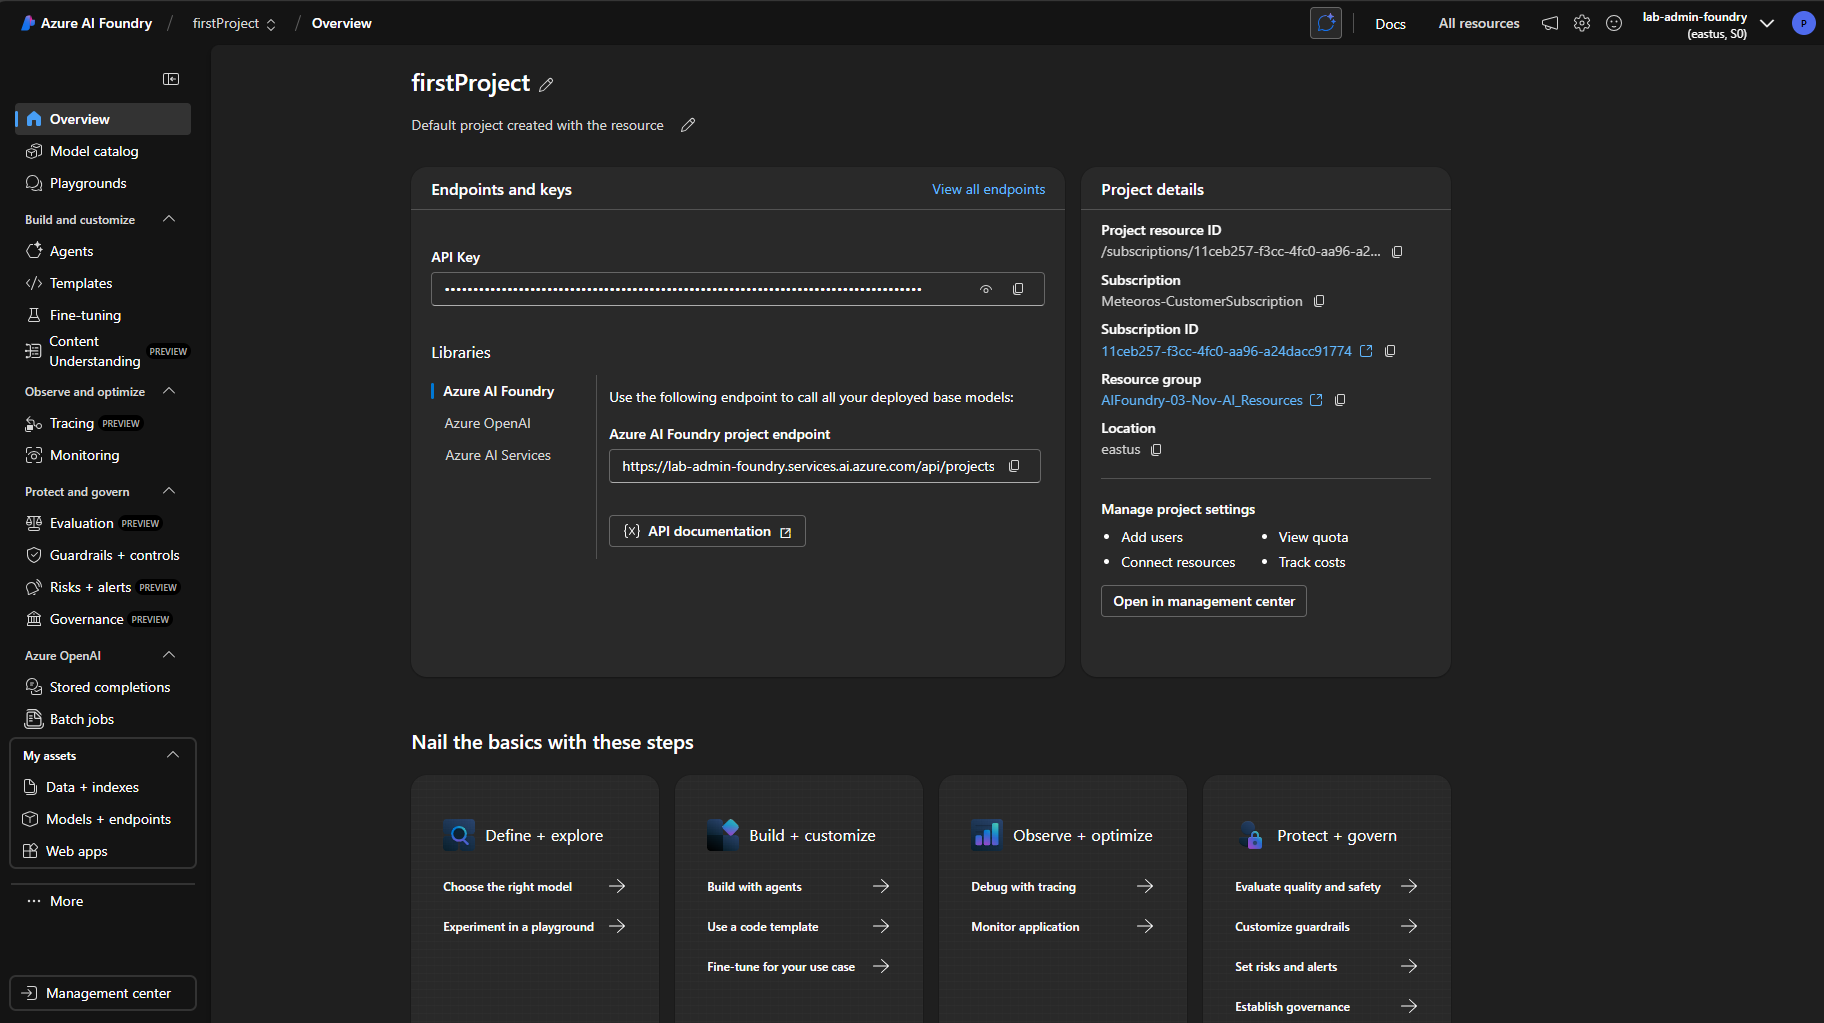

# Azure AI Foundry — Project Overview (what you’re seeing)

## 1) Page context

* **Header (top-left):** *Azure AI Foundry → firstProject → Overview* → confirms you’re on the **project** home, not the hub.
* **User/tenant (top-right):** shows the signed-in account and region (e.g., **eastus**).

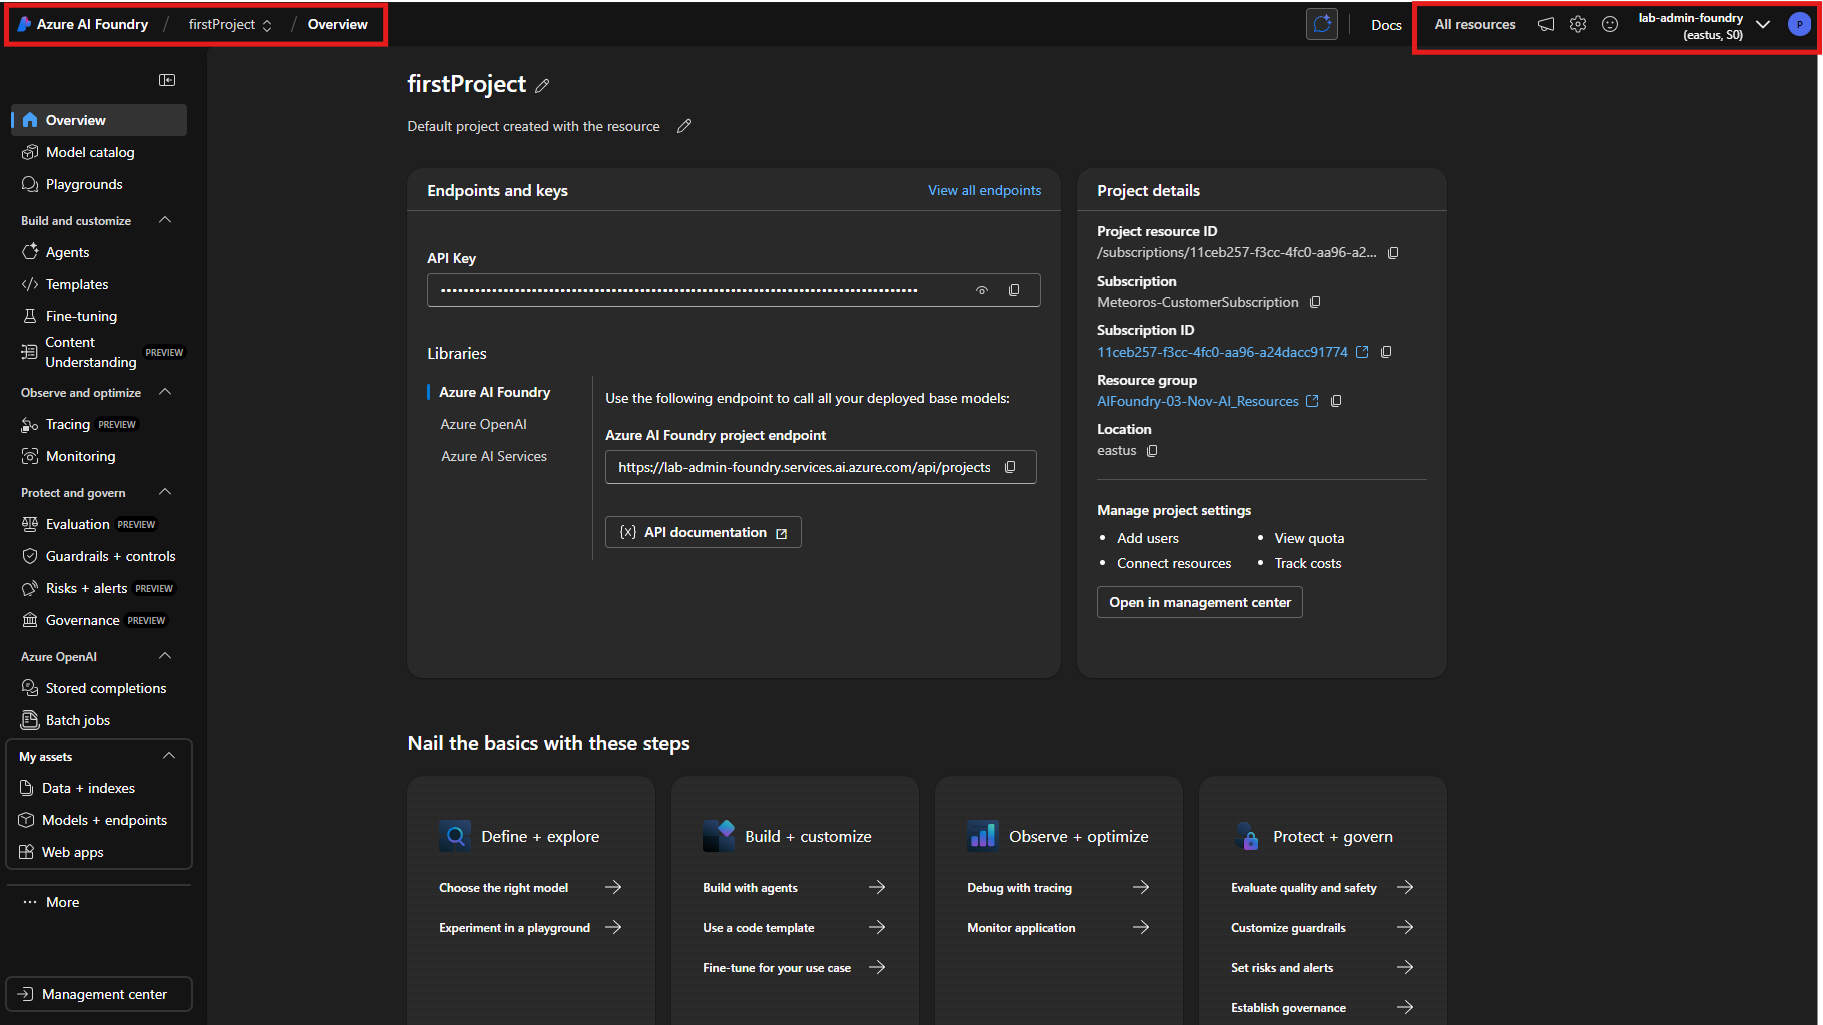

## 2) Endpoints & keys (center-left card)

This is the **fastest place** to grab what you need for SDK/REST calls.

* **API Key**

  * Masked key with copy icon — use it for bearer auth in SDK/REST (for training labs, keys are simplest).
  * Treat as a secret; rotate regularly.
* **Libraries**

  * Links for **Azure AI Foundry**, **Azure OpenAI**, **Azure AI Services** docs.
* **Azure AI Foundry project endpoint**

  * Base URL (copy icon) like:
    `https://<...>.services.ai.azure.com/api/projects`
  * You’ll pair this with your **deployment name** when calling `/chat/completions` etc.
* **“View all endpoints”**

  * Takes you to every **model deployment** endpoint under this project (helpful if you forget a name).

**Use in lab:** Copy **API Key** + **project endpoint** now; you’ll paste them into the Colab/SDK sections.

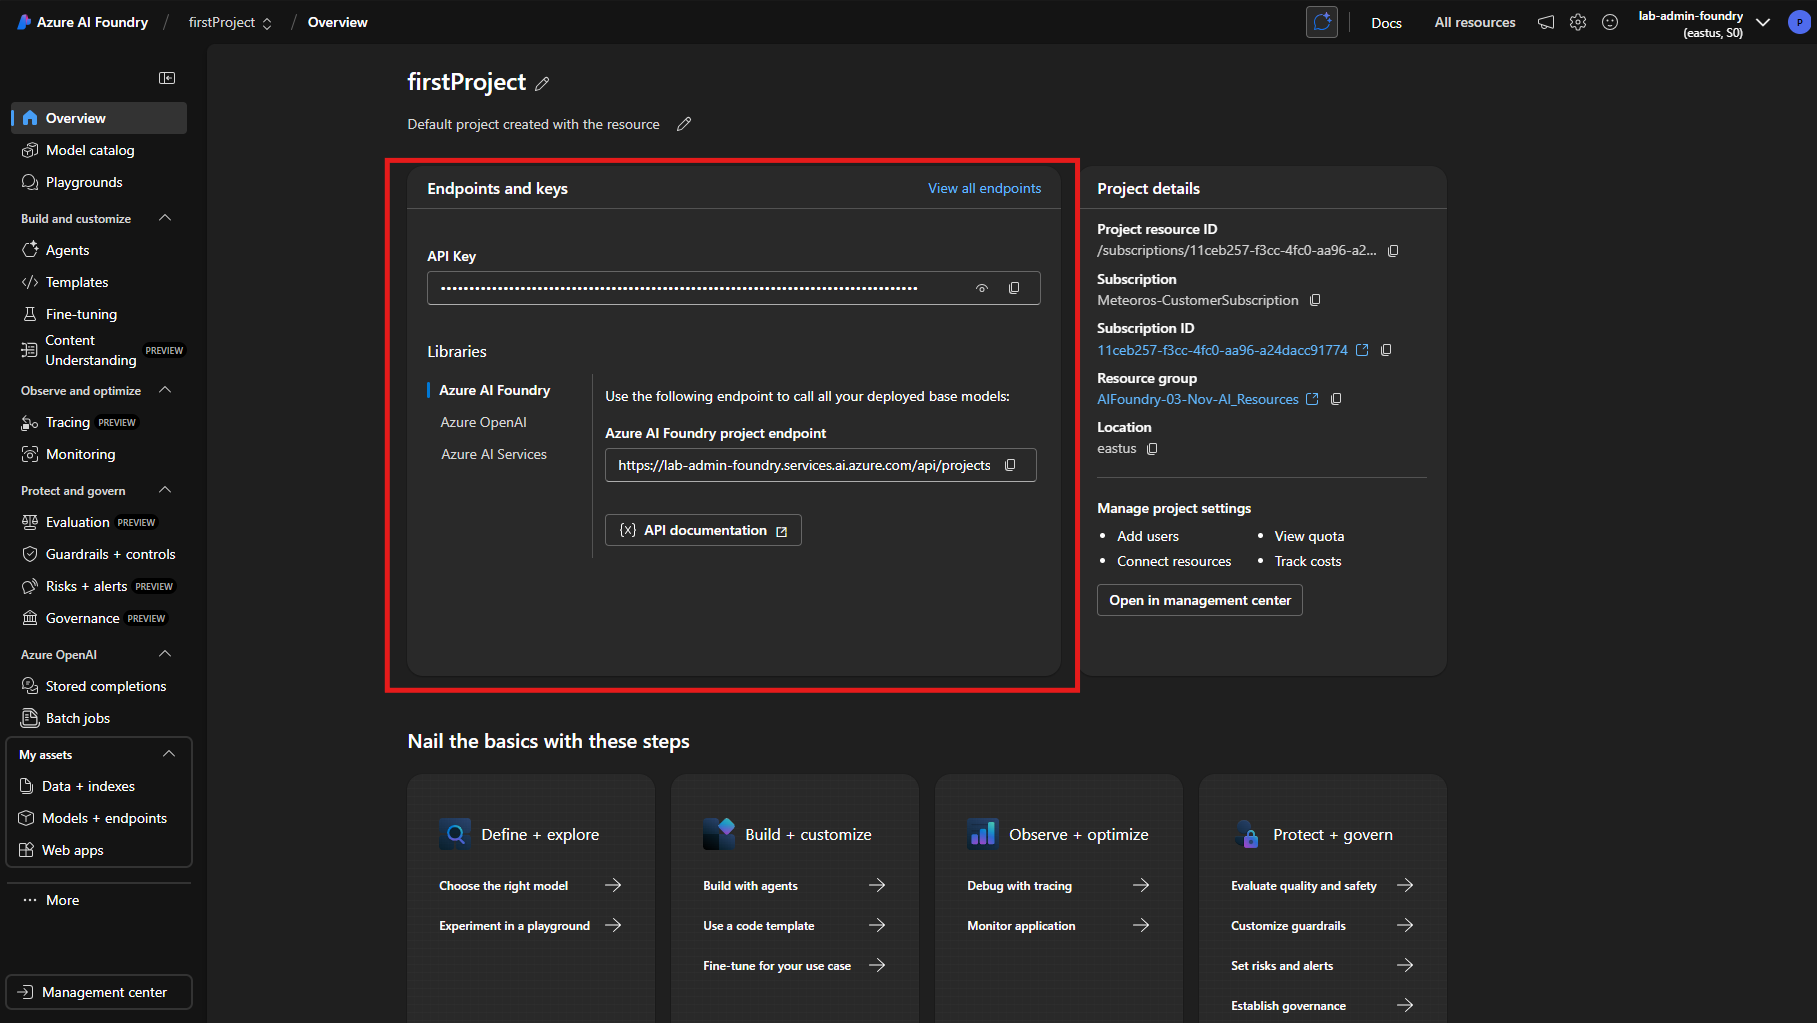

## 3) Project details (center-right card)

Operational metadata and project-level actions.

* **Project resource ID / Subscription / Subscription ID / Resource group / Location**

  * Useful for tickets, quota requests, tagging costs, or IaC references.
* **Manage project settings (shortcuts):**

  * **Add users** → grant **Reader/Contributor/Owner** (prefer Entra ID + least privilege).
  * **Connect resources** → wire data sources or other services.
  * **View quota** → check RPM/TPM and limits for selected models/regions.
  * **Track costs** → link to cost management.
* **Open in management center** → jumps to a broader admin view for this project.

**Use in lab:** If you hit **401/403**, confirm your **role** here. If you hit **429**, check **View quota**.

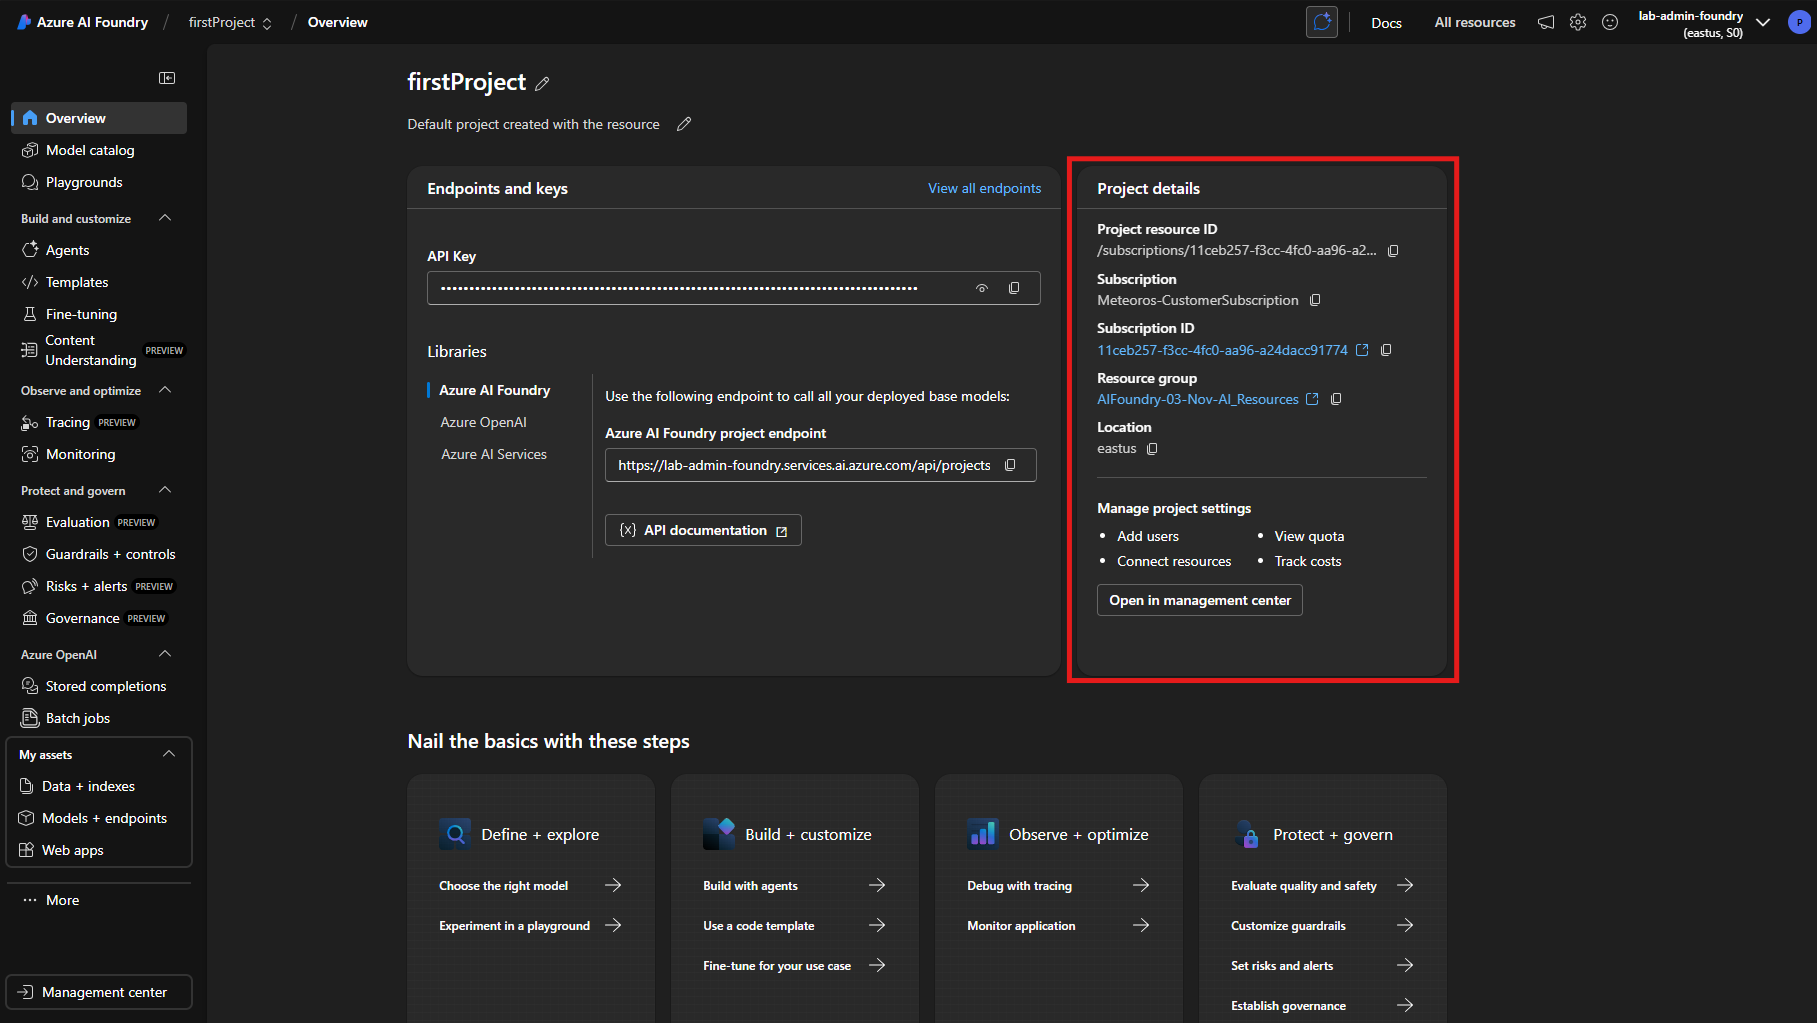

## 4) Left navigation (everything you’ll use today)

* **Model catalog** → filter by provider/capability/region; open a model page and **Deploy**.
* **Playgrounds** → test prompts, **system message**, **temperature**, **max tokens** before coding.

### Build and customize

* **Agents / Templates / Fine-tuning / Content Understanding (Preview)** → advanced features you can explore later.

### Observe and optimize

* **Tracing (Preview)** → step-level traces for debugging prompts/tool calls.
* **Monitoring** → usage, latency, errors; validate that SDK/REST calls reach the service.

### Protect and govern

* **Evaluation (Preview)** → quality/safety checks.
* **Guardrails + controls / Risks + alerts / Governance (Preview)** → content filters, policies, and audit.

### Azure OpenAI section

* **Stored completions / Batch jobs** → long-running or large-scale operations when available.

### My assets

* **Data + indexes** → connect data sources or vector indexes for RAG.
* **Models + endpoints** → list **deployments**, their **status**, **endpoint URL**, **API version**, and **limits**.
* **Web apps** → host simple apps that call your endpoints.

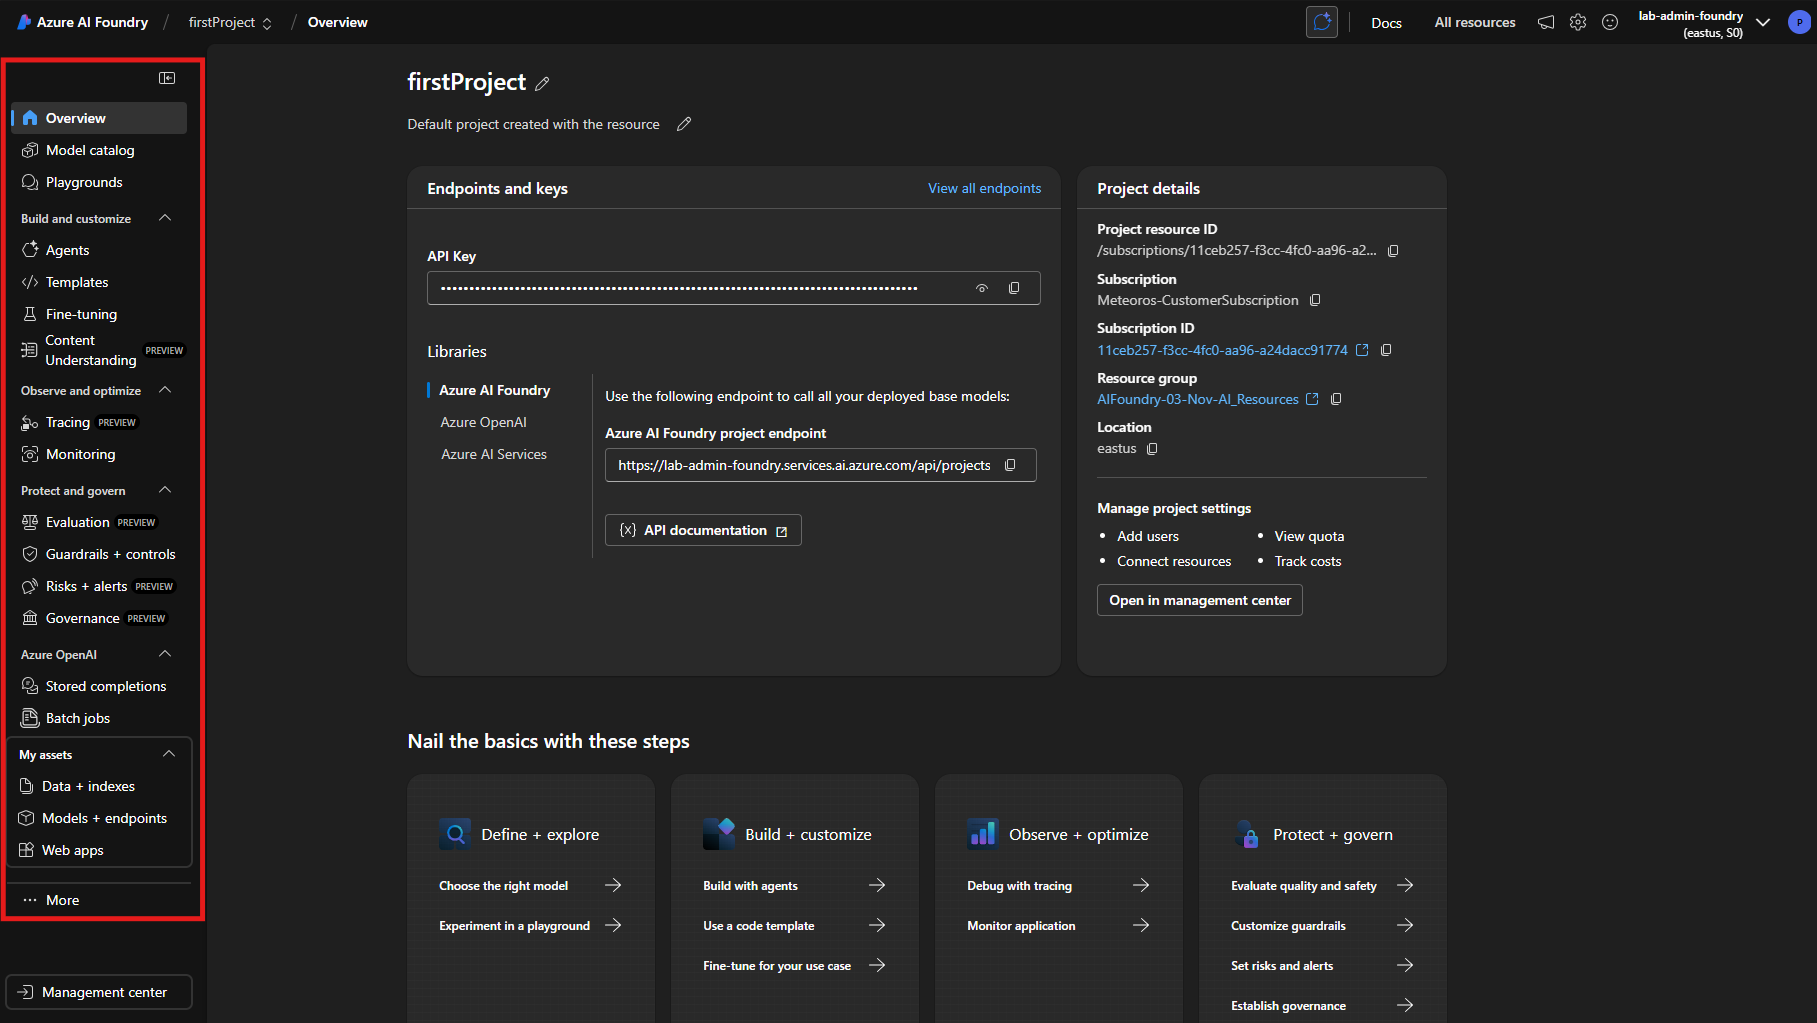

# Explore the Model Catalog

## Open Model Catalog
1. Click on Model Catalog from the left blade

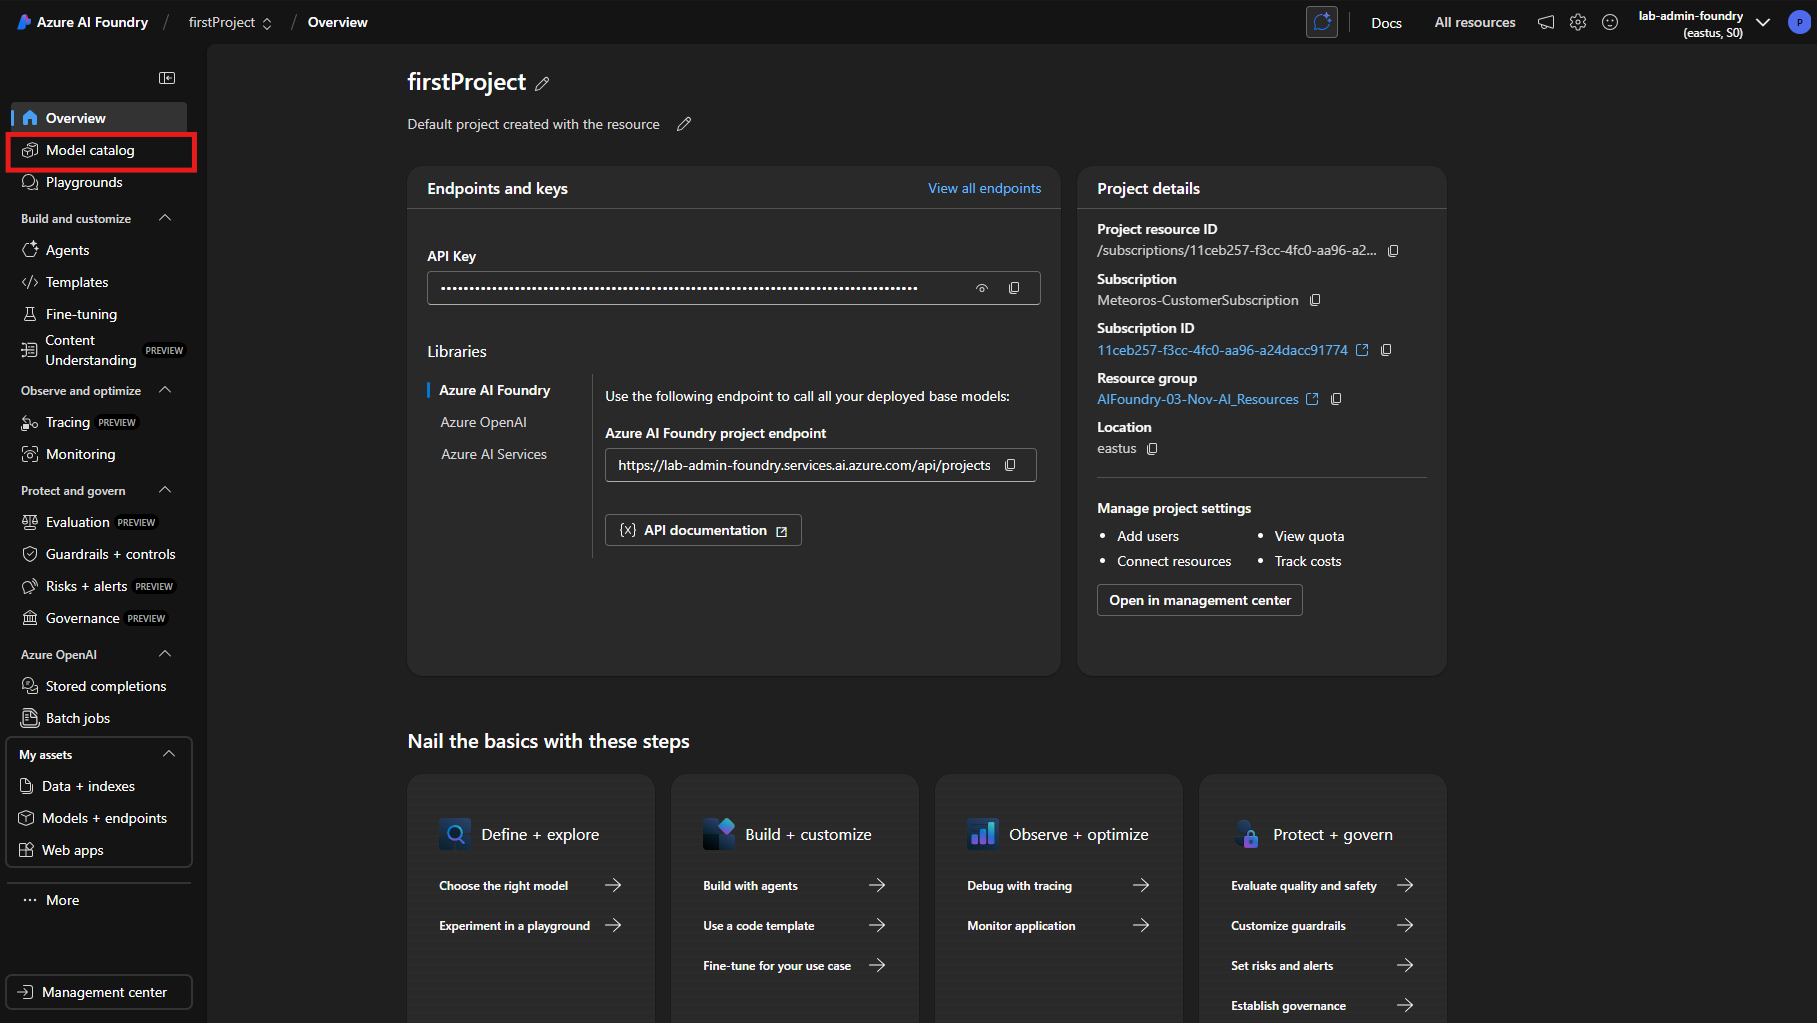

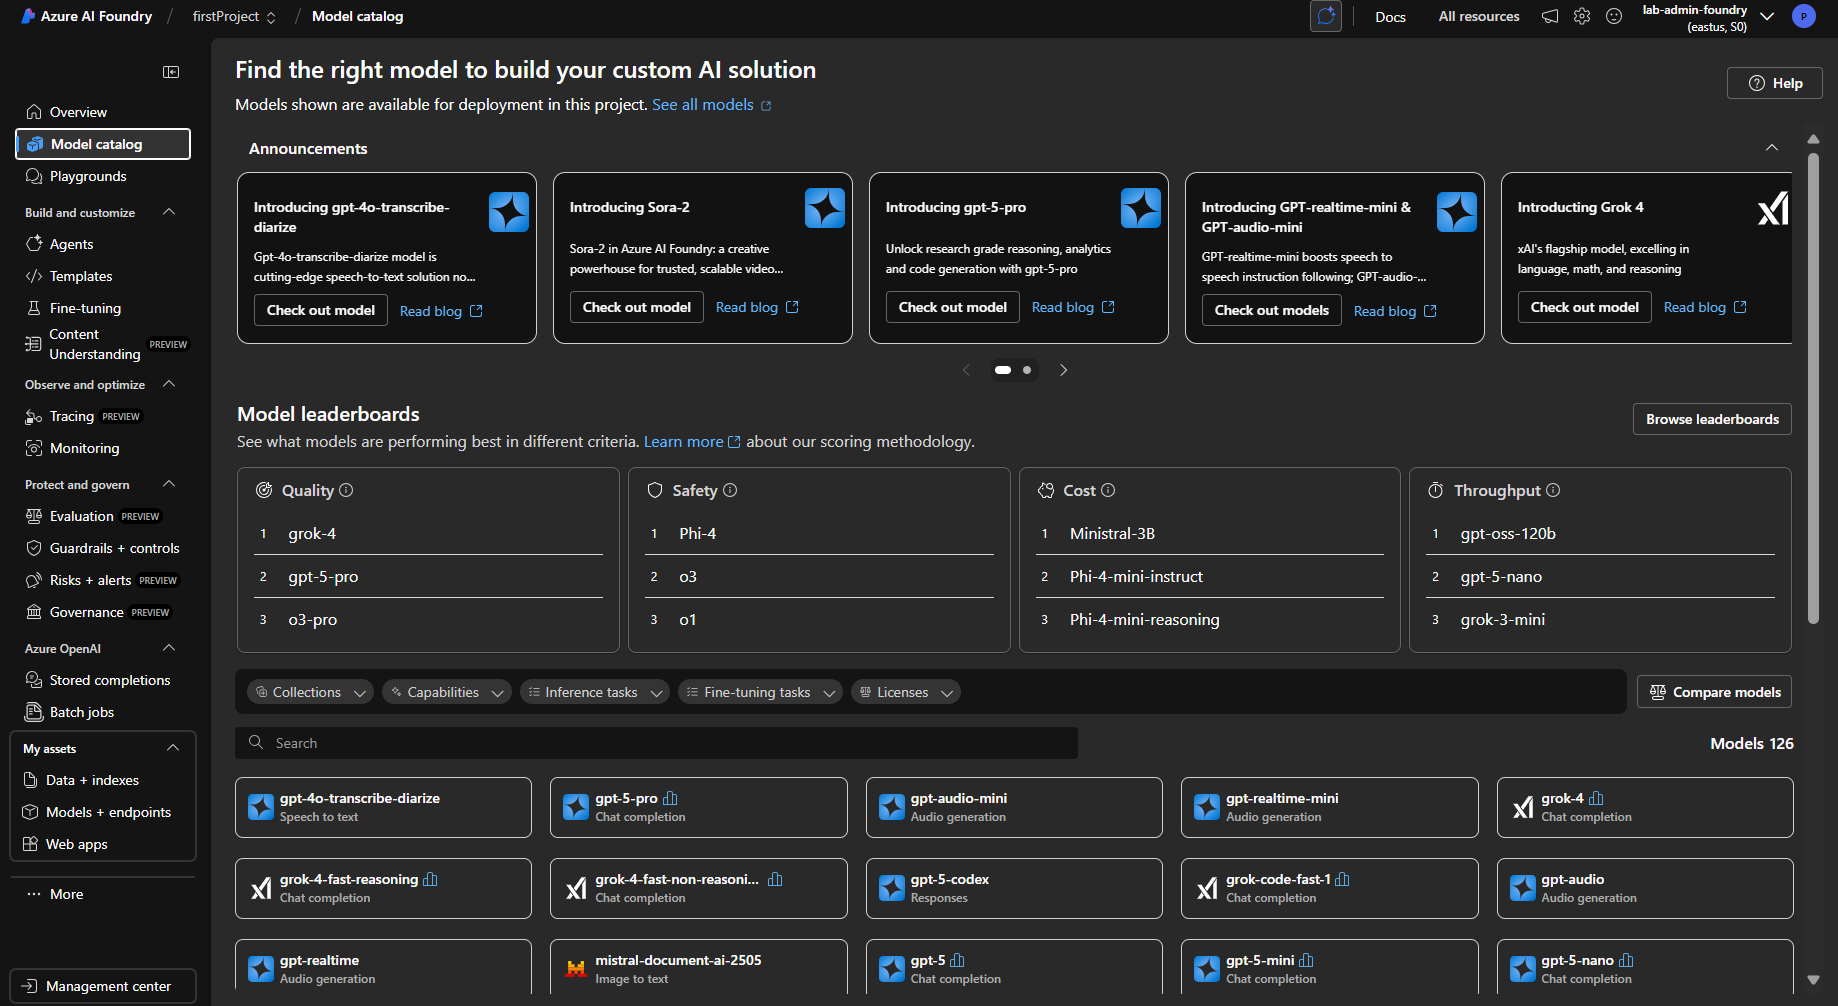


## What you’re looking at (screen anatomy)

* **Announcements** (top): curated tiles for newly available or notable models; each tile links to the model page.

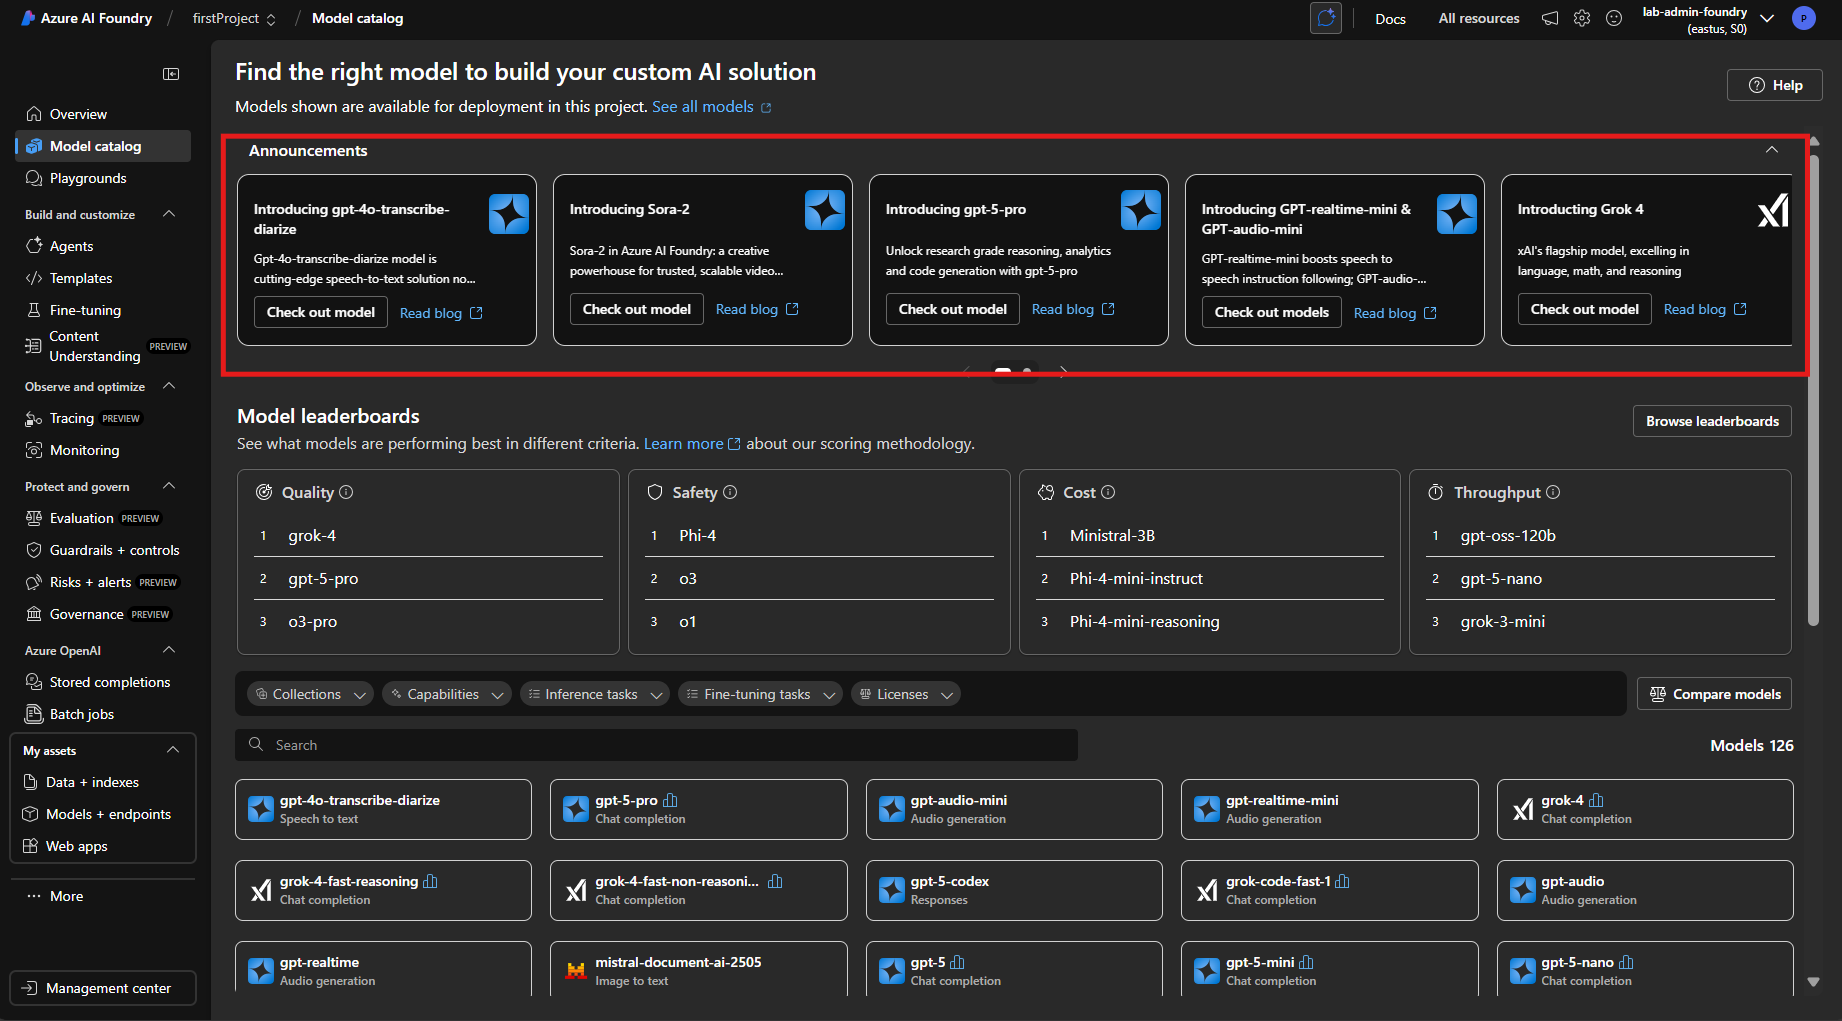

* **Model leaderboards**: four small leaderboards rank models by **Quality**, **Safety**, **Cost**, and **Throughput**. Use these to form a first hypothesis (e.g., “I need low latency → check Throughput top models”).

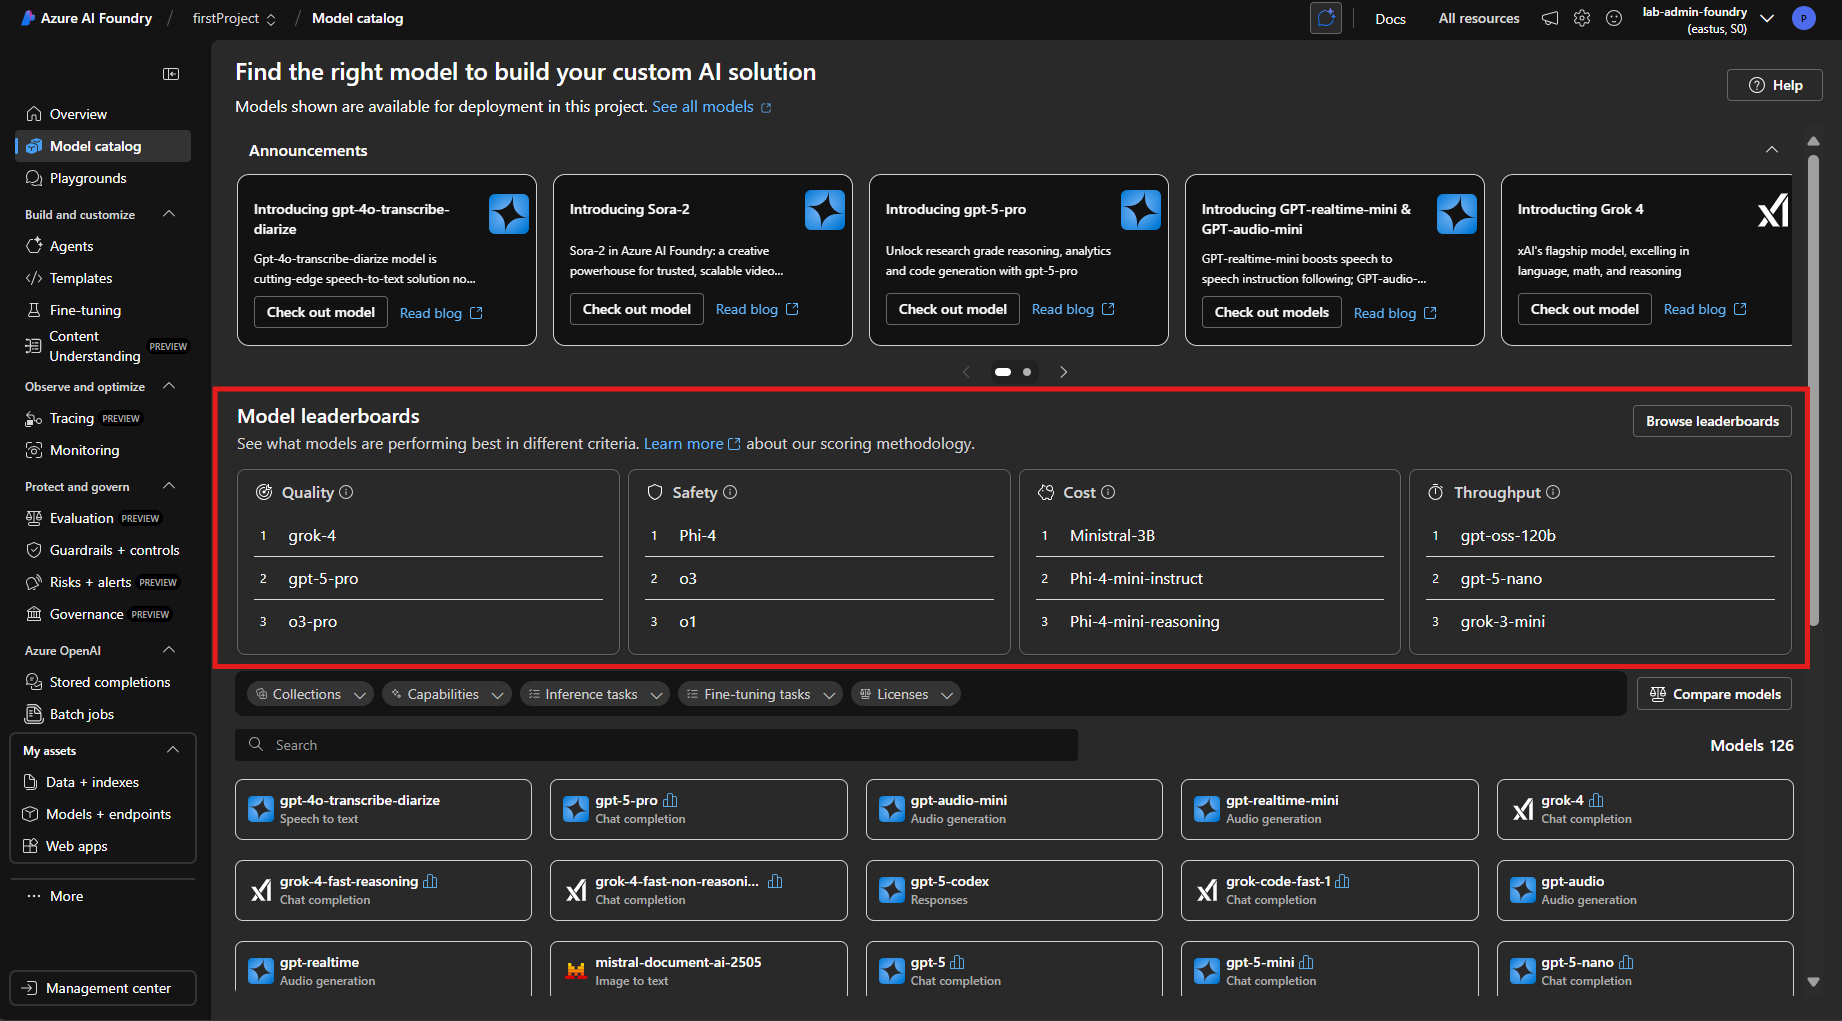

* **Filters bar** (chips under leaderboards):

  * **Collections** – curated bundles (e.g., “Chat,” “Reasoning,” “Audio”).
  * **Capabilities** – what a model can do (chat completion, embeddings, speech, image).
  * **Inference tasks** – the intent (summarization, Q&A, code gen, speech-to-text, etc.).
  * **Fine-tuning tasks** – where adaptation is supported.
  * **Licenses** – open/commercial/licensing constraints.
* **Search** – keyword search across names/descriptions.
* **Compare models** – pick multiple cards to open a side-by-side specs view.
* **Model grid** – individual **cards** (e.g., chat models, audio, image, doc AI). Each card shows the **provider icon**, **task type**, and opens to a detail page with regions, limits, and **Deploy**.

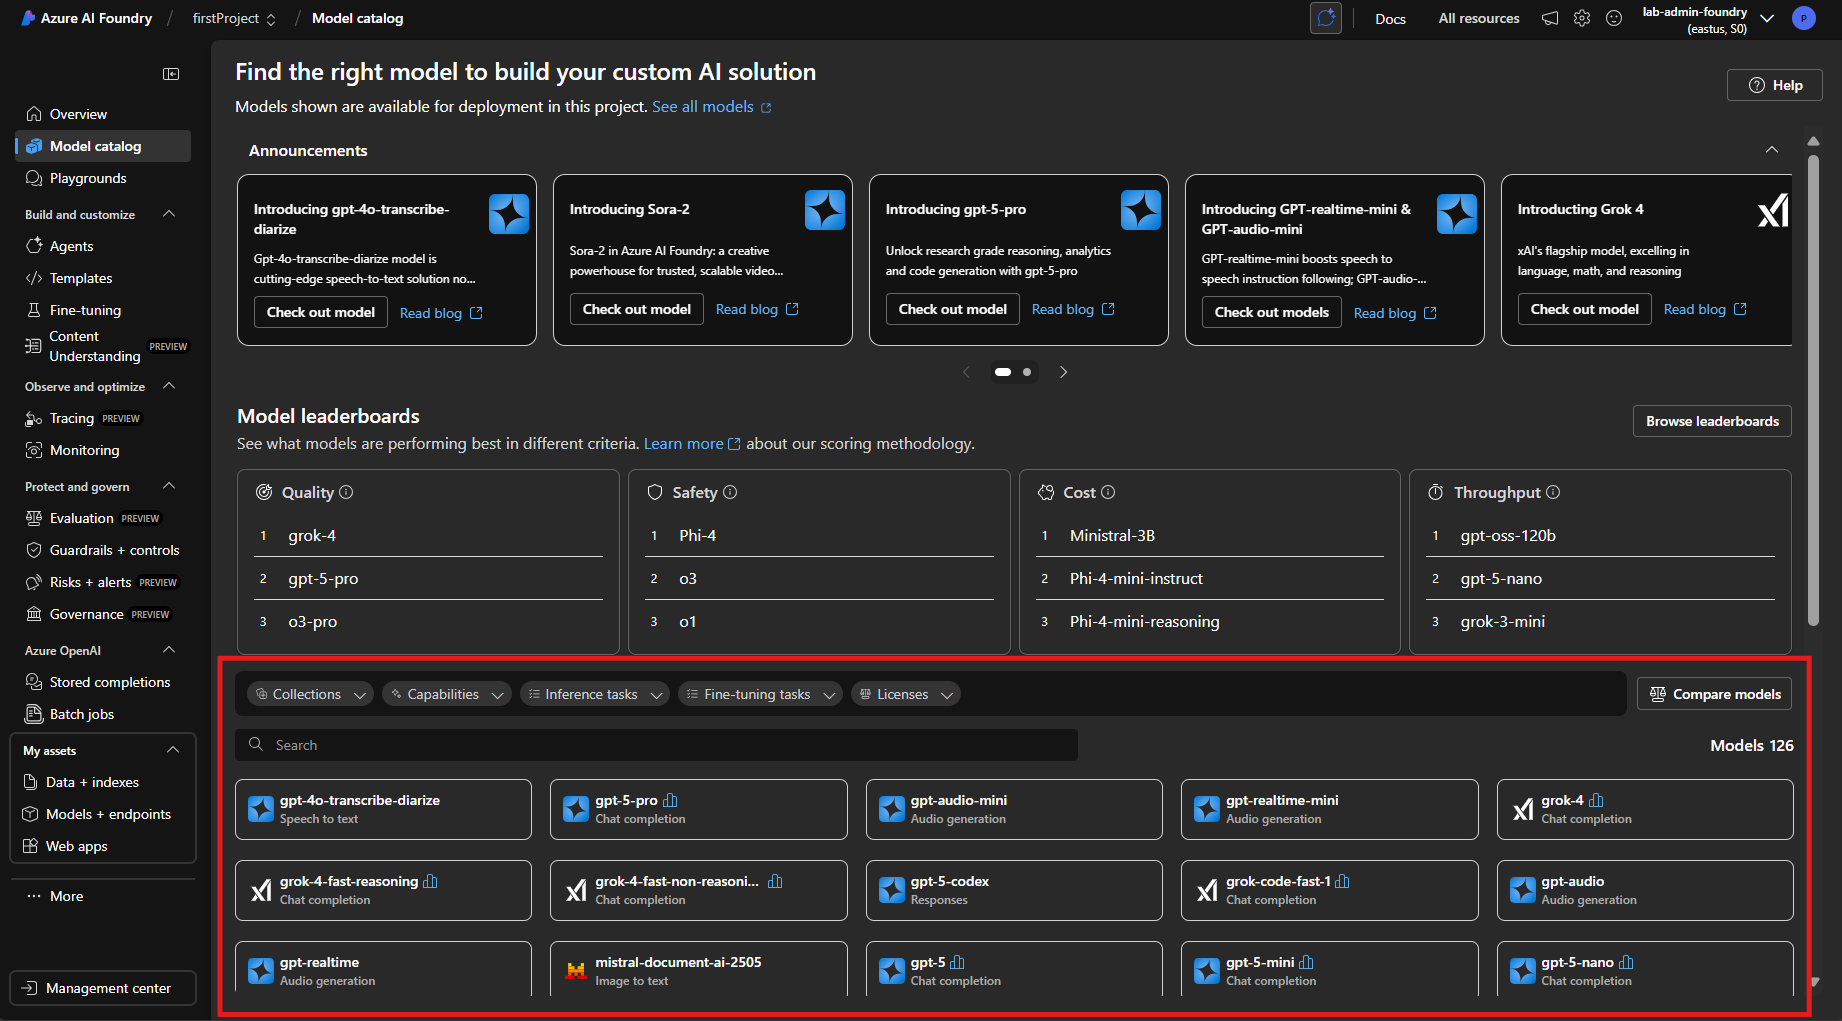



## Leaderboards: how to read them

* **Quality** – general model quality across broad benchmarks; good first pick for accuracy-sensitive tasks.
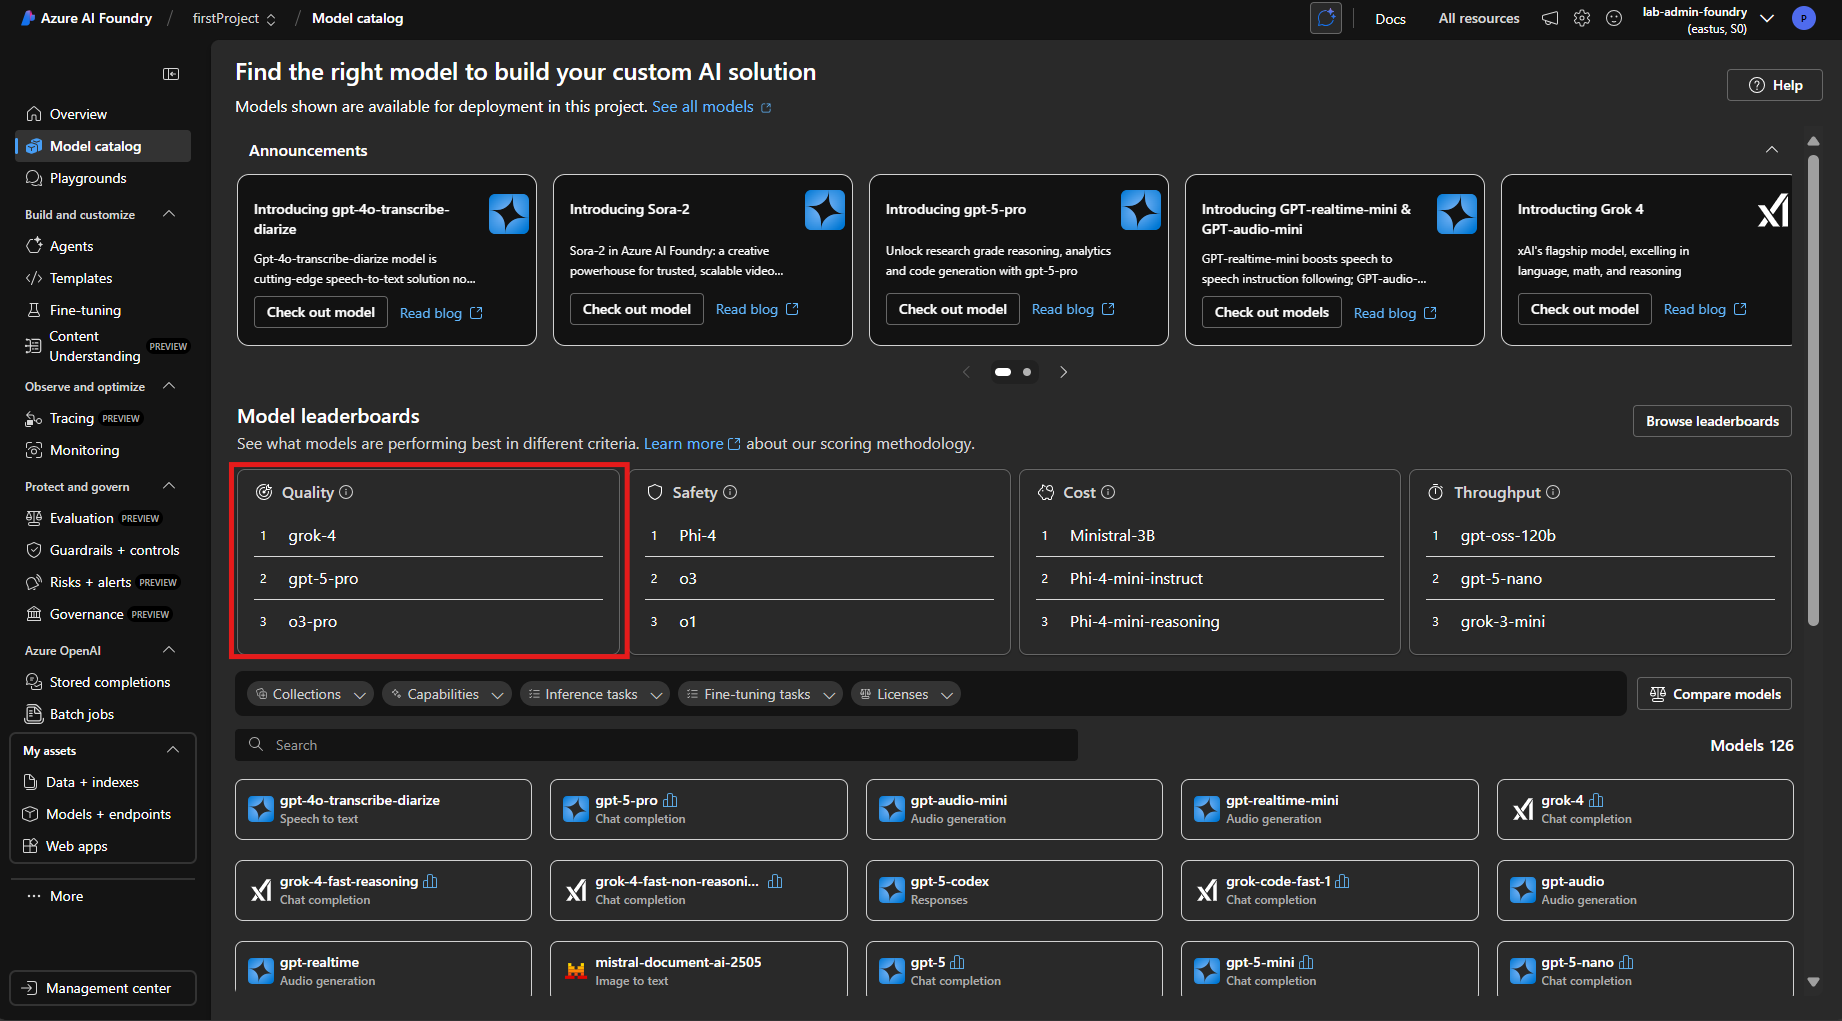
* **Safety** – policy adherence and safer defaults; useful in customer-facing flows.
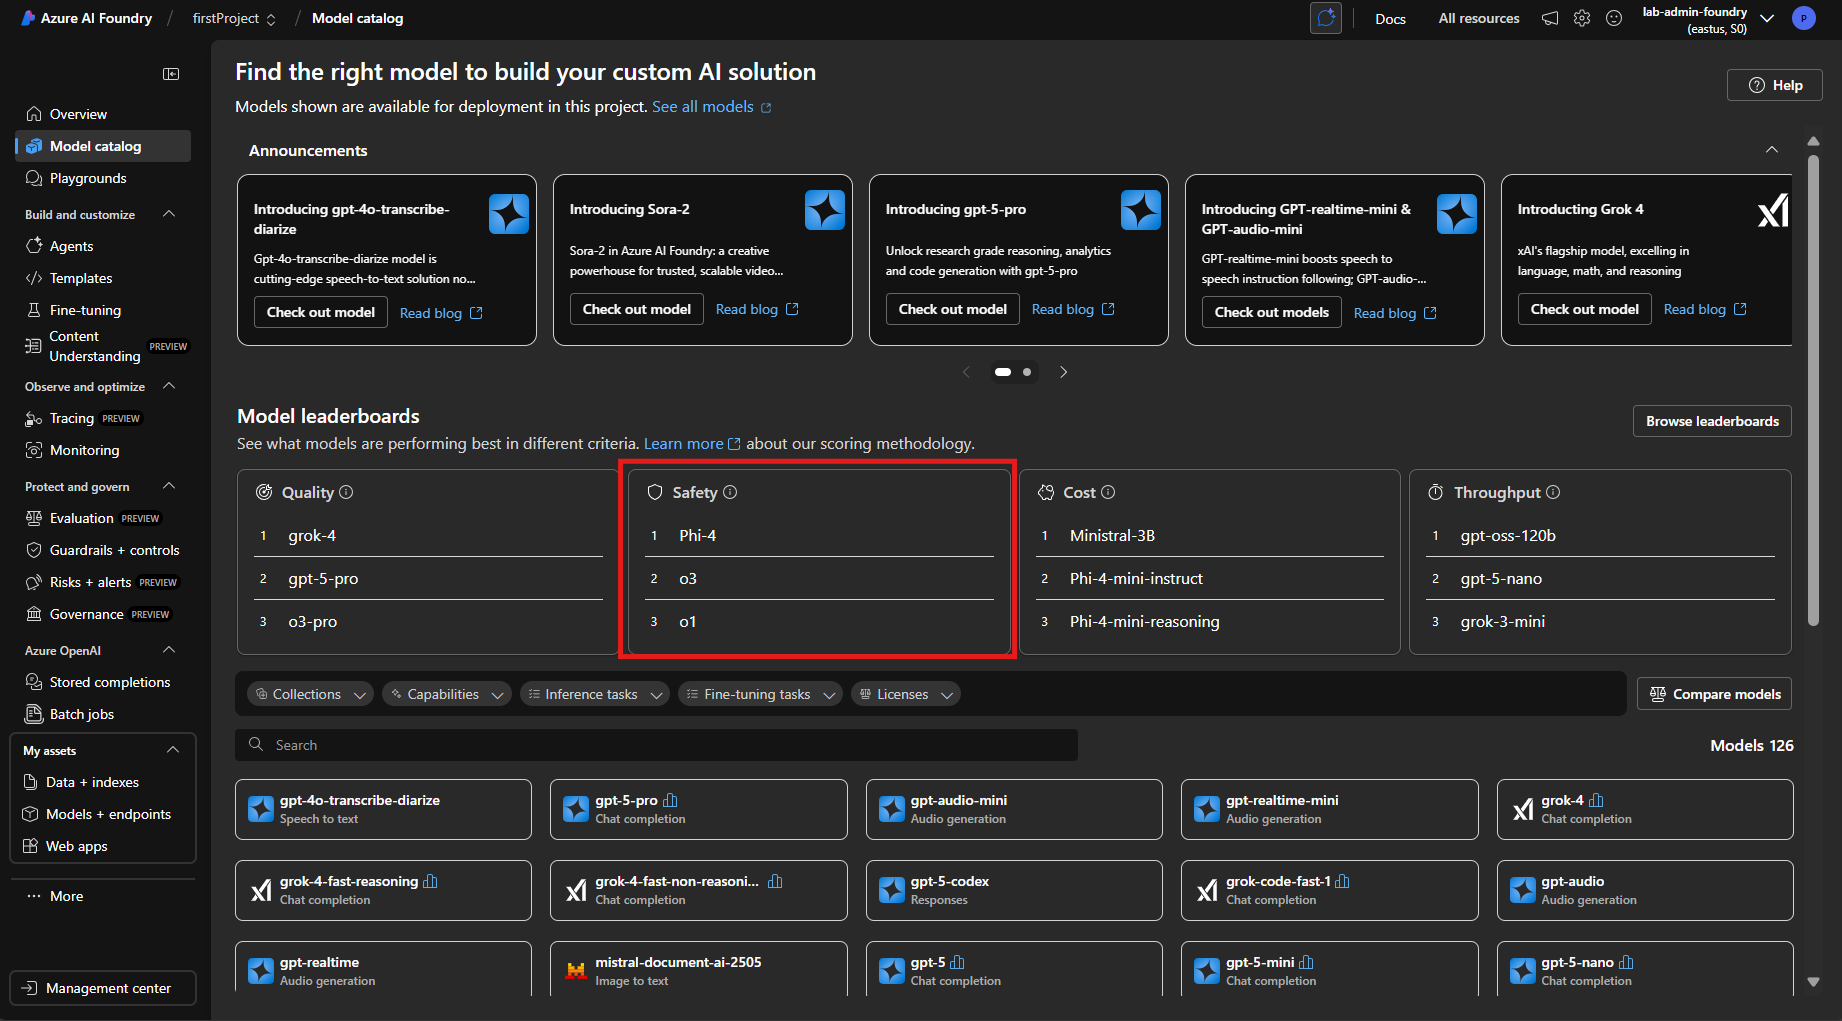
* **Cost** – relative token cost; a proxy for budget efficiency.
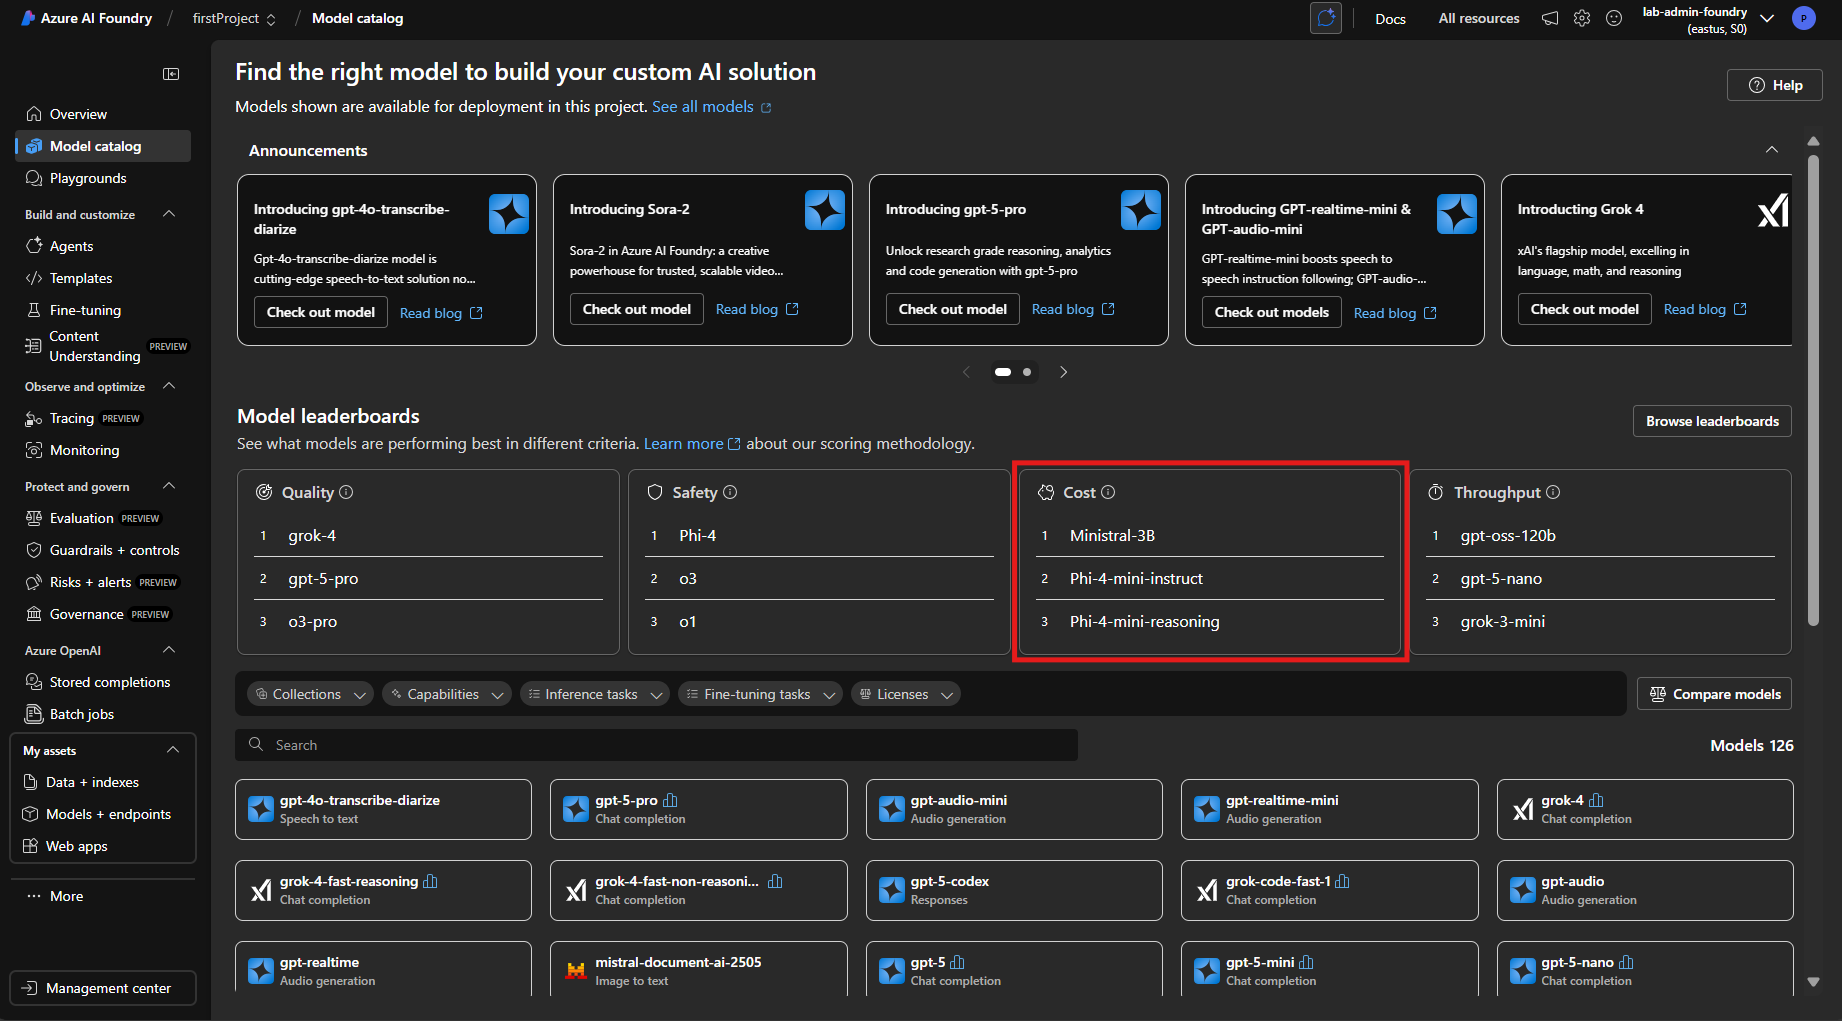
* **Throughput** – speed at scale; consider for near-real-time UX or heavy concurrency.
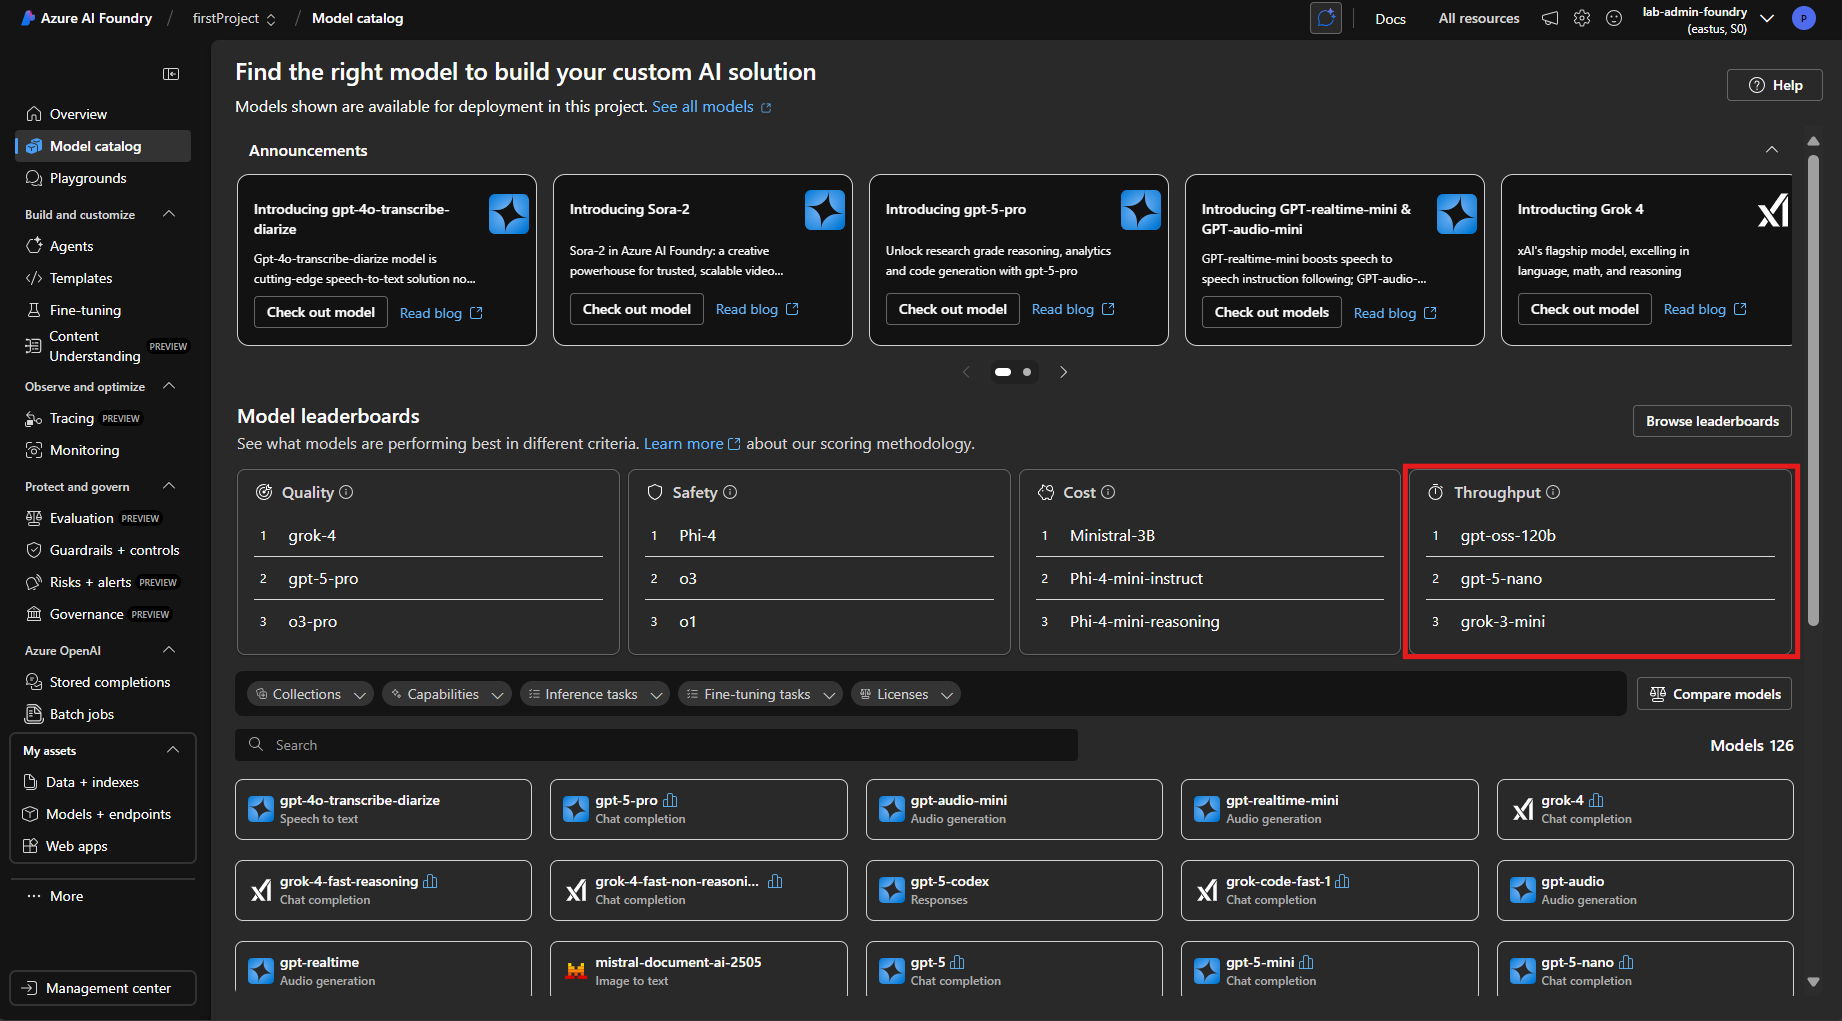
**Tip:** Leaderboards are directional. Always validate with **your** prompts in the Playground.



## Model selection workflow (recommended)

1. **Start with filters**
   Choose **Capability** (e.g., *Chat completion* for this lab), then narrow by **Inference task** (e.g., *Q&A* or *Summarization*).
2. **Scan leaderboards**
   If you need speed, sort by **Throughput**; if budget is tight, check **Cost** top entries.
3. **Open 2–3 candidates**
   Click their cards; on each **model detail page**, review:

   * **Regions** available (must match your project region).
   * **Context window**, **rate limits**, **API support** (chat, tool calling, JSON output features).
   * **Pricing** notes and any **safety** controls.
4. **Use “Compare models”**
   Add the short-listed models and compare context size, tokens/sec guidance, features, and support for fine-tuning.
5. **Decide & deploy**
   Pick one **primary** model and (optionally) a **backup** smaller model for cost/latency tests. Name deployments clearly (e.g., `gpt5-mini-lab`).



## Model card → detail page → deploy (what to check before you click Deploy)

* **Region availability**: Must match your project’s region; otherwise deploy will be disabled.
* **Auth & API**: Confirm it supports the **/chat/completions** interface you’ll call in SDK/REST.
* **Limits**: Context window, max output tokens, and any tool-calling/JSON enforcement notes.
* **Quota/cost**: Check if your subscription has quota; if not, choose a smaller sibling model.




# Explore Foundation Models — Notable Families

## OpenAI — GPT-4o / GPT-4o-mini / GPT-5 / Sora

* **What:** General-purpose, instruction-following LLMs; GPT-4o adds native multimodal (text+image+audio) I/O.
* **Strengths:** Strong reasoning, tool use, JSON formatting, broad ecosystem; GPT-4o enables image understanding and audio use cases.
* **Great for:** Chat assistants, code help, structured outputs, multimodal Q&A/demos.
* **Considerations:** Higher cost than small models; pick “mini/turbo” variants for latency/cost.

## Anthropic — Claude 3 (Opus / Sonnet / Haiku)

* **What:** Safety-forward LLM family with long context options.
* **Strengths:** Helpful, careful outputs; long documents; good for analysis/summarization.
* **Great for:** Enterprise writing, policy-sensitive assistants, long-context reading.
* **Considerations:** Choose tier by quality vs cost/latency (Opus>Sonnet>Haiku).

## Meta — Llama 3 (8B, 70B)

* **What:** Open-weights LLMs (commercially usable with license); strong general chat quality.
* **Strengths:** Deploy anywhere (cloud/on-prem); good with RAG; active community.
* **Great for:** Cost-controlled private deployments, customization, RAG apps.
* **Considerations:** Needs careful prompt/eval; quality below top proprietary models on some tasks.

## Mistral — Mistral 7B / Mixtral 8x7B (MoE)

* **What:** Efficient small/mixture-of-experts models optimized for speed.
* **Strengths:** Excellent latency/$; competitive with smart prompting; Mixtral scales quality via MoE.
* **Great for:** Low-latency chat, RAG with concise answers, edge-friendly services.
* **Considerations:** May need more prompt engineering; watch context limits.

## Microsoft — Phi-3 (mini / small / medium)

* **What:** Compact, data-curated small LLMs emphasizing efficiency.
* **Strengths:** Runs cheaply; good few-shot reasoning for their size; on-device/edge potential.
* **Great for:** Lightweight assistants, form-fill JSON generation, gateways/pre-filters.
* **Considerations:** Not a drop-in for heavy reasoning; pair with RAG.

## Cohere — Command R / Command R+

* **What:** LLMs tuned for **retrieval-augmented** workflows and tools.
* **Strengths:** RAG-friendly behavior, citation style, tool calling.
* **Great for:** Enterprise Q&A over your docs, agent/tool pipelines.
* **Considerations:** Validate formatting and grounding quality with your corpus.

## Google — Gemma / Gemini (open weights)

* **What:** Lightweight open models from Google for research/production prototypes.
* **Strengths:** Simple to fine-tune; good baseline quality for open models.
* **Great for:** Customization experiments, controlled environments.
* **Considerations:** Smaller context/quality than flagship proprietary models.

## Image Generation — Stable Diffusion XL (SDXL)

* **What:** Open image diffusion model (text→image).
* **Strengths:** Local or cloud; controllable via prompts/LoRA.
* **Great for:** Marketing visuals, UI mock art, rapid ideation.
* **Considerations:** Safety/brand filters needed; prompt engineering is key.

## Speech-to-Text — Whisper

* **What:** Robust ASR (automatic speech recognition).
* **Strengths:** Multi-language, accents; good baseline accuracy.
* **Great for:** Transcripts, voice UI, meeting notes.
* **Considerations:** Latency vs accuracy trade-offs; post-processing for punctuation/entities.

## Classic Encoder-Decoder — FLAN-T5 / T5

* **What:** Instruction-tuned seq2seq models for text tasks.
* **Strengths:** Strong at translation, summarization, classification.
* **Great for:** Deterministic transformations and templated outputs.
* **Considerations:** Not chat-native; smaller context; fewer modern features.



## Picking a model (quick rubric)

* **Task fit:** Chat vs embeddings vs vision/audio.
* **Latency/cost:** Prefer small/“mini” for demos; upscale if quality gap persists.
* **Context needs:** Long docs → choose larger context windows.
* **Safety/compliance:** Favor families with mature guardrails for user-facing apps.
* **Deployment constraints:** Open-weights (Llama/Mistral/Gemma) if you need self-hosting; managed APIs for speed to value.




## Bridge to the hands-on

Next, you will:

1. Open a model card from the catalog,
2. Click **Deploy** (Standard or Serverless as available),
3. Validate behavior in **Playgrounds → Chat**, then
4. Call the deployment via **SDK/REST** and tune **temperature/top-p/max tokens**.

# Deploying a model

1. Click on the Search bar and search for `gpt-4o-mini`
2. Select the corresponding tile

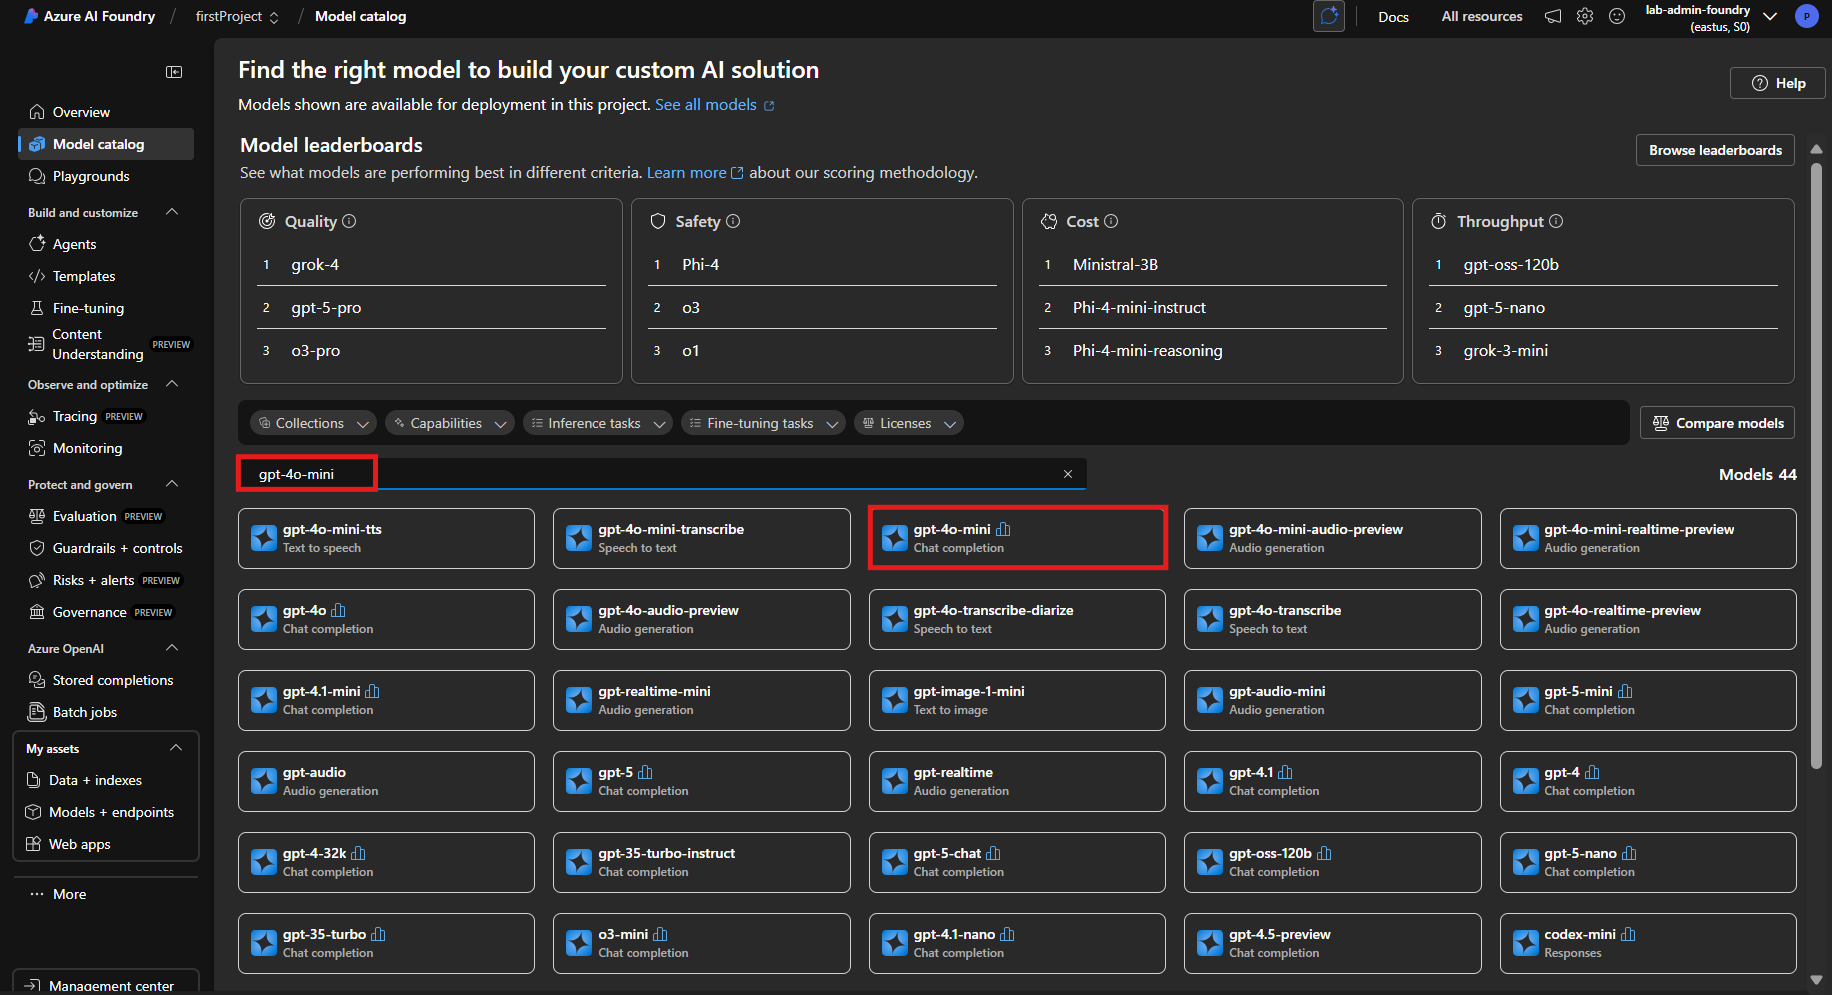

# Model Page — What Each Section Means

## Header & Primary Actions

* **Title (gpt-4o-mini)** — The selected model family/version.
* **Use this model** — Opens the **Deploy** flow for this model.
* **Fine-tune** — Starts adaptation (only visible/enabled when the provider supports it for this model).
* **Tabs:** **Details** (you’re here), **Benchmarks**, **Existing deployments**, **License**.

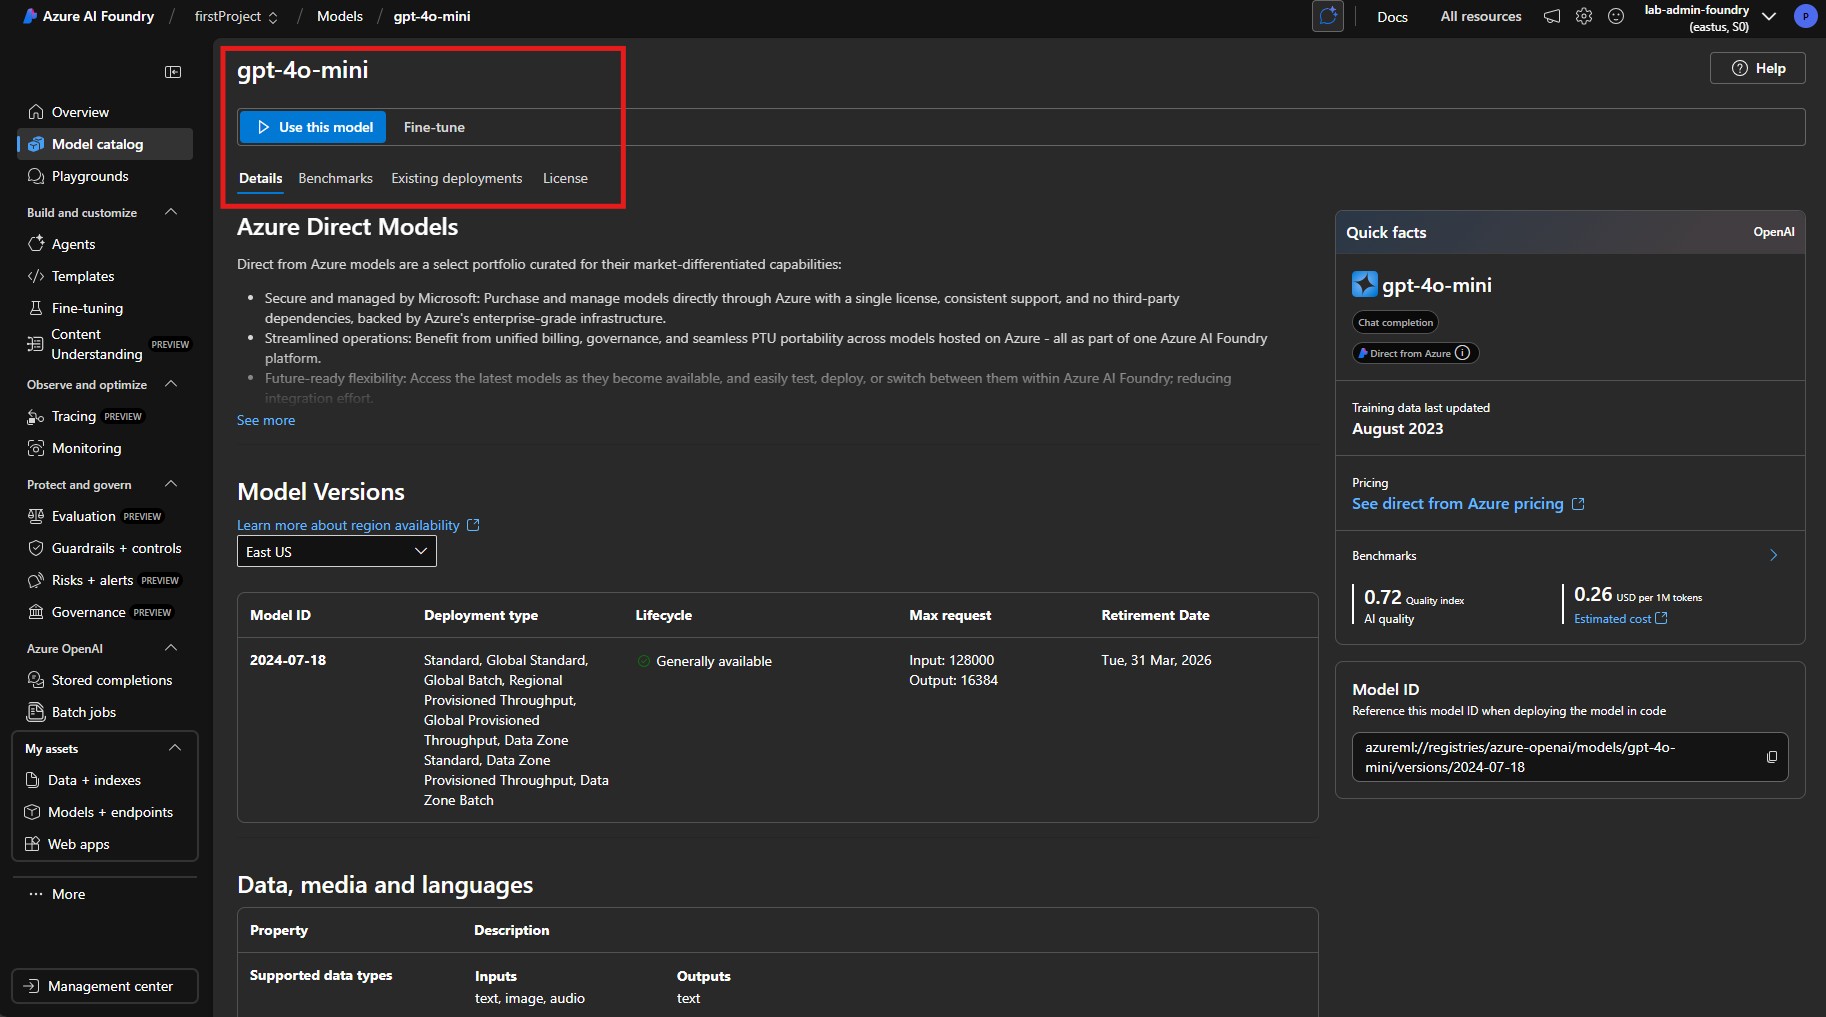

## Quick facts (right panel)

A fast summary you’ll reference often:

* **Badge + Capability:** e.g., *Chat completion* and **Direct from Azure** (procured/managed via Azure).
* **Training data last updated:** When the base training cutoff was last refreshed.
* **Pricing link:** Jumps to the provider’s pricing page for this model family.
* **Benchmarks:** Quick **Quality index** and **Estimated cost** (directional; verify with your workload).
* **Model ID (registry URI):** Copyable string you can use in tooling/automation to reference this exact model version.

**Lab tip:** Copy the **Model ID** if your deployment/IaC scripts require a precise version pin.

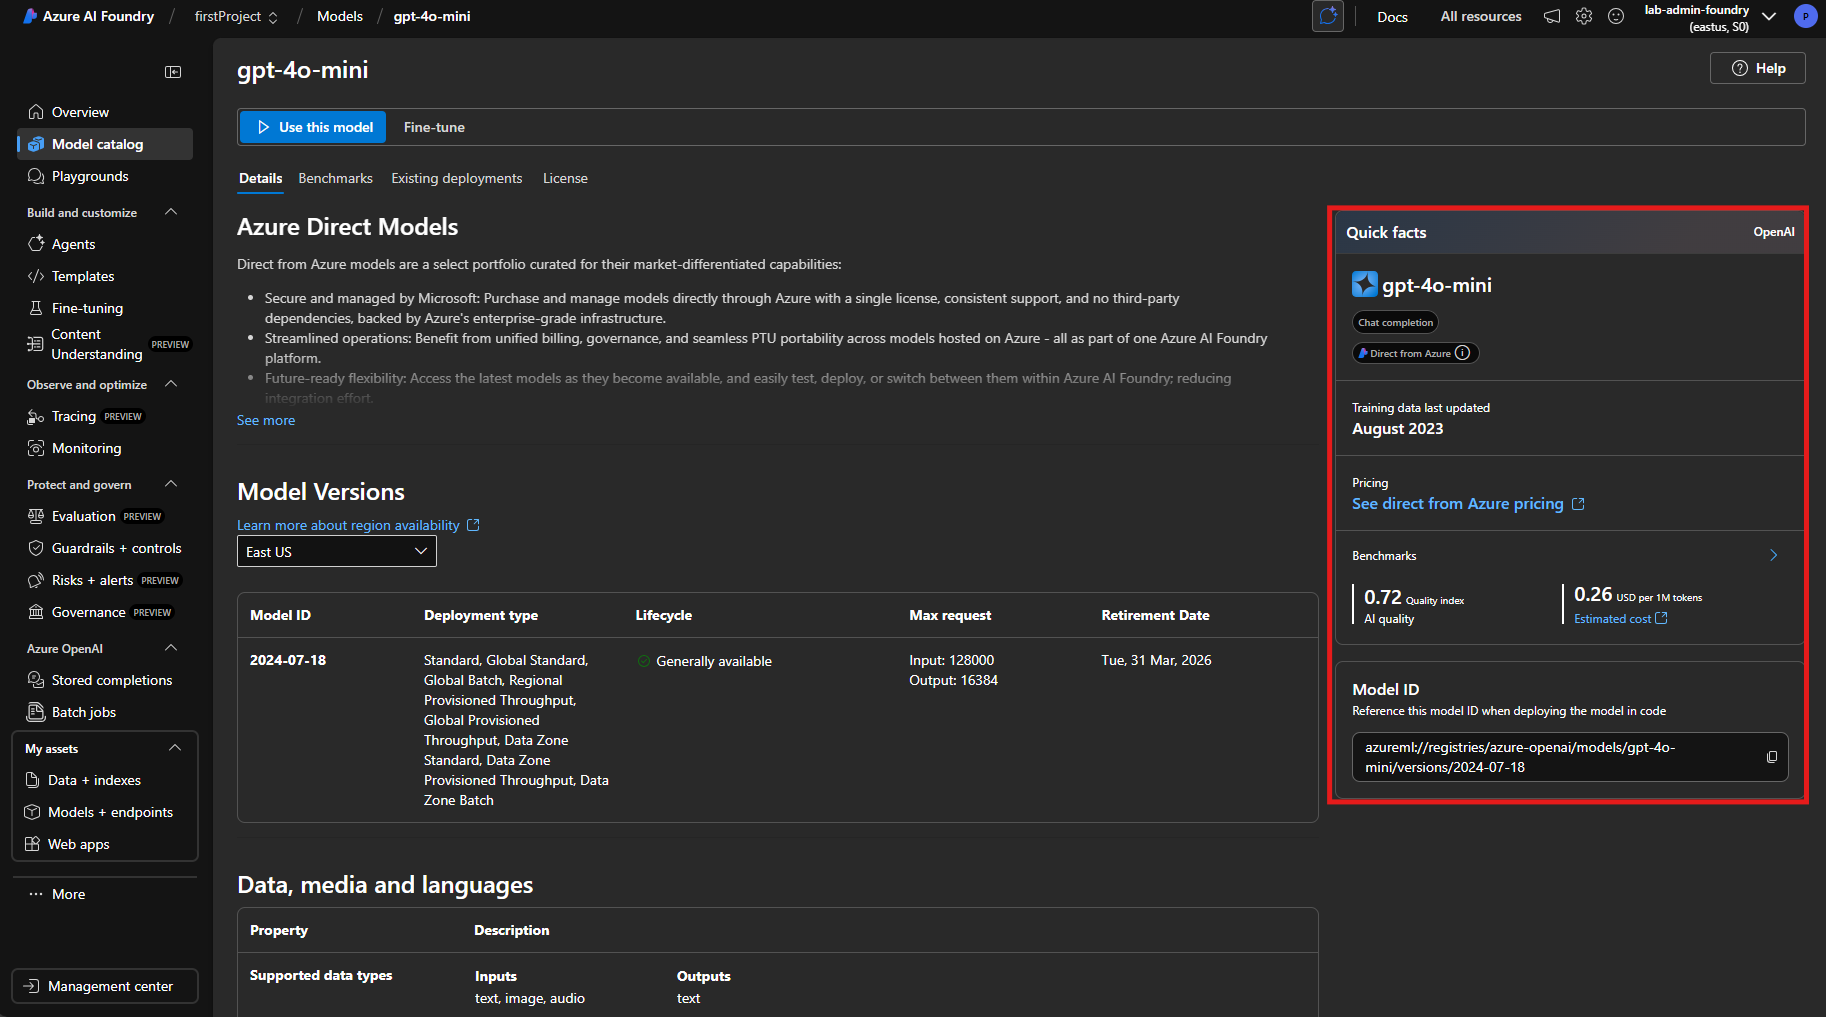

## Azure Direct Models (info card)

Explains that this model is purchased/managed **directly through Azure**:

* Single Azure contract & support
* Unified billing/governance
* Easier switching among Azure-hosted models

**Why it matters:** Enterprise teams often prefer Direct models for compliance, support, and procurement simplicity.

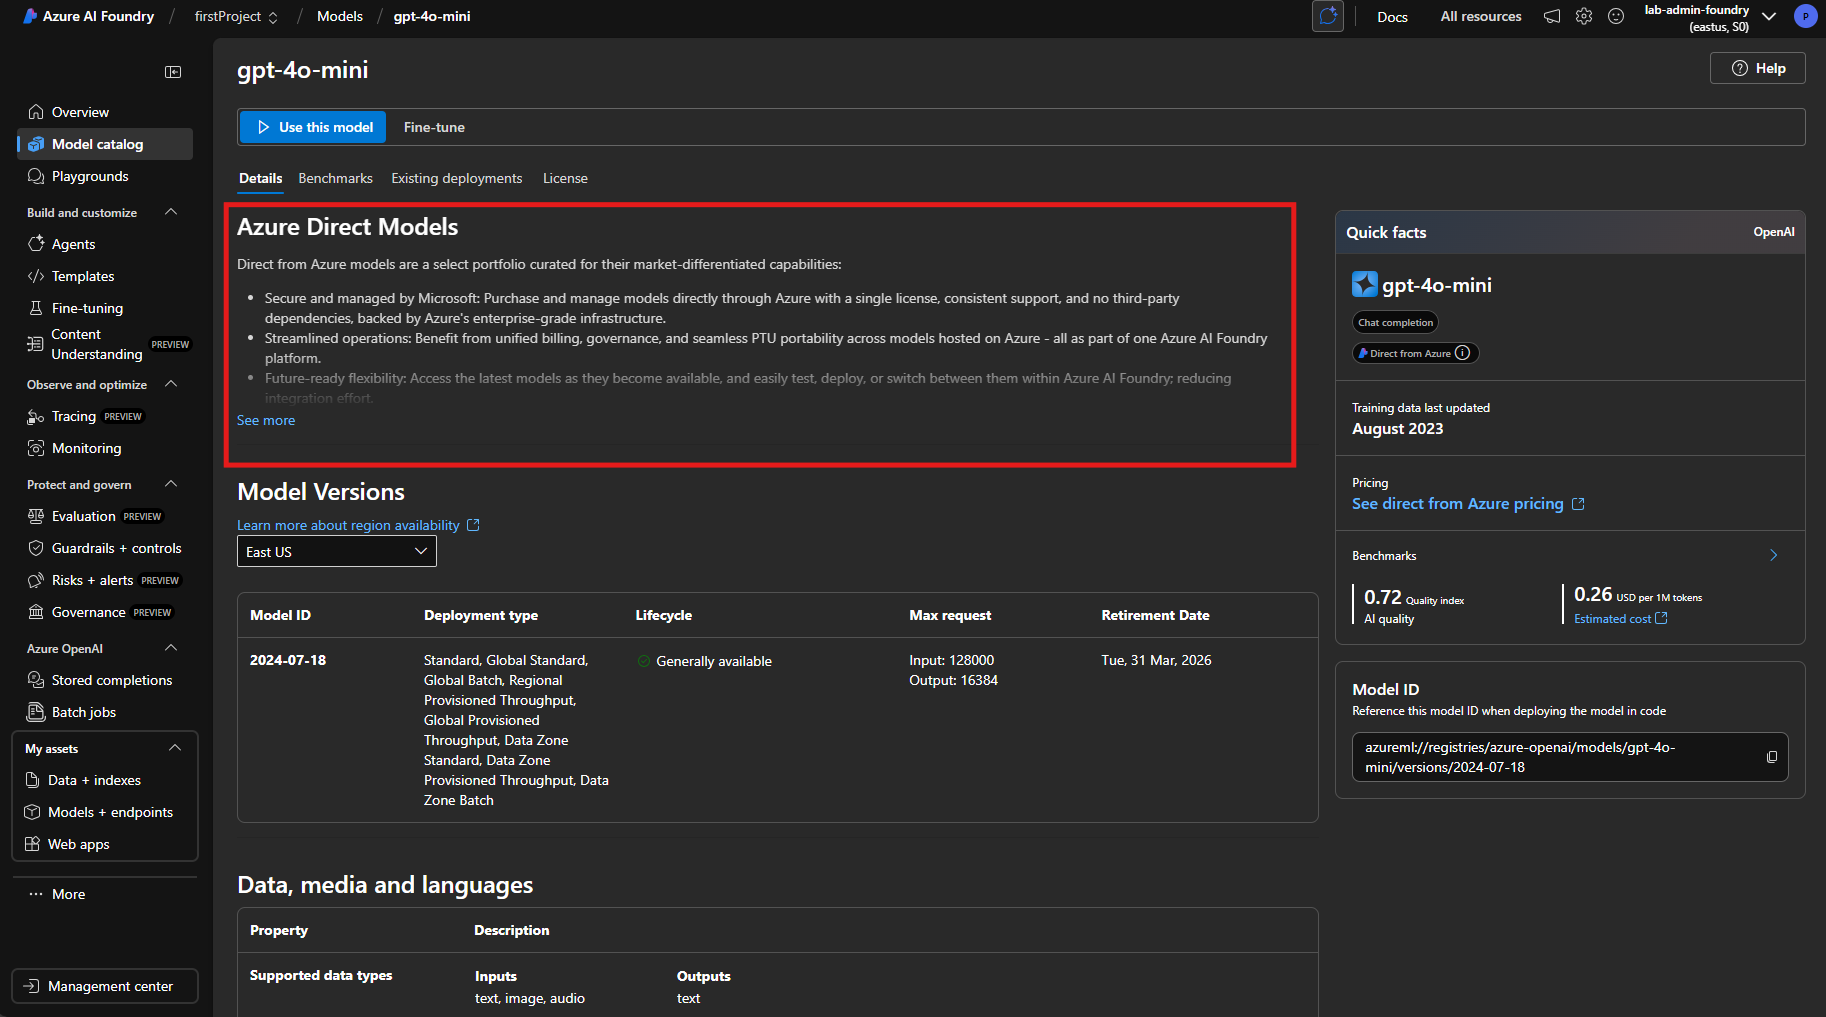

## Model versions (region, lifecycle, limits)

* **Region selector (e.g., East US):** Availability is **region-specific**. Choose the region of your **AI Project**.
* **Version table** (one row per version):

  * **Model ID (e.g., 2024-07-18):** The version label/date.
  * **Deployment type:** Supported options such as:

    * **Standard** / **Global Standard** — managed endpoints; steady latency.
    * **Provisioned Throughput** — reserved capacity for predictable high volume.
    * **Batch / Data Zone** variants — for bulk/offline or specific data boundary needs (if present).
  * **Lifecycle:** e.g., **Generally available**.
  * **Max request:** **Input** (context window) and **Output** token limits (e.g., Input **128,000**, Output **16,384**).
  * **Retirement date:** When the version will be sunset.

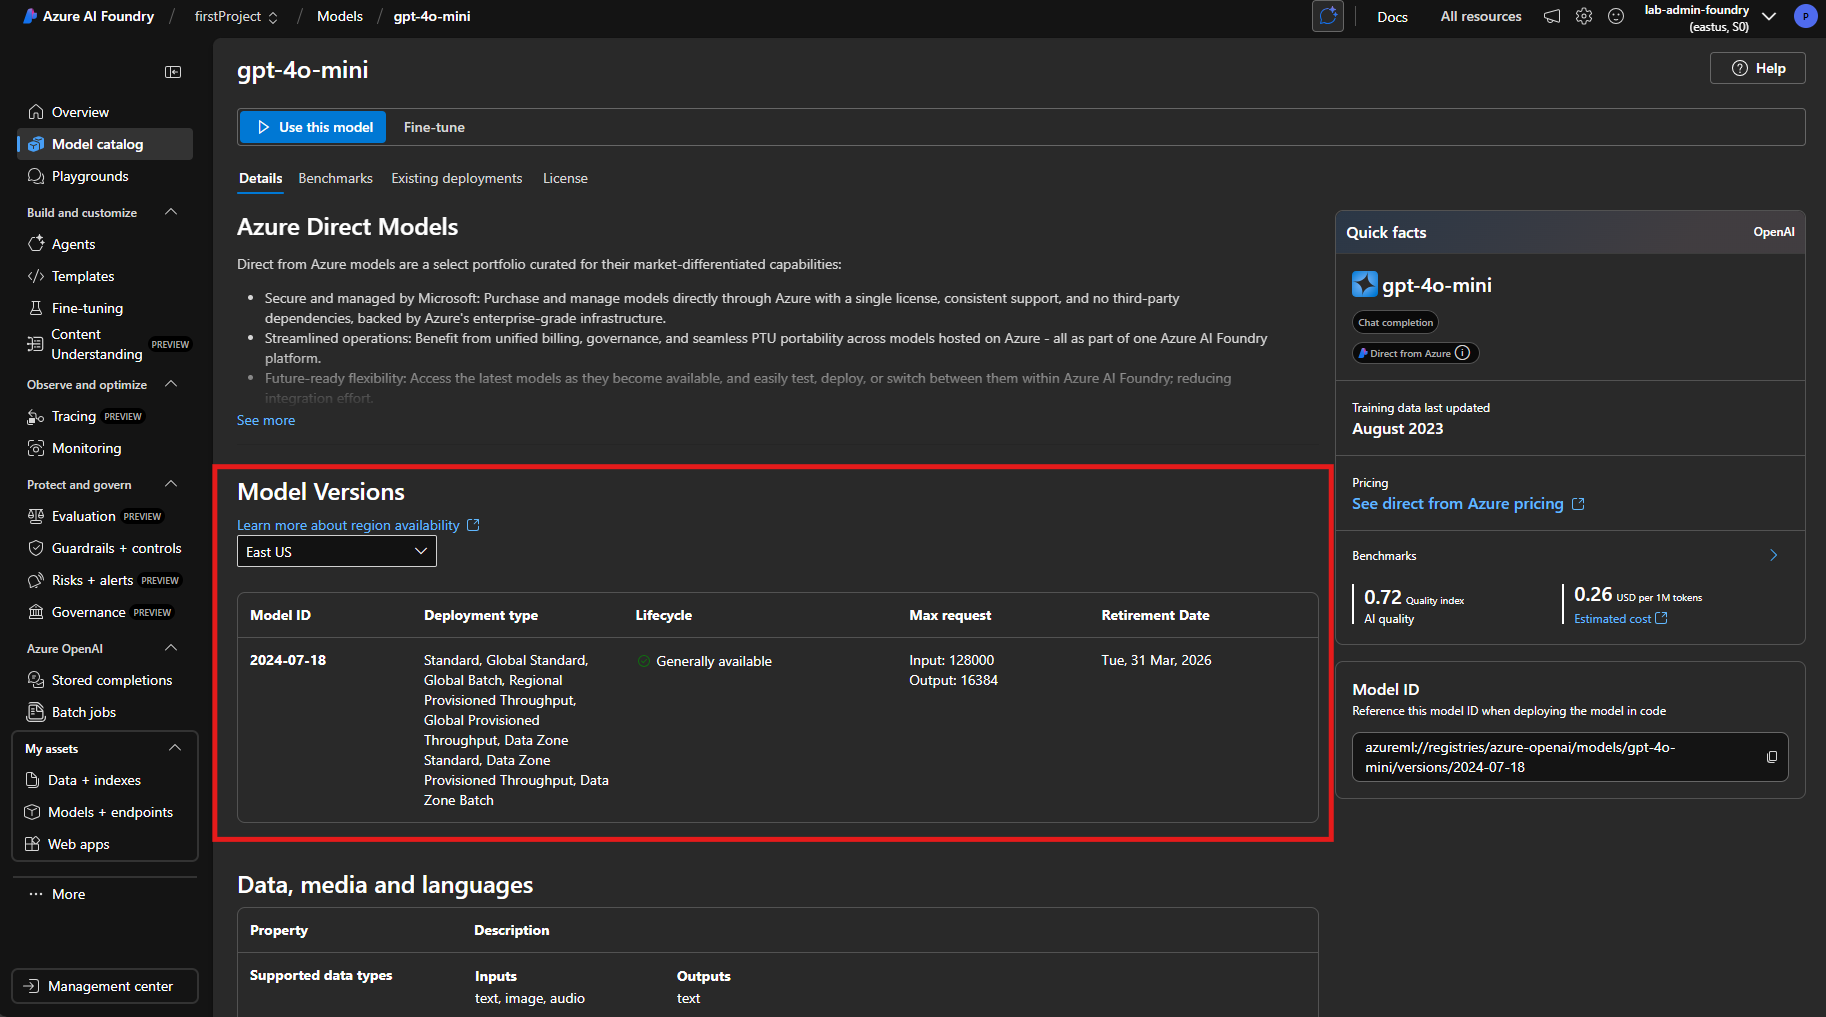


## Data, media, and languages

* **Supported data types:** What modalities the model accepts/produces.
  *In your screenshot:* **Inputs:** text, image, audio; **Outputs:** text.
* **Supported languages:** List of ISO language codes.

**Why it matters:** Confirms whether multimodal prompts (images/audio) are allowed, and which languages are reasonably supported.


## Transparency & Responsible AI considerations

* **Safety techniques:** High-level notes on filtering, policy alignment, and post-training alignment (e.g., RLHF/RLAIF).
* **What to do as a builder:** Still apply **guardrails**, content filters, and human review where needed. Document safety settings in your deployment.


## More details from the model provider

* **Quality & performance evaluations:** Provider-shared benchmarks and qualitative guidance (e.g., how this compares to prior versions).
* Use these figures as **directional**; always validate with your **own prompts** in the **Playground** and with your **domain data**.

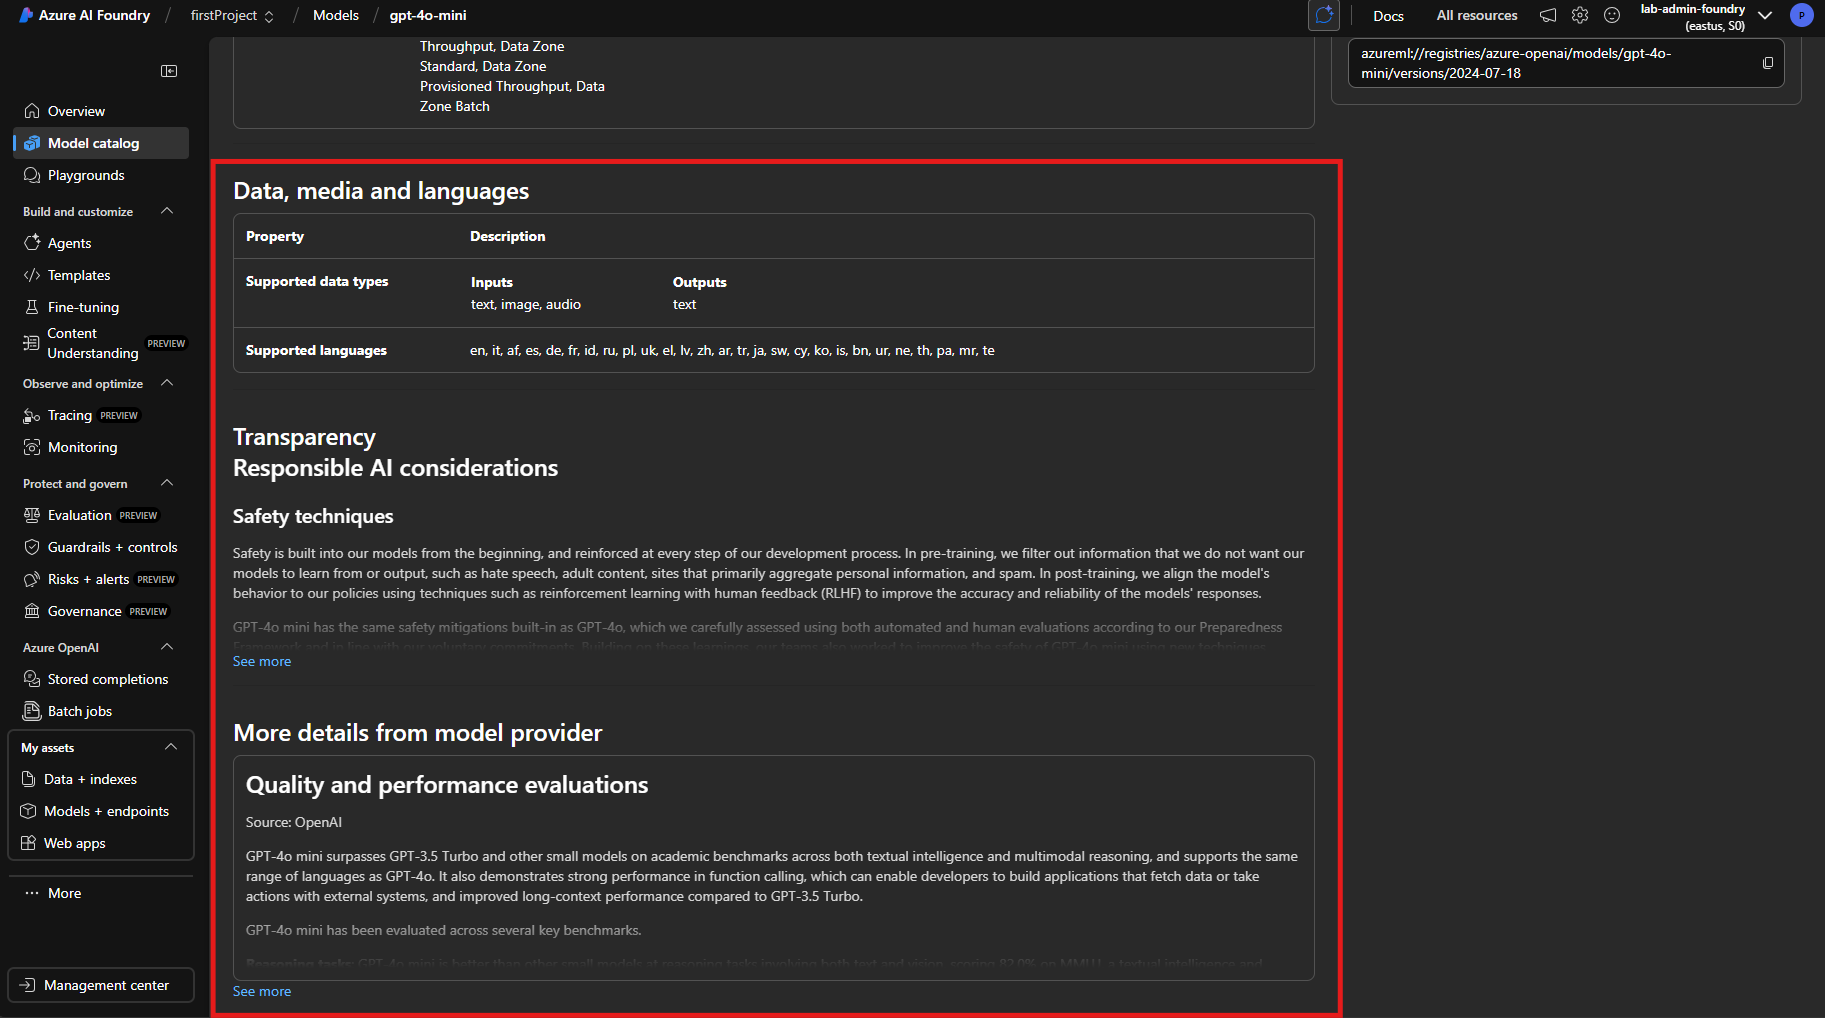



# Deploy the model

**PS: Please validate if a model is already deployed for you by the lab administrator, in that case, please jump directly to the next section.**

1. Click on `Use this model`
2. Leave all the details as-is and click on Deploy

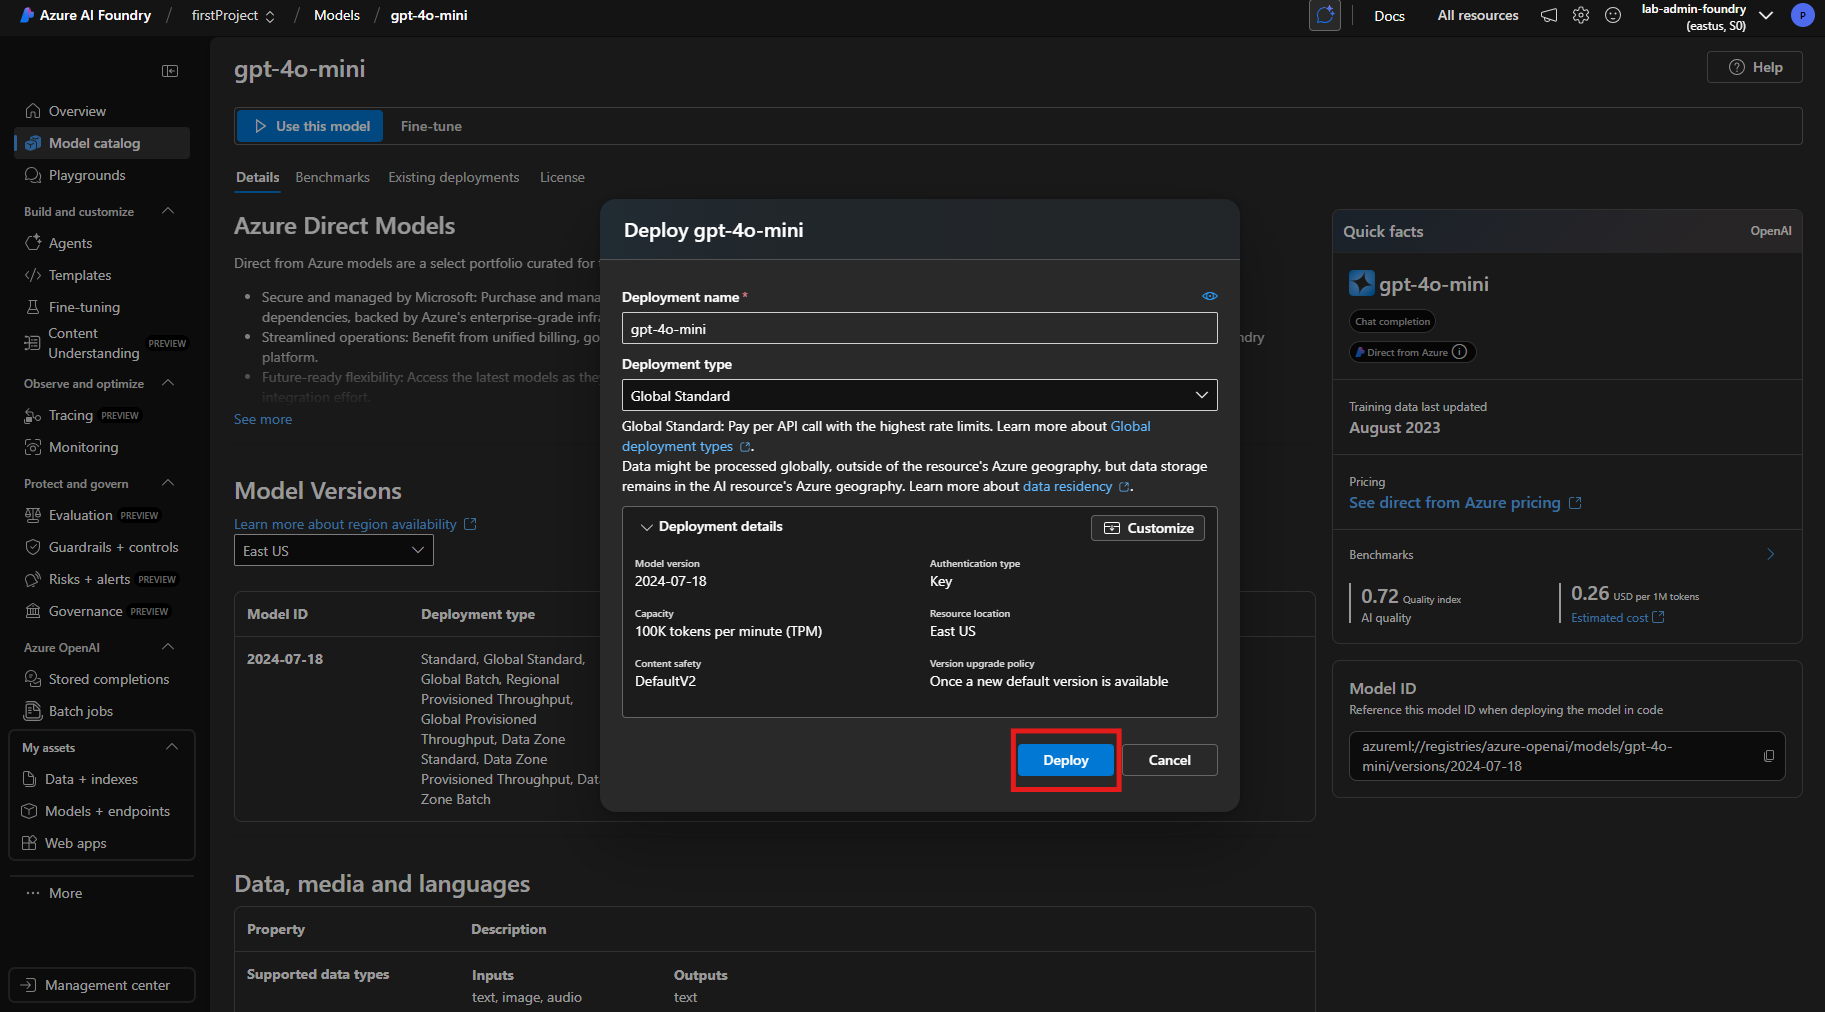



**Resource deployed for you already? Follow these cells to access your model details**

1. Click on `Models + Endpoints` under `My assets`
2. Select the deployed model

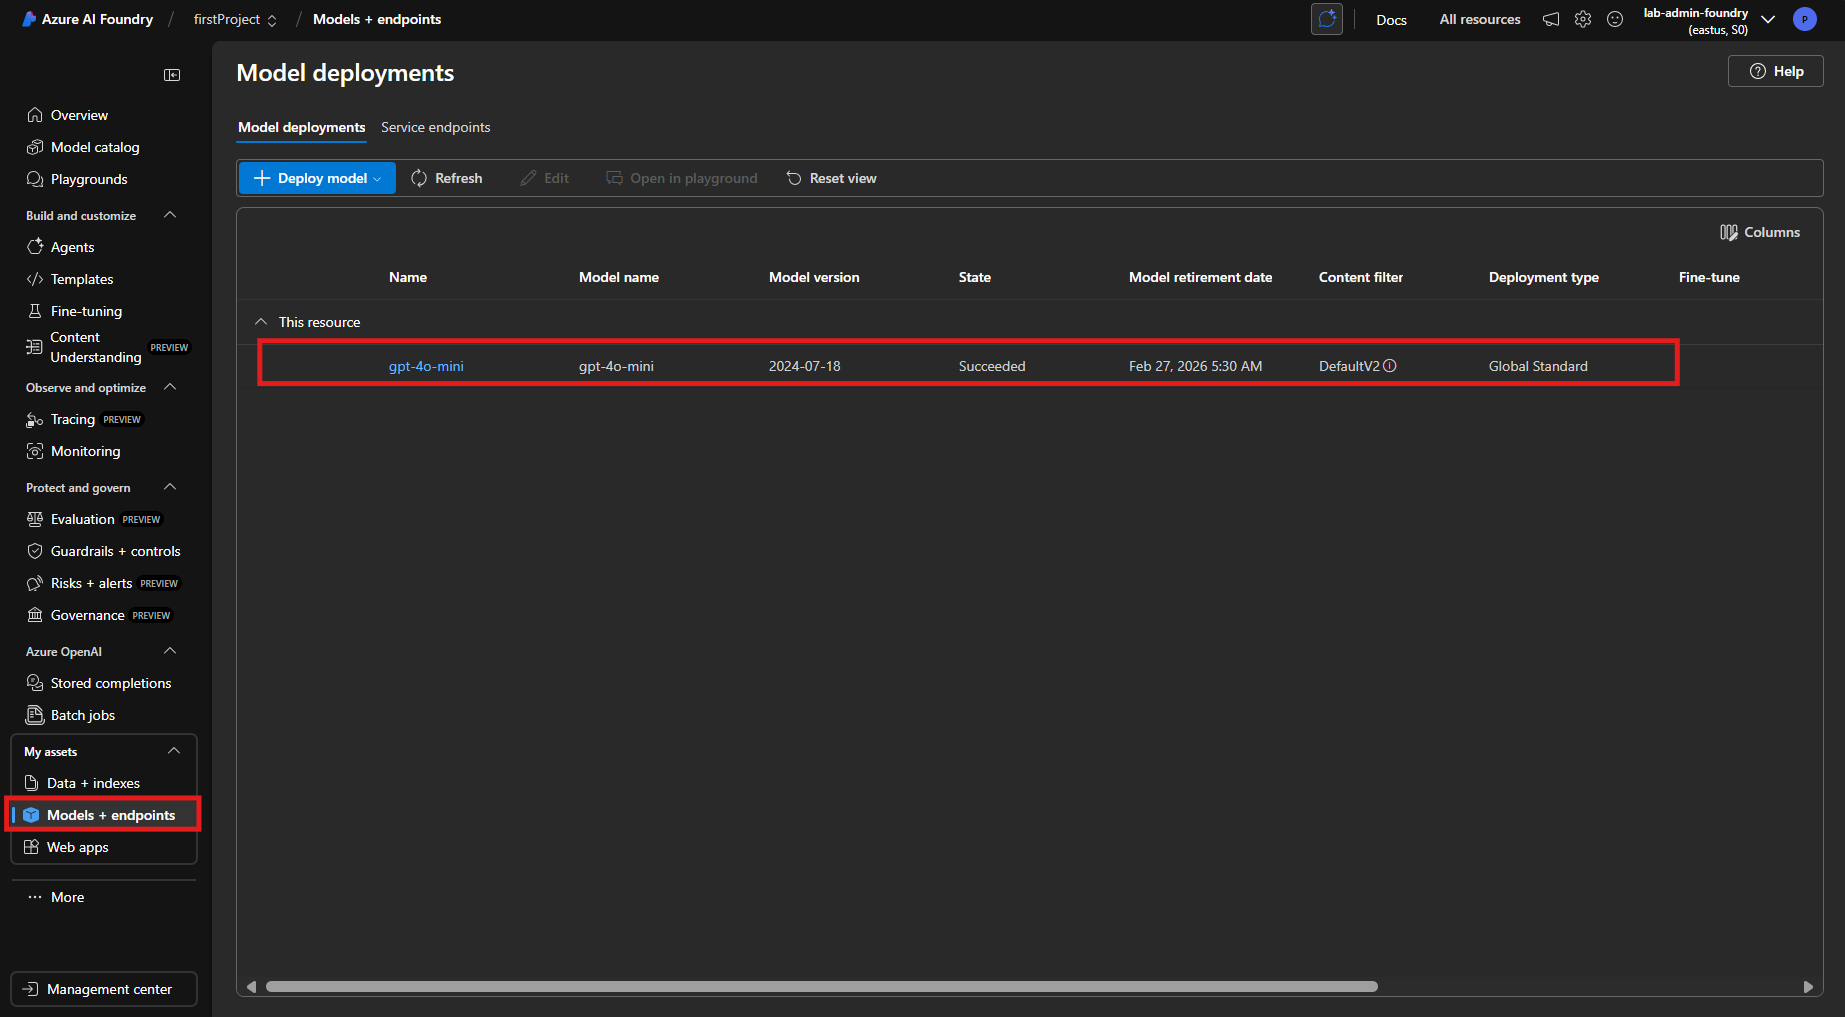

# Deployed Model Page — What Everything Means

## 1) Header & quick actions

* **Model / deployment name:** `gpt-4o-mini` (this is the **deployment name** you’ll pass as the `model` parameter in SDK/REST).
* **Open in playground:** Jumps to **Playgrounds → Chat** with this deployment preselected.
* **Request quota / Edit / Delete:** Raise limits, rename/update settings, or remove the deployment.

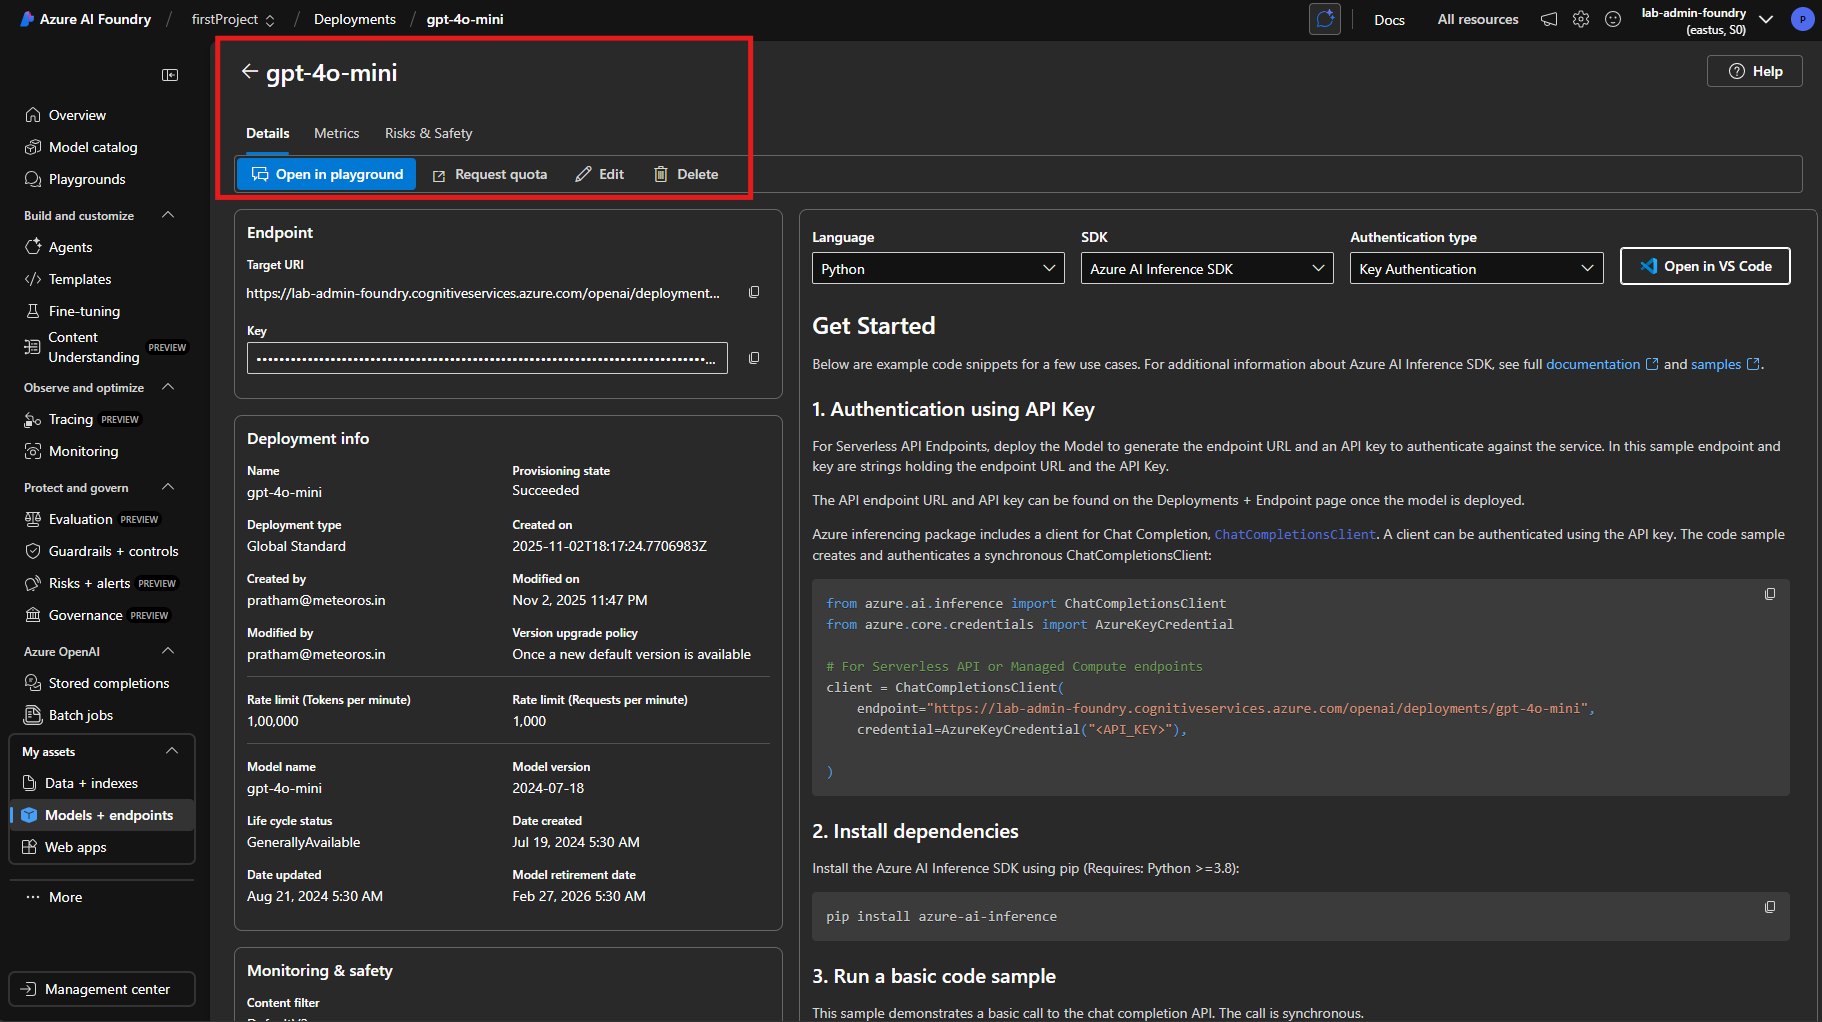

## 2) Endpoint block (left, top)

* **Target URI:** The exact **endpoint URL** for this deployment (copy icon).
  Example pattern:
  `https://<project>.cognitiveservices.azure.com/openai/deployments/<deploymentName>`
* **Key:** Masked **API key** for this project (copy icon). Use as Bearer token for key-based auth.

**Use in code:** Pair **Target URI** + **Key** with your **deployment name**. Include the **API version** query parameter required by this endpoint when calling REST.

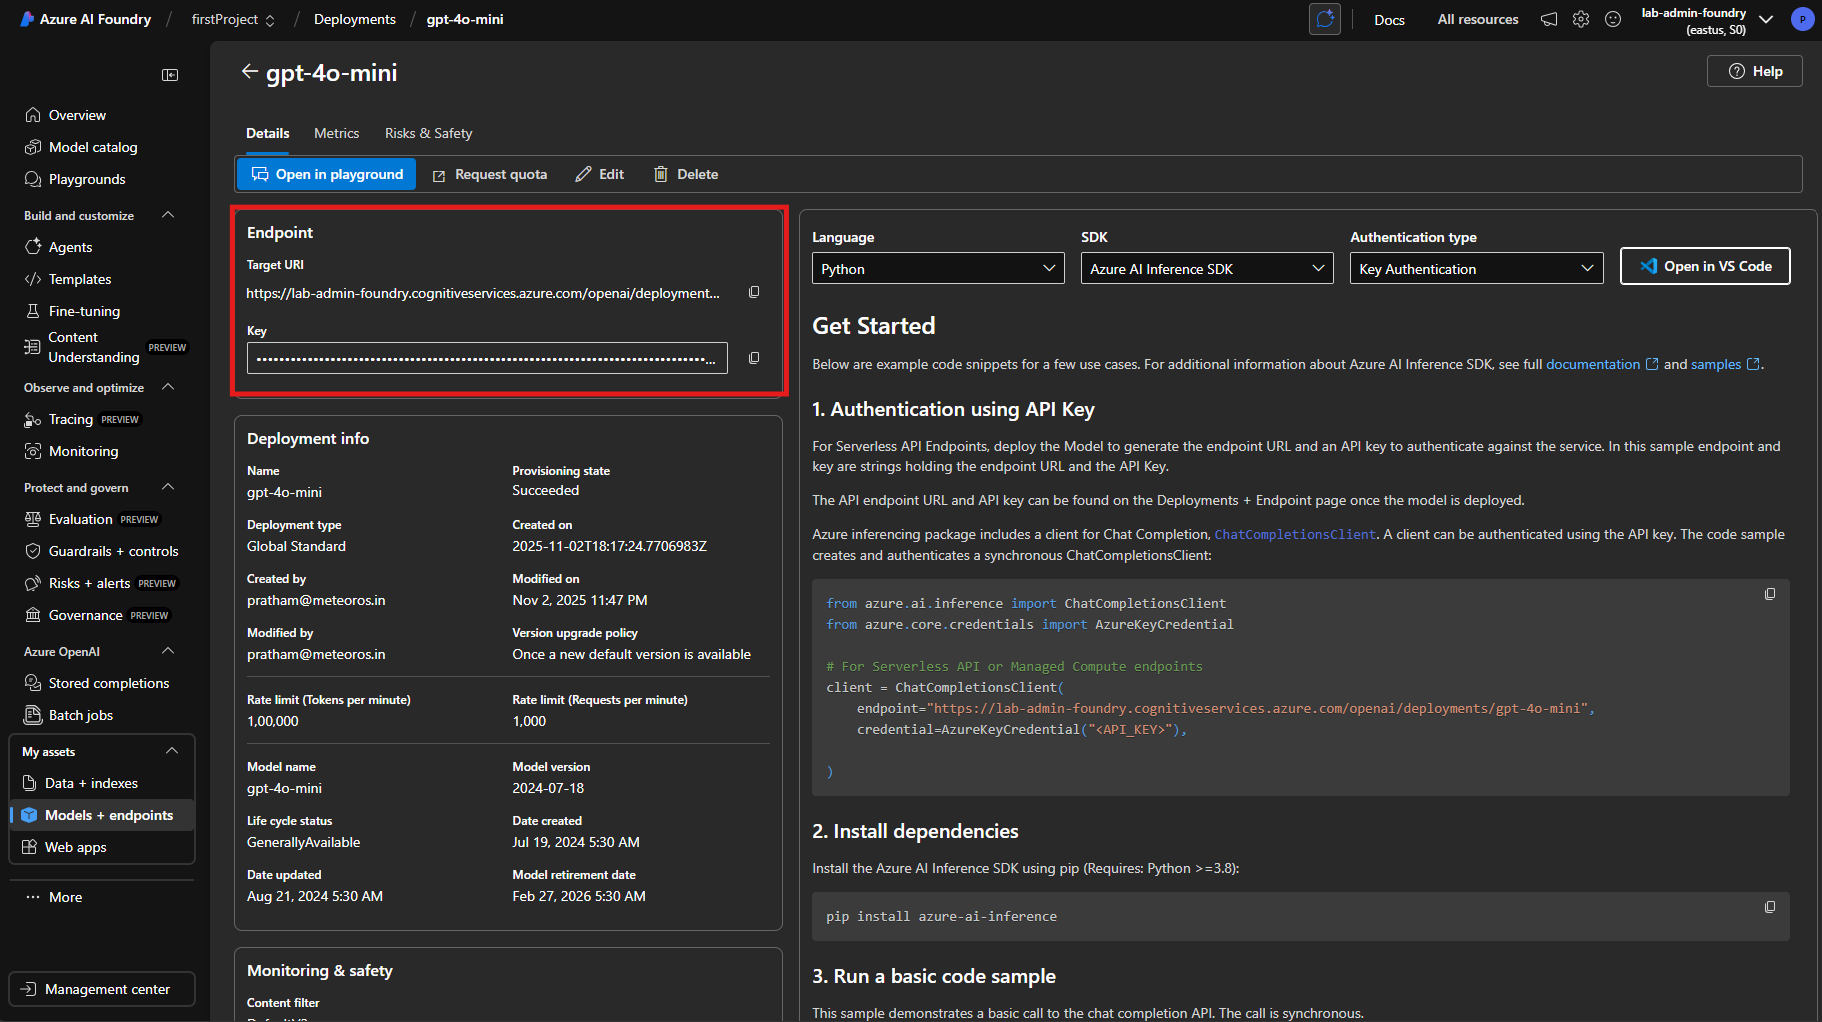

## 3) “Get Started” code panel (right)

* **Language / SDK / Authentication type** selectors: switch between Python/JS/REST and key vs Entra ID.
* **Auth sample:** Shows how to instantiate the **Azure AI Inference SDK/Azure OpenAI SDK/OpenAI SDK** `ChatCompletionsClient` with your endpoint + key.
* Eg: **Install dependencies:** `pip install azure-ai-inference`
* **Basic call sample:** Minimal chat completion example you can copy into your lab notebook/app.

**Tip:** Keep temperature low (e.g., `0–0.3`) for deterministic lab outputs.

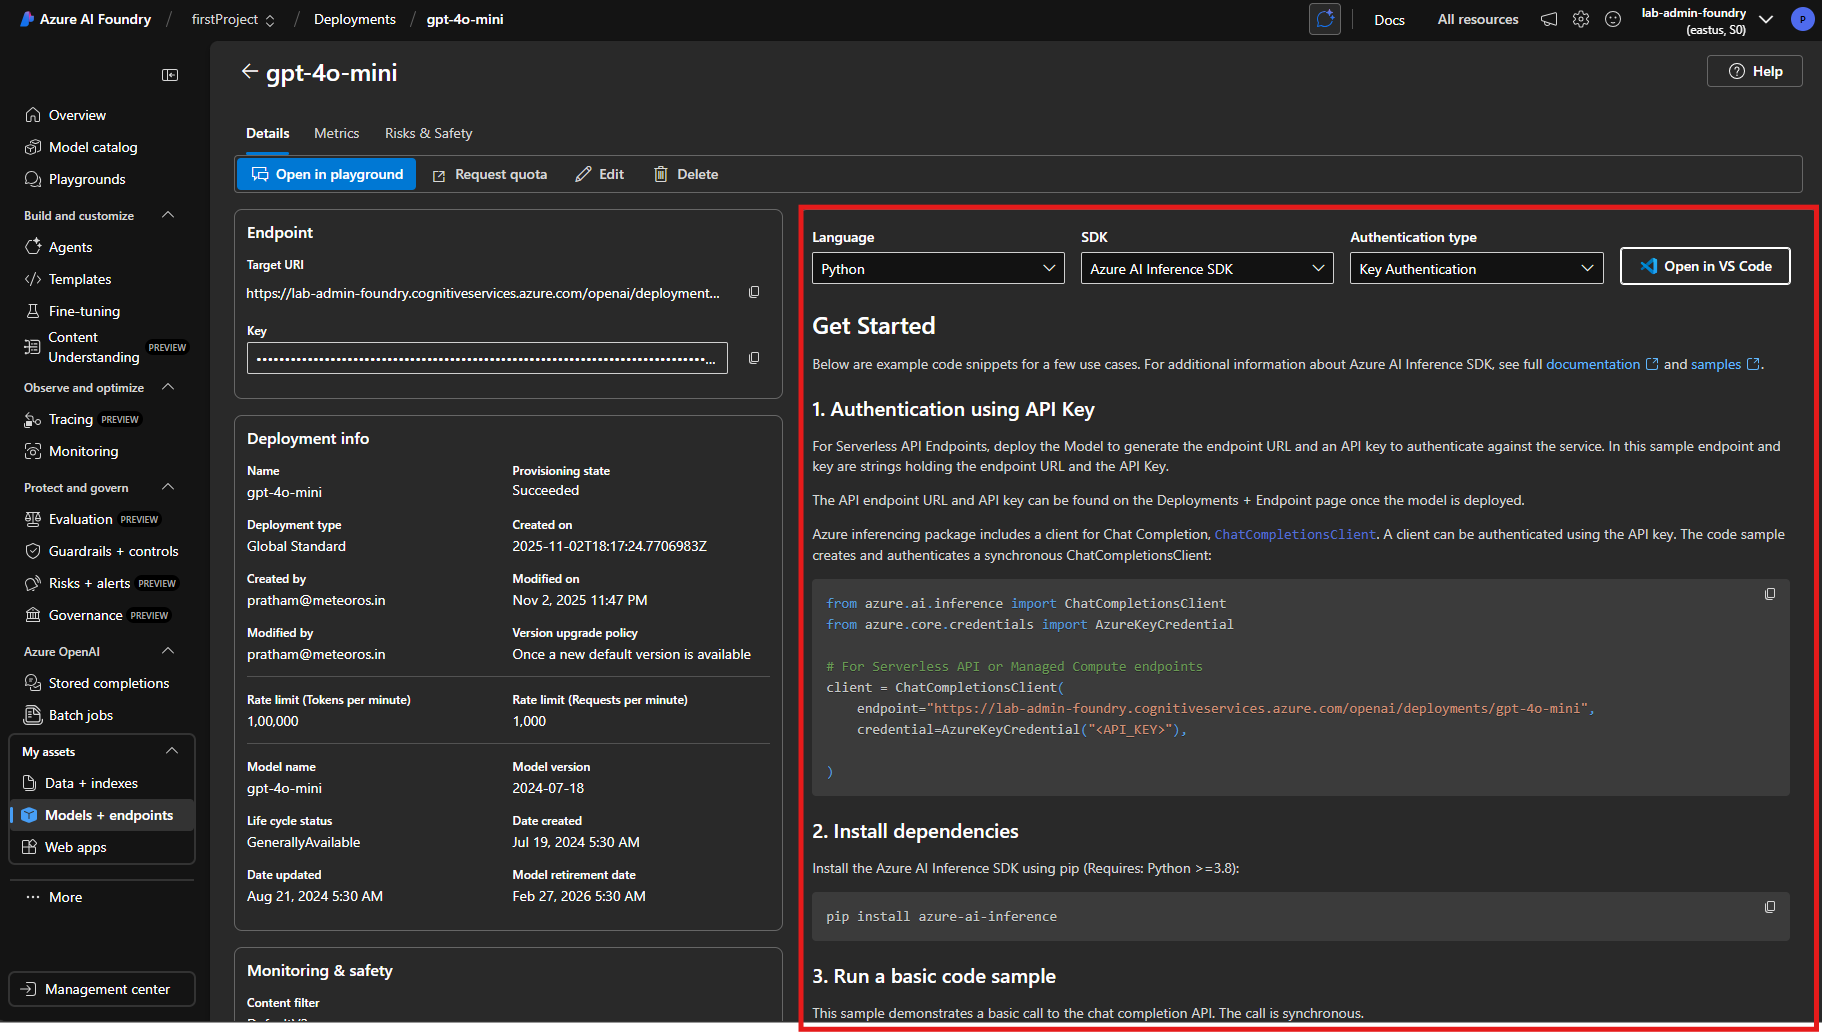

## 4) Deployment info (left, mid)

Operational details you’ll reference during testing and troubleshooting:

* **Name:** `gpt-4o-mini` (deployment name).
* **Provisioning state:** **Succeeded** → endpoint is ready to use.
* **Deployment type:** e.g., **Global Standard** (managed endpoint with steady latency).
  Other possibilities you may see elsewhere: **Standard**, **Provisioned Throughput**, **Batch/Data Zone**.
* **Created by / Modified on / Modified by:** audit trail.
* **Version upgrade policy:** Whether it auto-offers newer base model versions.
* **Rate limits:**

  * **Tokens per minute (TPM)** (e.g., **1,000,000** TPM).
  * **Requests per minute (RPM)** — plan concurrency accordingly.
* **Model name & version:** e.g., `gpt-4o-mini`, **2024-07-18** (ties back to the Model page).
* **Lifecycle status:** e.g., **GenerallyAvailable**; also shows **retirement date** so you can plan upgrades.

**When you hit errors:**

* **401/403** → auth or role issue (wrong key / insufficient RBAC).
* **429** → throttled by TPM/RPM; reduce concurrency, shorten prompts, or request quota.
* **422** → unsupported parameters; check API version & body shape.

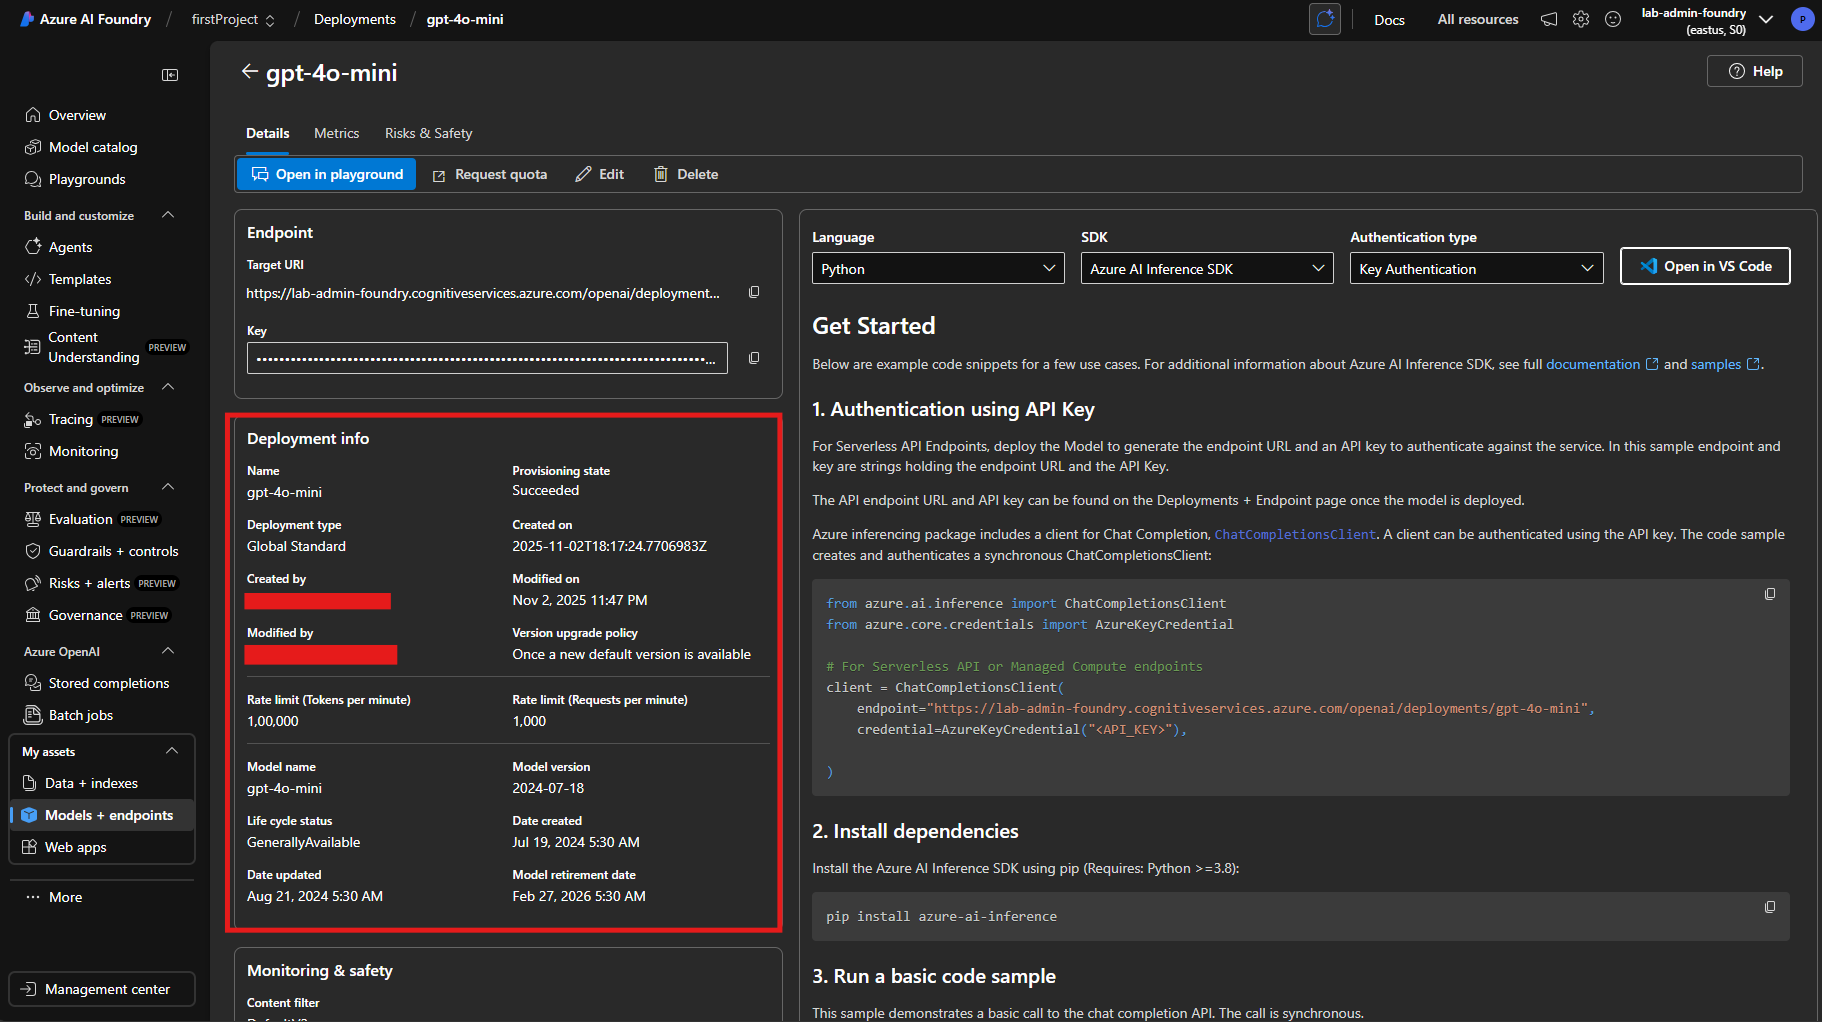

## 5) Monitoring & safety (left, lower)

* **Content filter / safety:** Indicates the policy filters applied at this deployment.
  Configure stricter guardrails at the project/hub level if needed and test behavior in Playground.

## 6) Quick validate steps (1 minute)

1. Click **Open in playground** → send a short prompt with the default **system message**

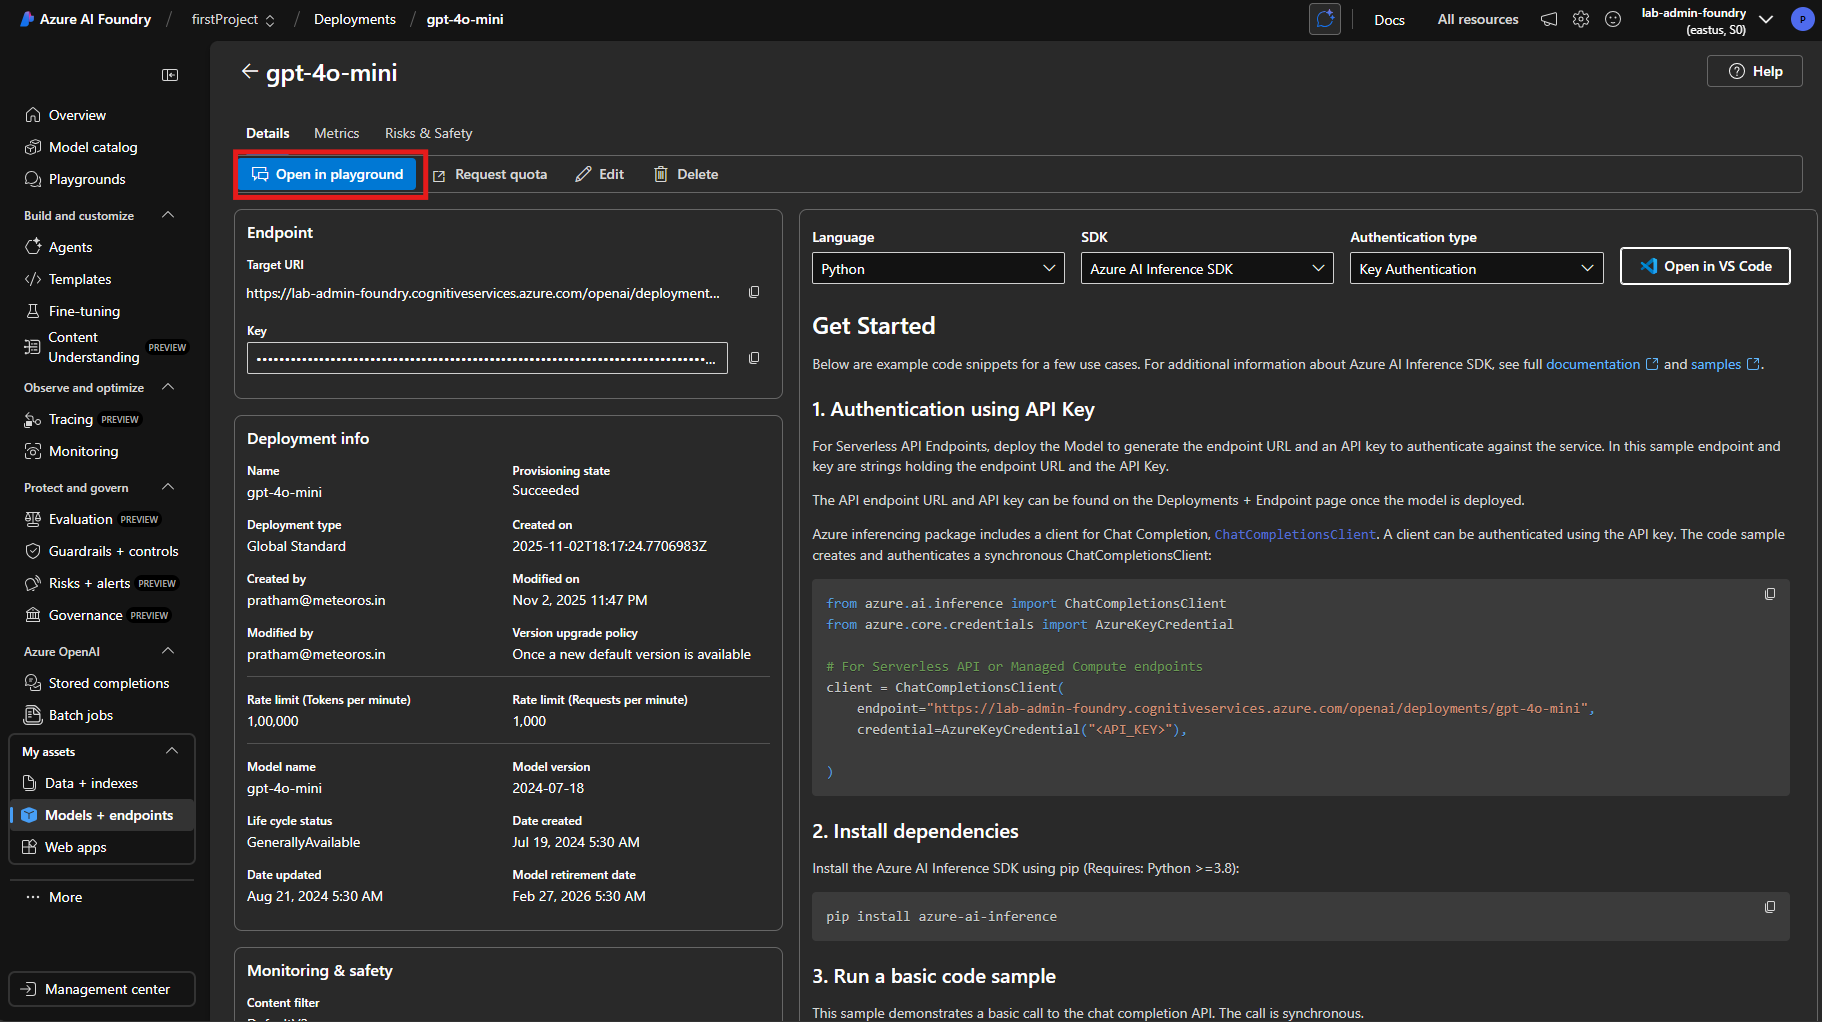


# Chat Playground — What Each Area Does

## Purpose

A safe space to **prototype prompts**, **tune parameters**, and **validate behavior** of a deployed model **before** writing code. Use it to lock in a good system prompt and default settings.

## Top bar actions

* **View code** — Generates ready-to-copy SDK/REST snippets that mirror your current playground setup (deployment + params + messages).
* **Deploy** — Shortcut to create a new deployment if you haven’t.
* **Import / Export** — Save/load playground sessions (prompts, params) for reproducibility.
* **Prompt samples** — One-click starters to demonstrate different prompting styles.
* **Filters feedback** — See when content filters triggered and why (useful for safety tuning).

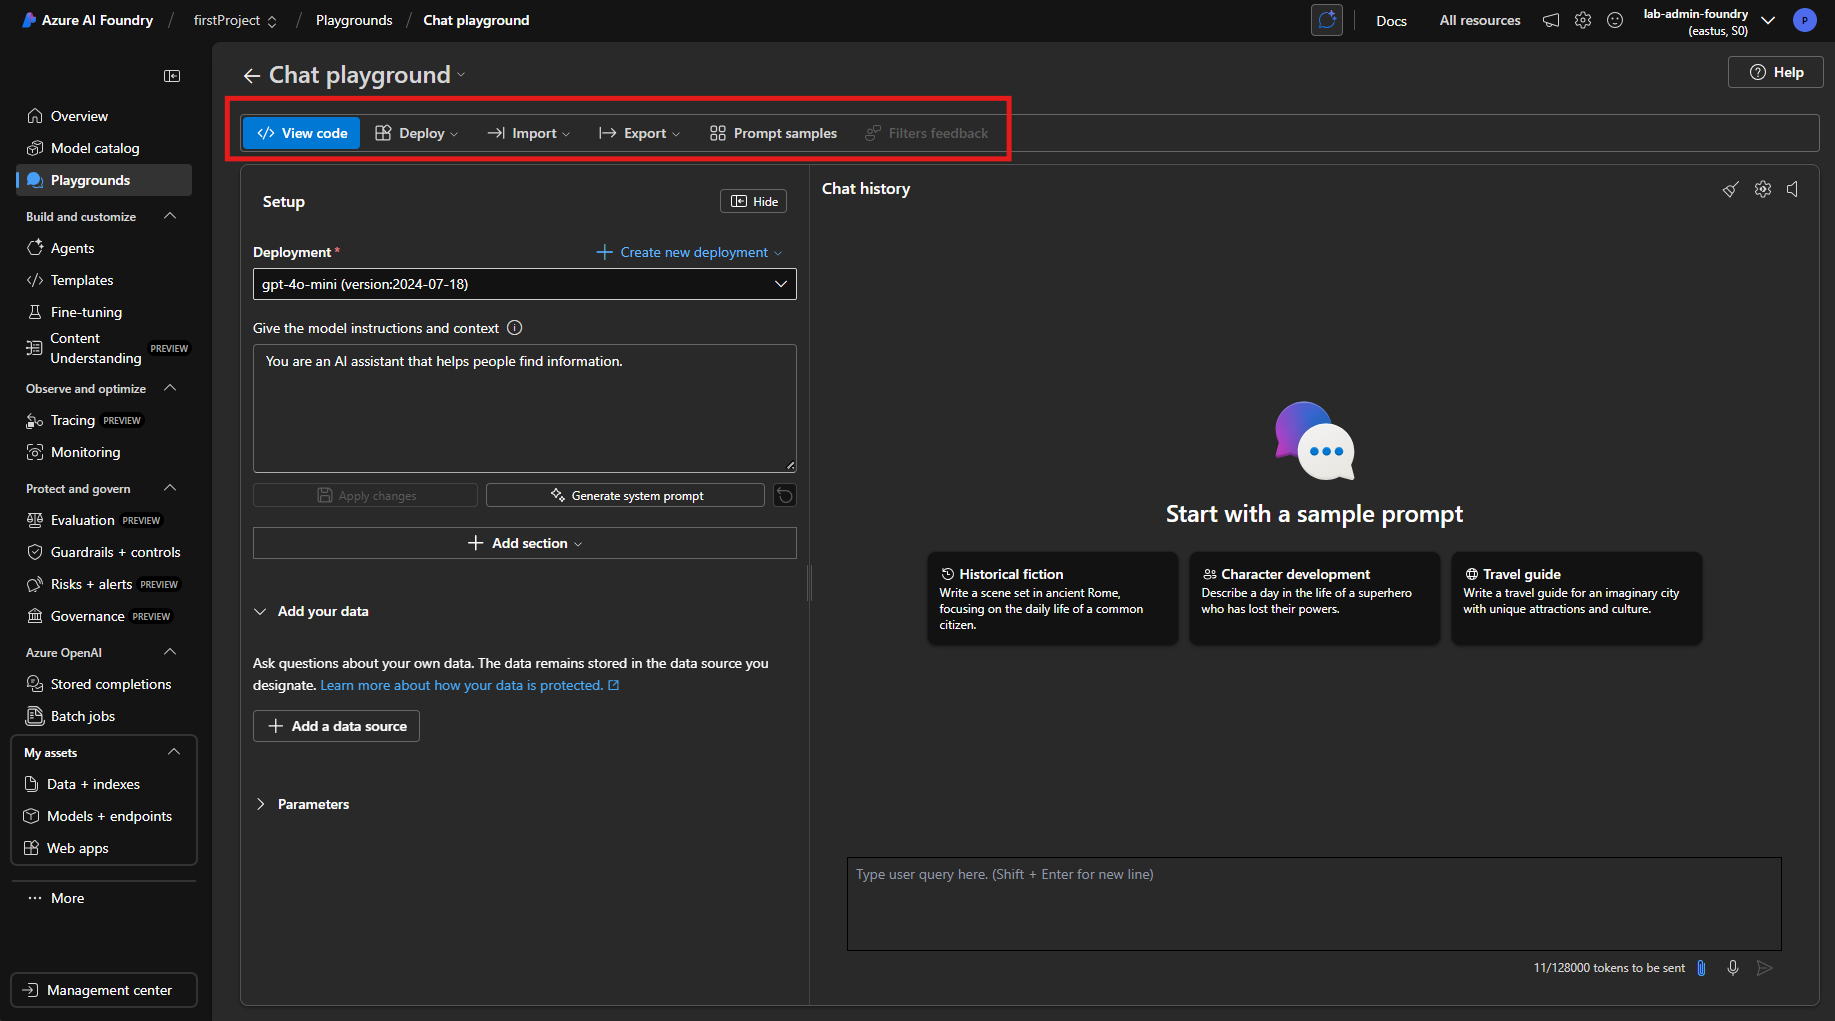

## Left pane — Setup

### 1) Deployment selector

* Dropdown showing your **deployment** (e.g., `gpt-4o-mini (version:2024-07-18)`).
* **Create new deployment** link for fast model provisioning.

### 2) System message (“Give the model instructions and context”)

* The **behavior contract** for the model (role, style, constraints).
* Examples:

  * “You are a concise assistant.”
  * “Return **only valid JSON** matching the provided schema.”
* **Generate system prompt** can scaffold a baseline from your goal.
* **Apply changes** locks new instructions before you test.

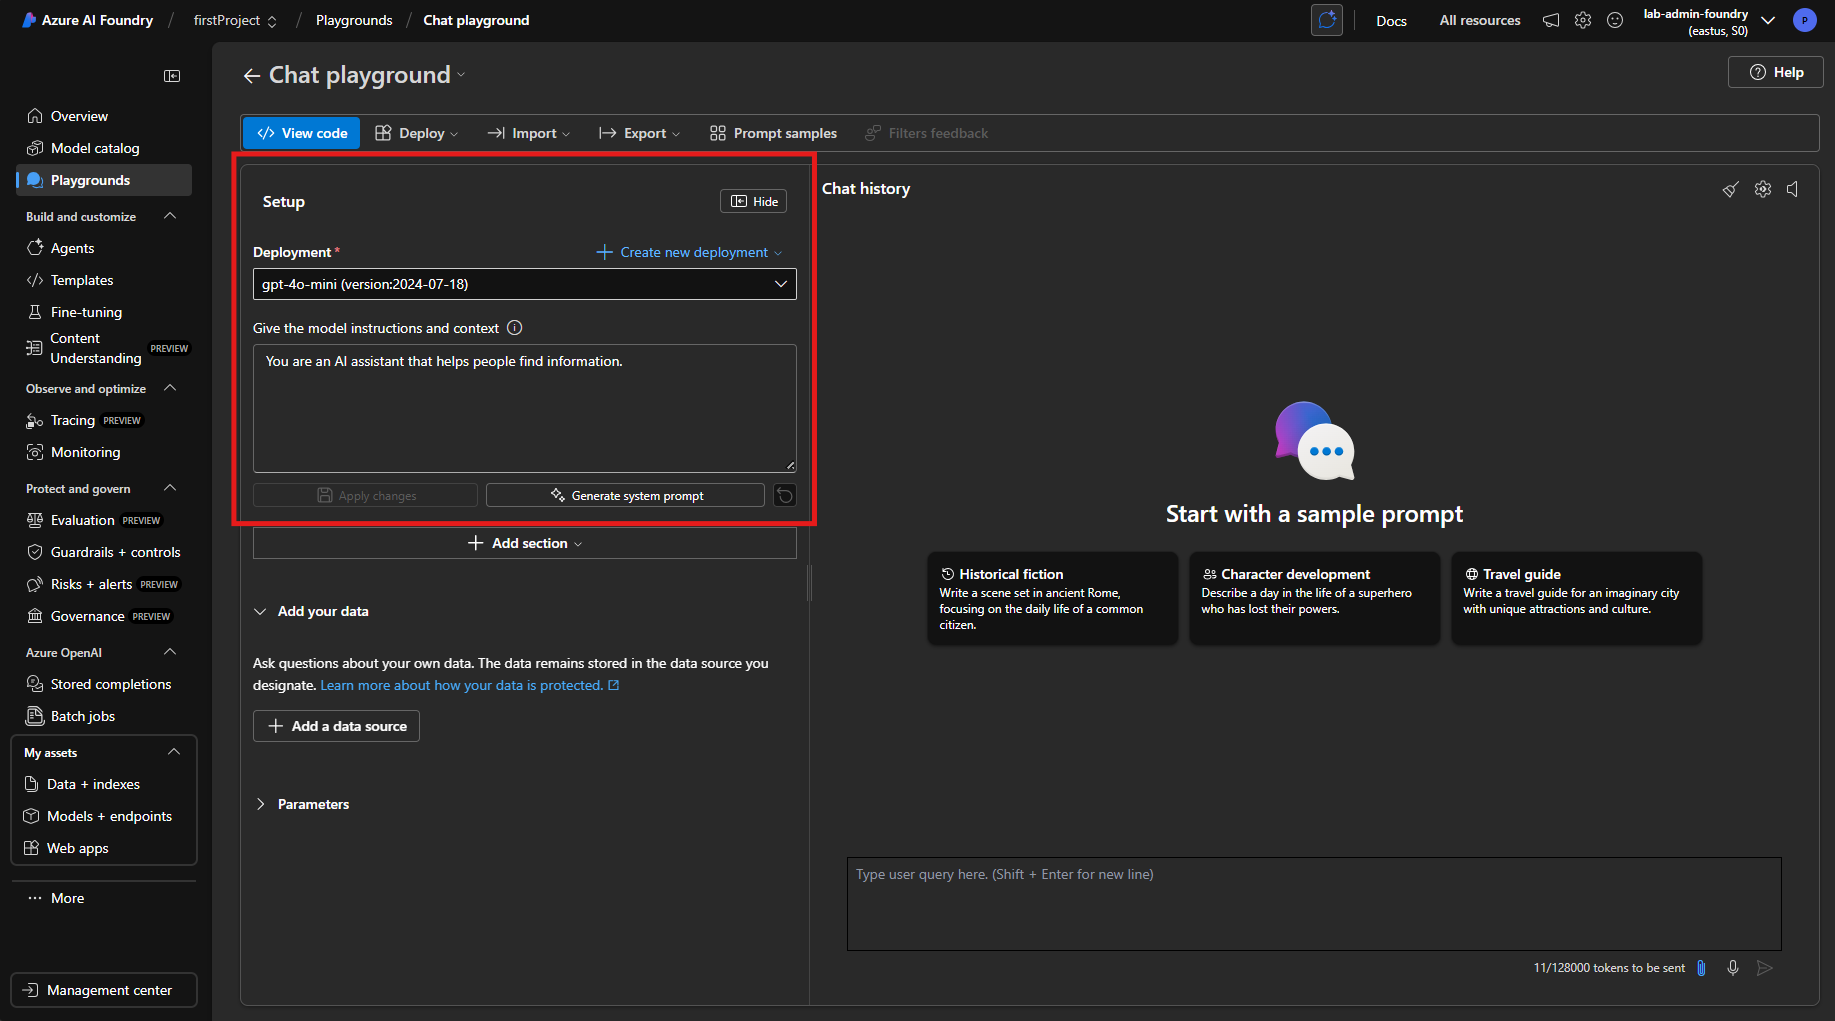

### 3) Add section

* Options to insert extra guidance for structured scenarios:
- Safety system messages
- Examples
- Variable


### 4) Add your data (RAG hookup)

* **Add a data source** to ground answers in enterprise content (indexes, files, etc.).
* Data remains in your designated storage; the model receives **retrieved snippets** as context.

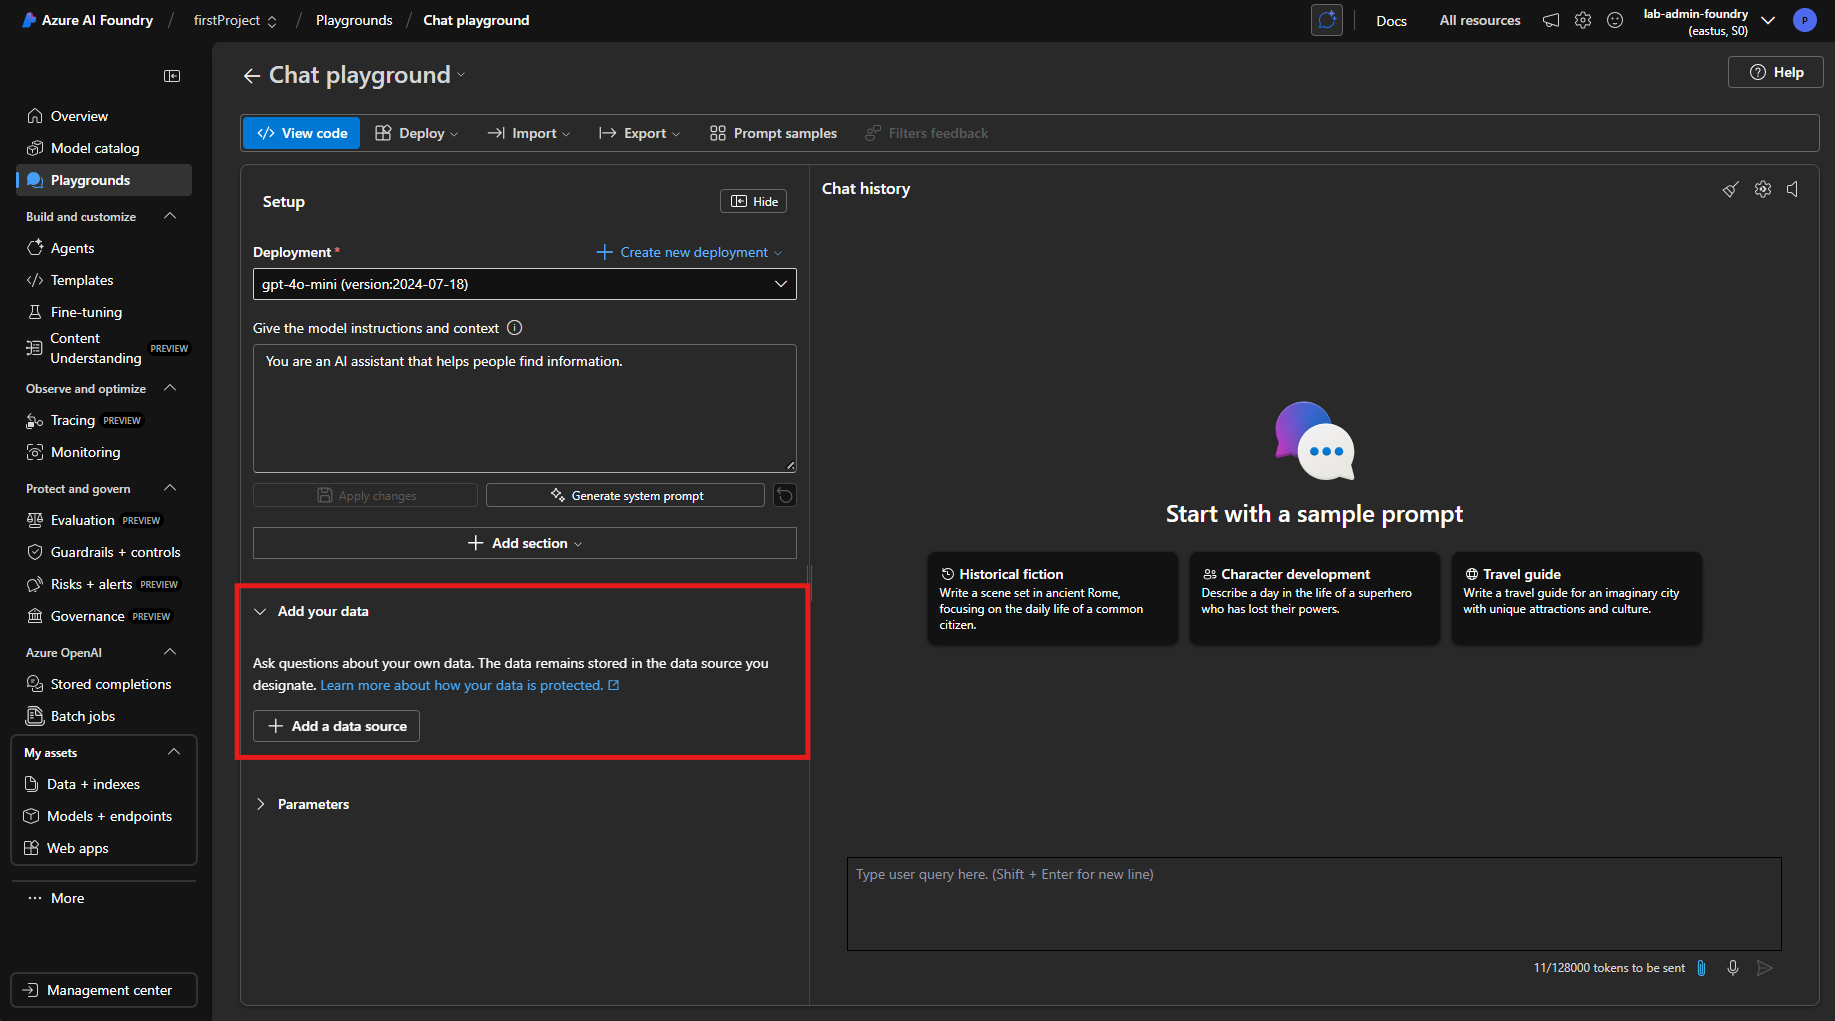

### 5) Parameters

### 1) Past messages included

* **What it controls:** How many prior turns (system/user/assistant) the model sees from the current chat history.
* **Effect:** More history ⇒ better continuity and references; fewer ⇒ cheaper, faster, less risk of drifting off-topic.
* **Gotchas:** History tokens consume the **context window**; large histories can trigger truncation.
* **Defaults to try:** 3–5 for task flows; 1–2 for form-like prompts where you want strict control.

### 2) Max response

* **What it controls:** Upper bound on the number of **output tokens** the model can generate.
* **Effect:** Prevents run-on answers and caps cost/latency.
* **Gotchas:** If set too low, you’ll see **truncation** (answers cut mid-sentence).
* **Defaults to try:** 200–300 for concise chat; raise to 600–800 for long summaries.

### 3) Temperature

* **What it controls:** Randomness of token sampling (creativity).
* **Effect:** Lower = deterministic, precise; higher = diverse, exploratory.
* **Gotchas:** High temperature can reduce factuality/format adherence.
* **Defaults to try:**

  * 0.0–0.3 → instructions/JSON outputs, evaluations
  * 0.4–0.7 → balanced drafting
  * 0.8–1.0 → brainstorming/creative writing

## 4) Top-p (nucleus sampling)

* **What it controls:** Samples only from the smallest set of tokens whose **cumulative probability ≥ p**.
* **Effect:** Another lever for diversity (often paired with temperature).
* **Gotchas:** Don’t crank **both** temp and top-p to extremes—outputs can become erratic.
* **Defaults to try:** 0.9–0.95 for natural prose; 0.7–0.85 for tighter control.

## 5) Stop sequence

* **What it controls:** One or more strings that, if emitted, **stop** generation immediately (they are not included in the final text).
* **Effect:** Lets you cut the answer at exact boundaries (e.g., when a JSON block ends, or before “Assistant:”).
* **Gotchas:** Choose sequences unlikely to appear in normal text (e.g., sentinel `"<END>"`).
* **Examples:**

  * `["\n\nHuman:", "\n\nUser:"]` to end before a new role header
  * `["</json>"]` if you wrap outputs in a custom tag

### 6) Frequency penalty

* **What it controls:** Penalizes tokens that have already appeared **often** in the output so far.
* **Effect:** Reduces **exact repetition** (e.g., looping words/phrases).
* **Defaults to try:** 0.1–0.3 if you see repeated lines or bullets.

### 7) Presence penalty

* **What it controls:** Penalizes tokens that have already appeared **at least once** in the output so far.
* **Effect:** Encourages introducing **new** topics/words instead of revisiting old ones.
* **Defaults to try:** 0.1–0.3 to promote variety in ideation tasks.


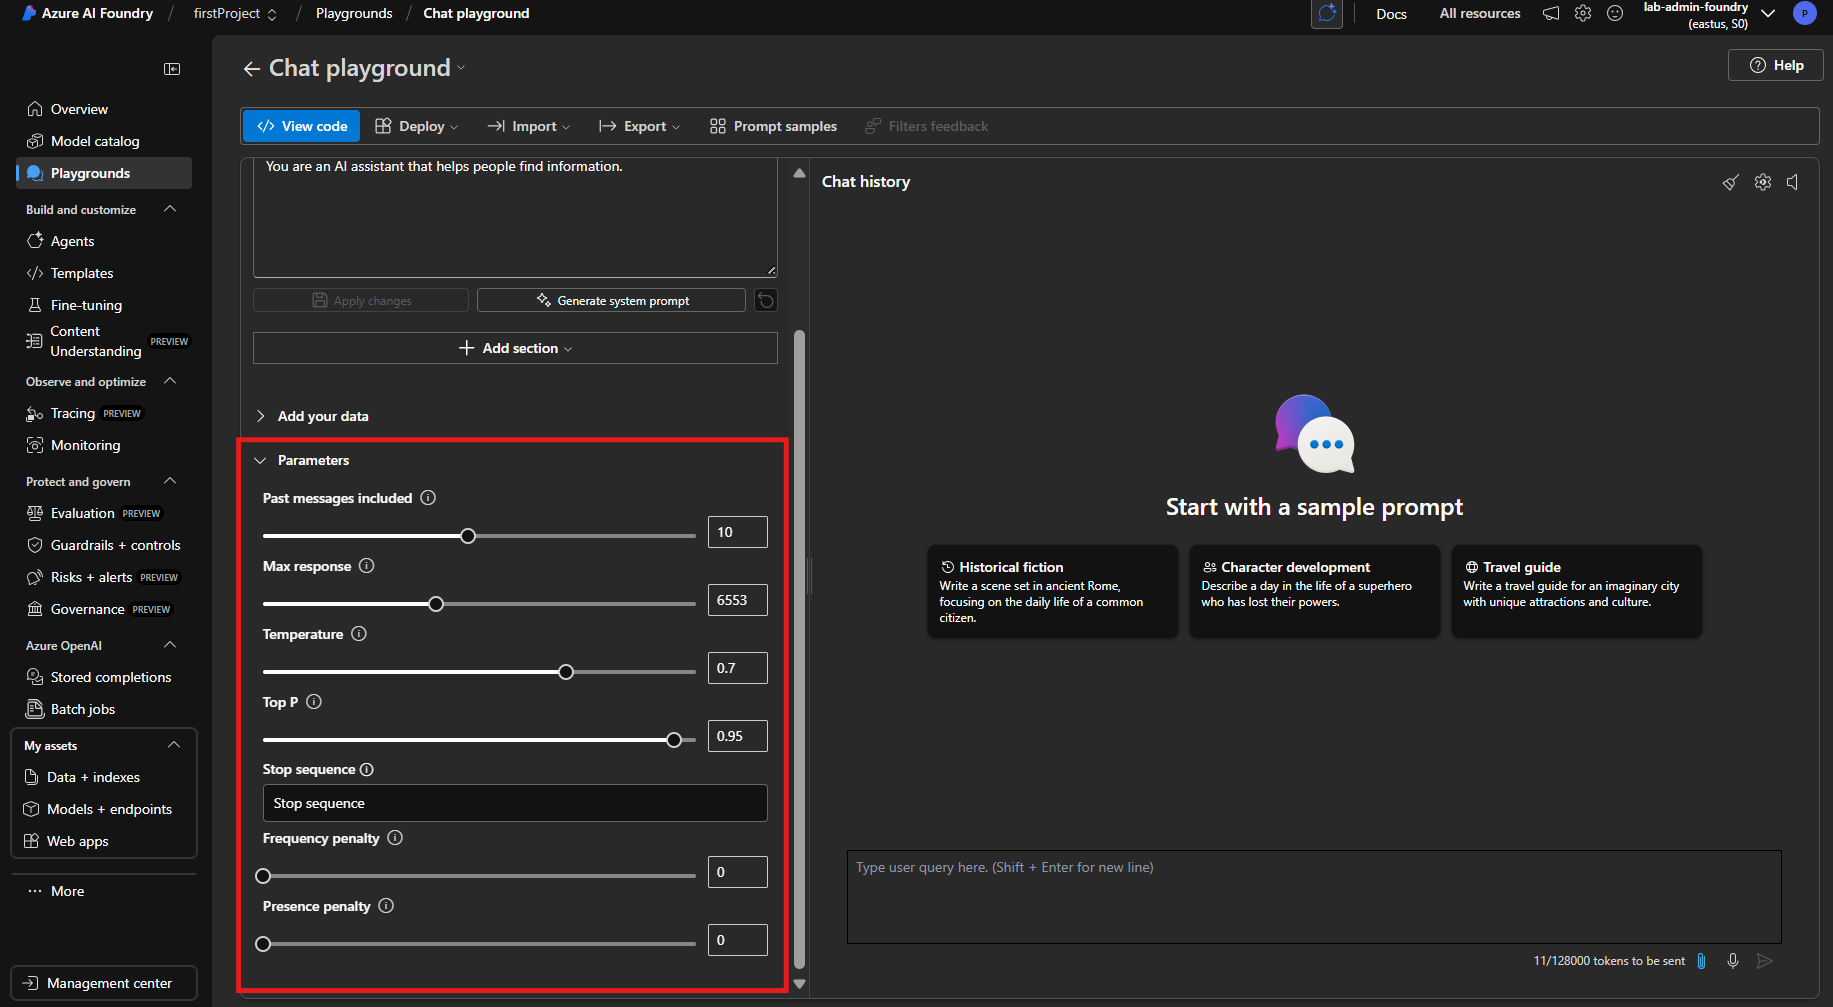

## Right pane — Chat area

### 1) Chat history panel

* Shows the ongoing conversation with the deployment you selected.
* Use it to observe **multi-turn memory** and how the system prompt persists.

### 2) Sample prompts

* Cards like *Historical fiction*, *Character development*, *Travel guide* to quickly sanity-check behavior. Replace with your lab tasks.

### 3) Input box

* Compose your **user** prompt.
* Token counter (e.g., **11/128000**) shows how much of the context window you’re using.
* **Shift+Enter** inserts a newline; **Enter** sends.

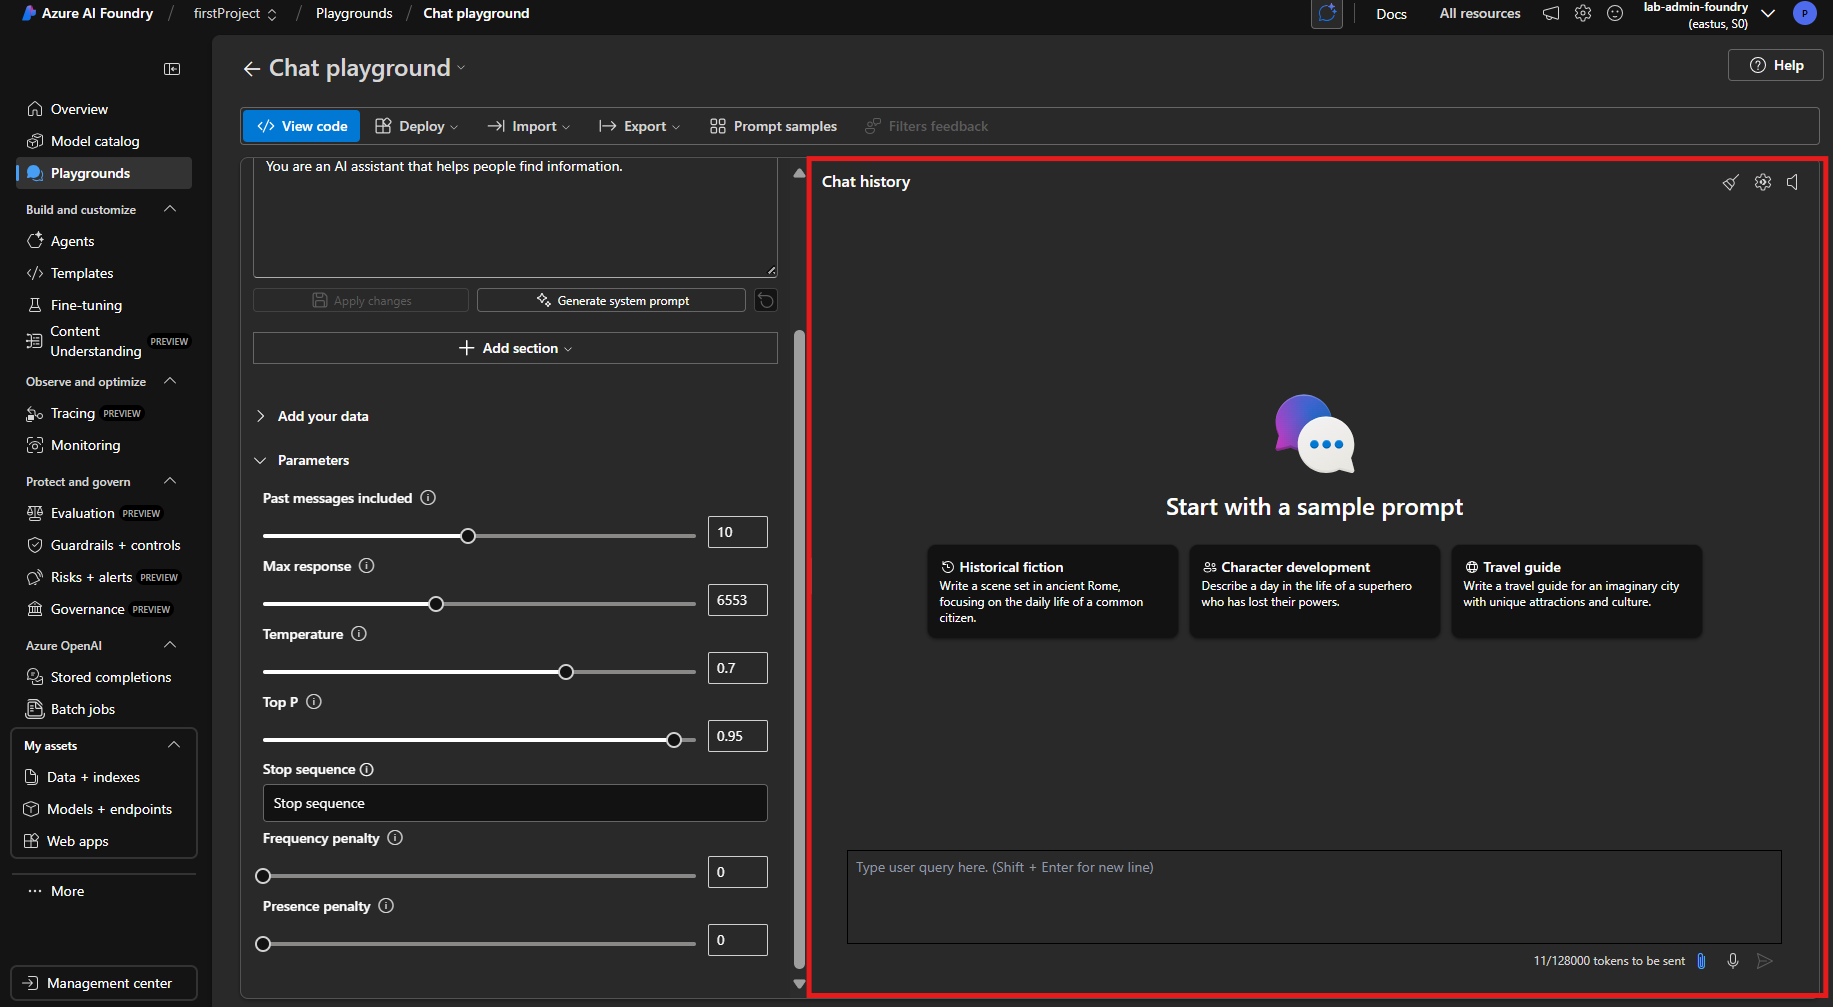

## How to use Playground effectively (general workflow to remember)

1. **Select deployment** → confirm it’s the one you just created.
2. Write a **strong system message** (tone, format, JSON schema if needed) → **Apply changes**.
3. **Tune parameters** (start low temp) and send a simple probe prompt.
4. If using your docs, **Add a data source** and repeat the test to compare grounded vs ungrounded answers.
5. Click **View code** to export the exact settings to your **SDK/REST** section.



# Trying out the playground

1. Enter the prompt "Explain Azure AI Foundry in two sentences" and hit Enter
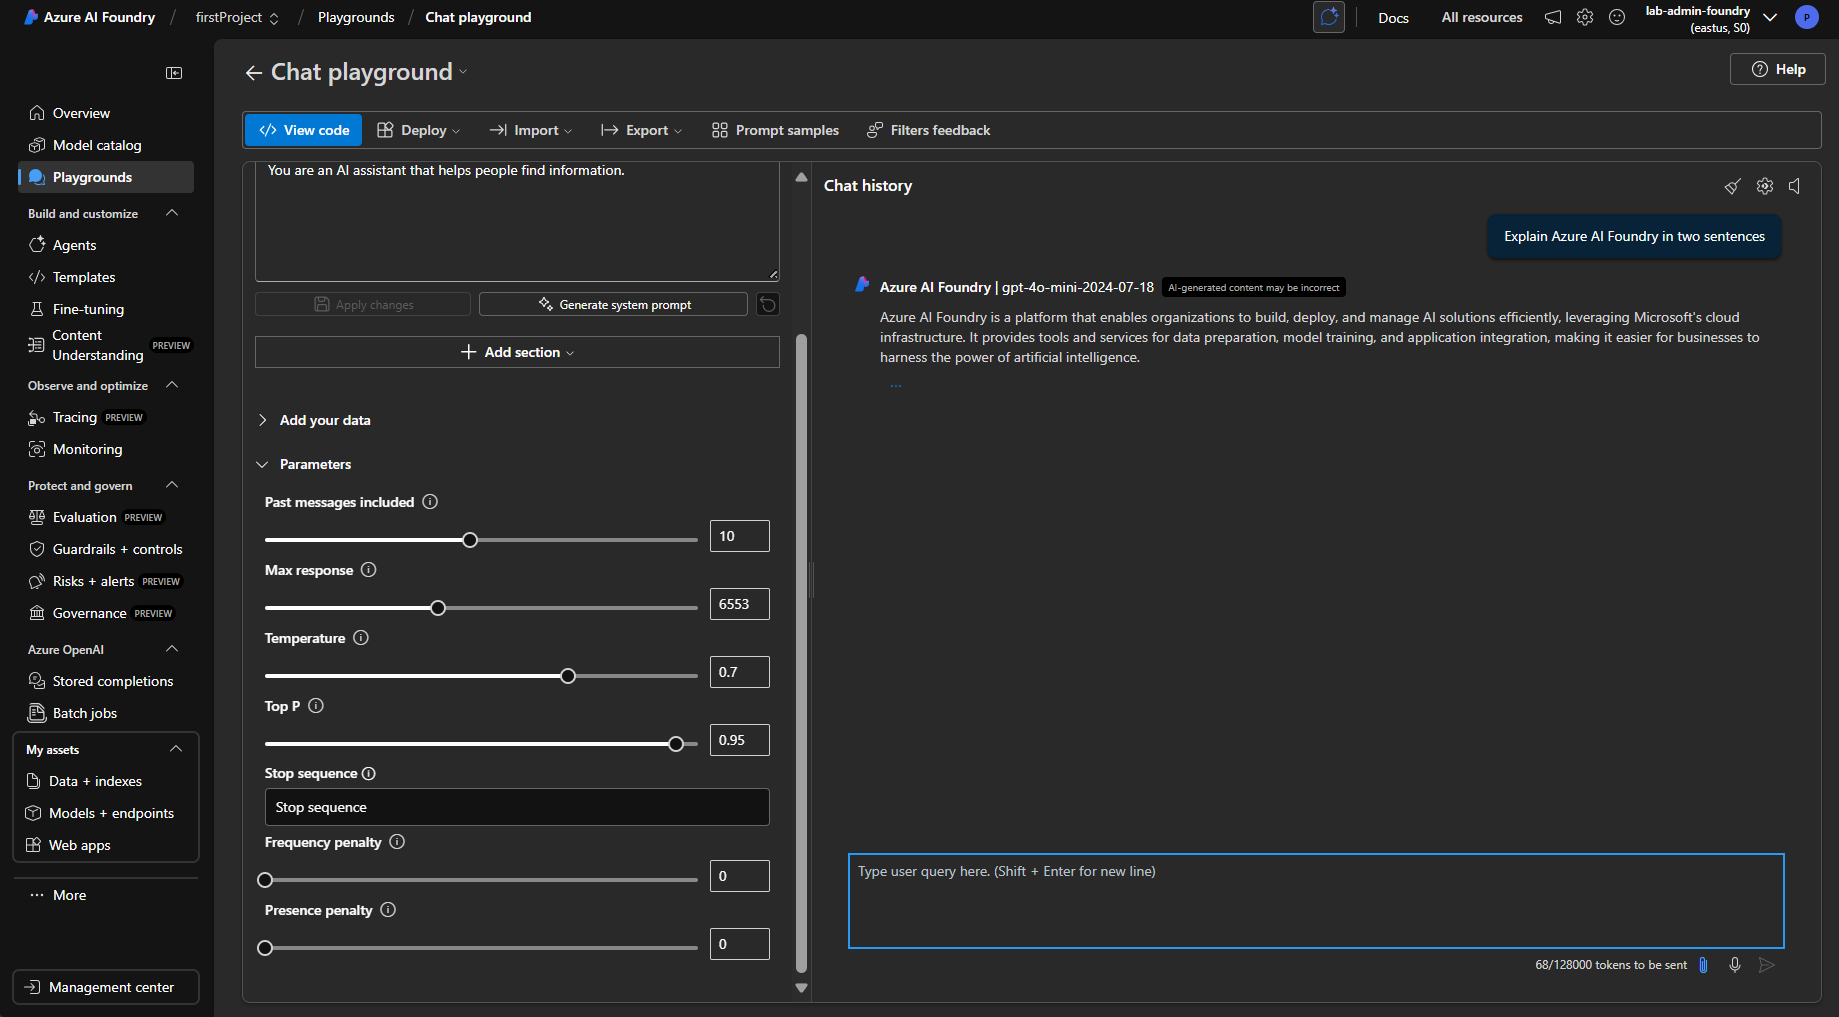

# Testing APIs and optimising model responses

1. Select `Models + Endpoints` from the left blade and navigate to deployed model page

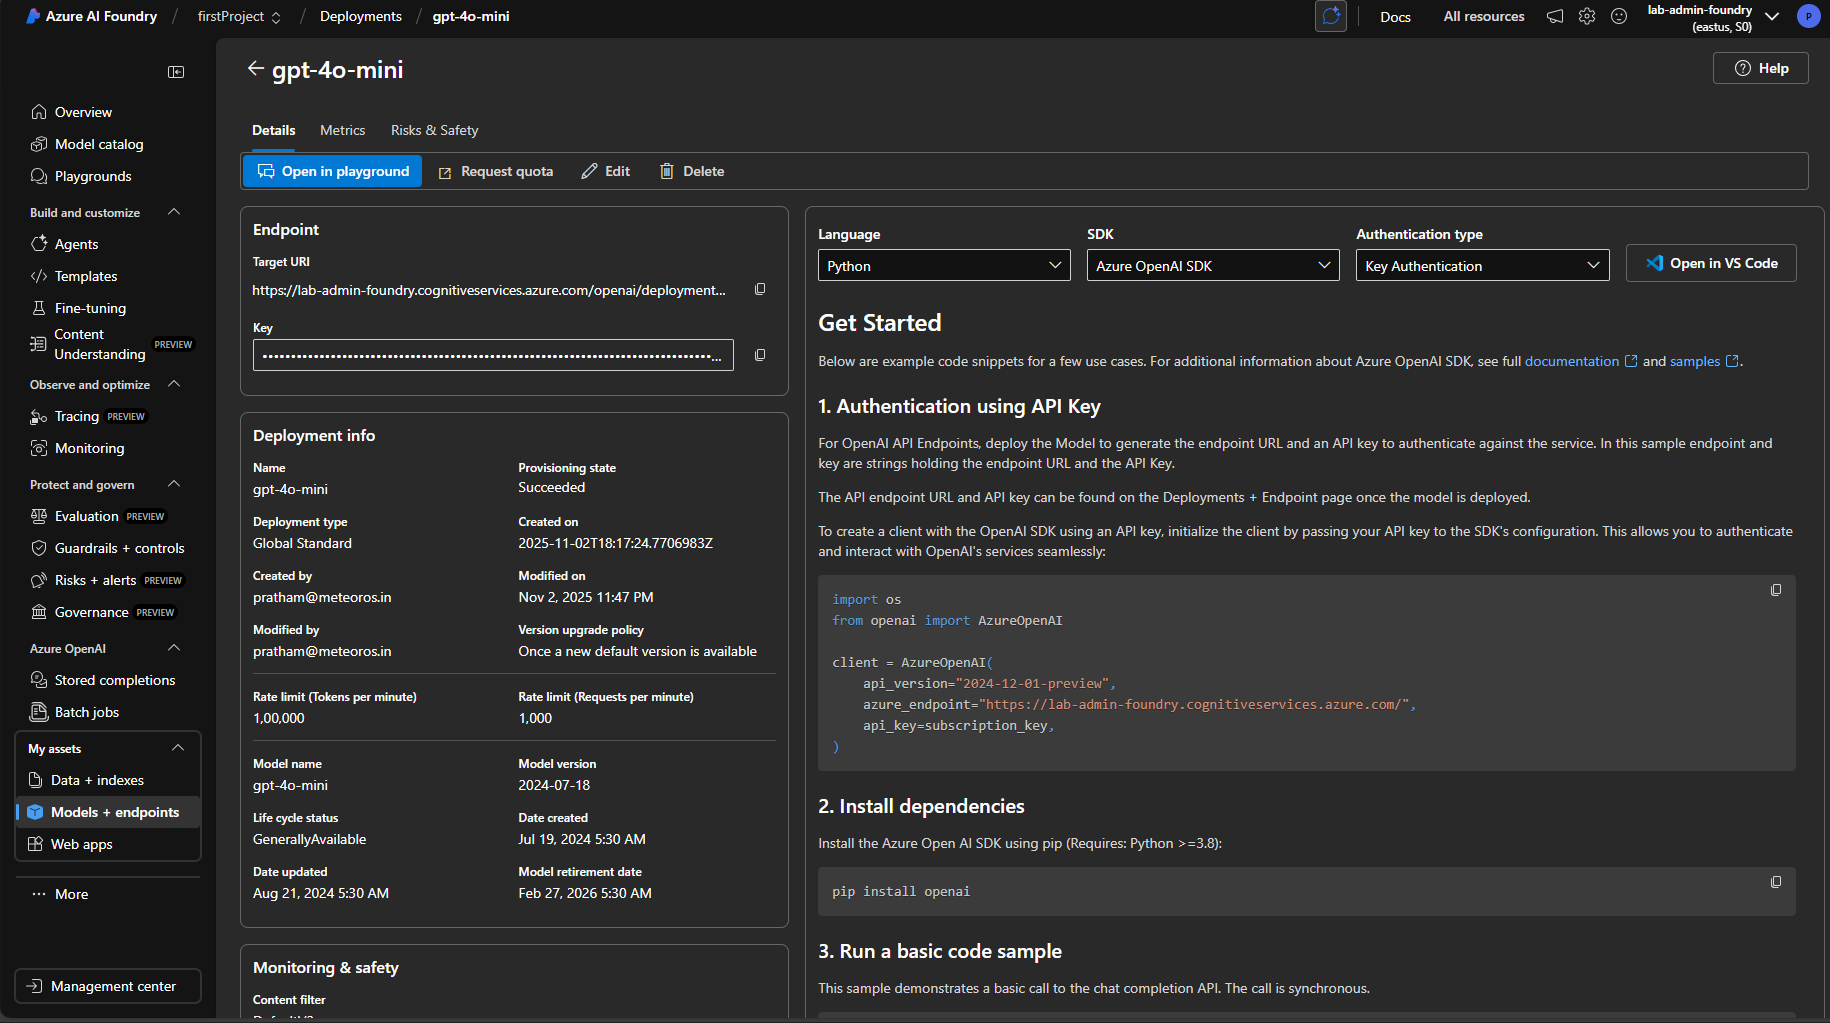

2. Copy the following details and come back to the notebook-
  - Target URI
  - Key

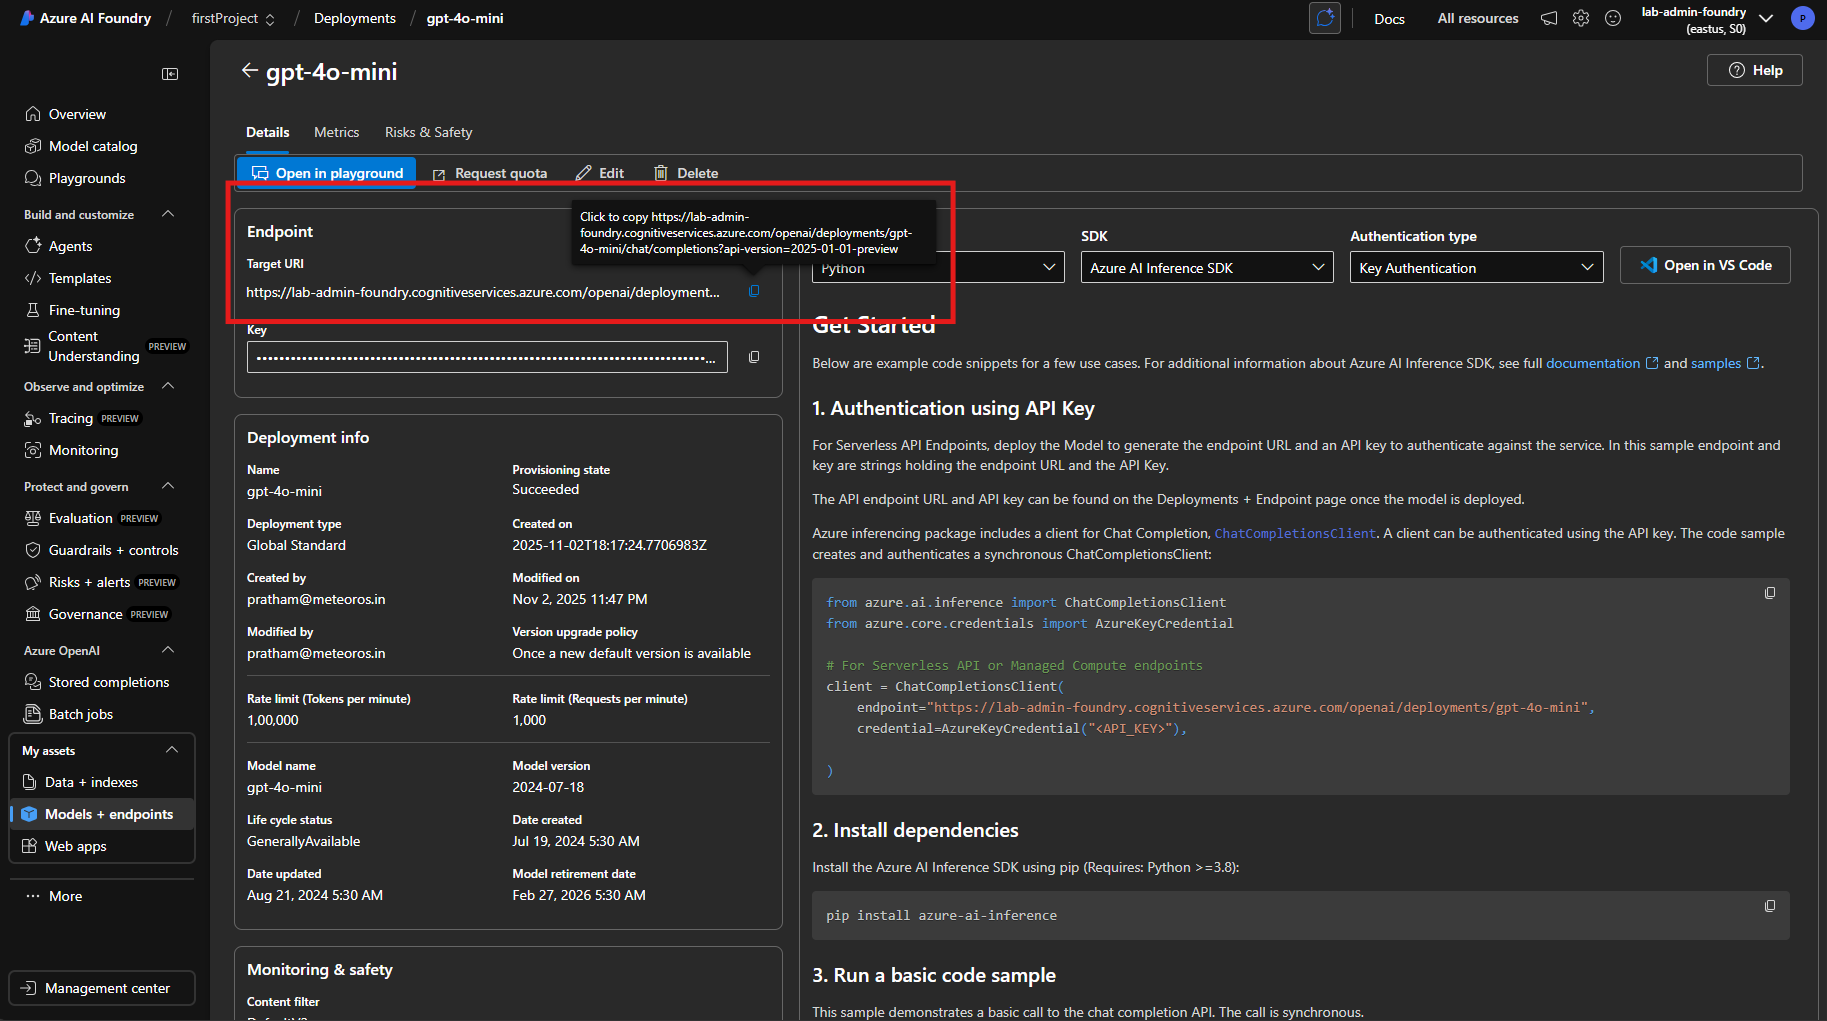

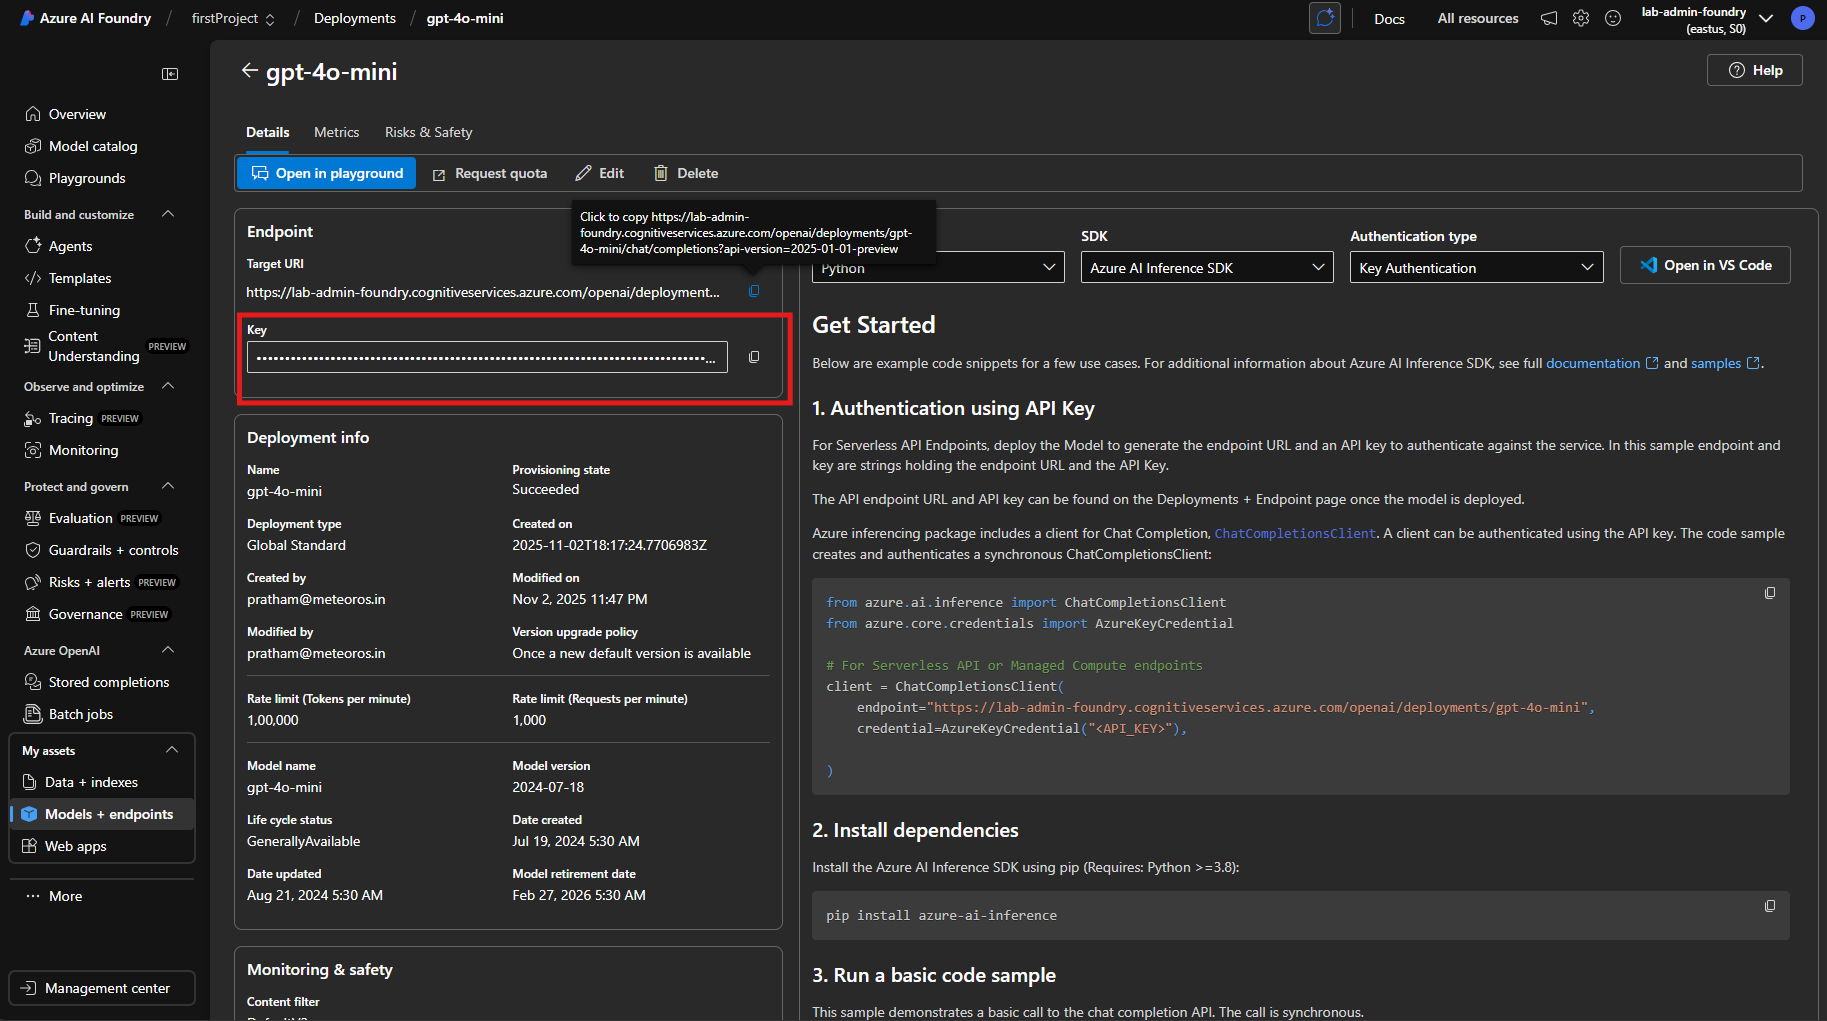

# Calling the model

Now, this notebook lets you:

1. Install the Azure AI Inference SDK
2. Configure endpoint credentials
3. Send chat requests (non‑streaming & streaming)
4. Run small prompt‑tuning experiments


**Please ensure the following dependencies are configured properly before proceeding**

- This lab expects you to have the proper settings configured to run a Jupyter notebook (.ipynb) in Visual Studio Code

In case you do not have configuration 1 in place, please hit **Shift + Enter** x 2 and follow the on-screen instructions provided by VS Code for setting up the kernel and environment. Feel free to contact the Lab Support representative for any assistance.

In [ ]:
# Install packages
!pip -q install --upgrade azure-ai-inference requests


## Configure your endpoint
Fill in the `ENDPOINT`, `API_KEY`, and `DEPLOYMENT` values from your Azure AI Foundry deployment page.

**Ensure to trim the `Target URI` according to the format given below**


In [ ]:
ENDPOINT = "https://pikachu255666.cognitiveservices.azure.com/openai/deployments/gpt-4o-mini"
API_KEY = "<REPLACE_WITH_YOUR_API_KEY>"  # Or configure Entra ID; see official docs
DEPLOYMENT = "gpt4o-mini"

assert ENDPOINT.startswith("https://"), "Please set a valid ENDPOINT"
assert API_KEY and API_KEY != "<your-key>", "Please set your API_KEY"
assert DEPLOYMENT, "Please set your DEPLOYMENT name"


## Initialise a client

In [ ]:
from azure.ai.inference import ChatCompletionsClient
from azure.core.credentials import AzureKeyCredential

client = ChatCompletionsClient(endpoint=ENDPOINT, credential=AzureKeyCredential(API_KEY))


## Invoke a basic completion response

In [ ]:

messages = [
    {"role": "system", "content": "You are a concise Azure assistant."},
    {"role": "user",   "content": "In one sentence, define a foundation model."}
]

result = client.complete(messages=messages, model=DEPLOYMENT, max_tokens=4096, temperature=1.0, top_p=1.0)
print(result.choices[0].message.get("content"))


## Streaming example
Set `stream=True` to iterate tokens as they arrive.


In [ ]:
stream = client.complete(messages=[
    {"role": "system", "content": "You are a succinct assistant."},
    {"role": "user",   "content": "List 3 prompt tuning levers with a one‑liner each."}
], model=DEPLOYMENT, max_tokens=4096, temperature=1.0, top_p=1.0, stream=True)



for update in stream:
    if update.choices:
        print(update.choices[0].delta.content or "", end="")

client.close()


# Re-initialising client for rest of the lab

In [ ]:
from azure.ai.inference import ChatCompletionsClient
from azure.core.credentials import AzureKeyCredential

client = ChatCompletionsClient(endpoint=ENDPOINT, credential=AzureKeyCredential(API_KEY))


## JSON‑shaped responses
Try to enforce a JSON‑only reply via the system message. If your model supports it, you can also pass a `response_format`. If not, validate JSON client‑side.


In [ ]:
import json
messages = [
    {"role": "system", "content": "Return ONLY valid JSON with keys: summary (string), bullets (array)."},
    {"role": "user",   "content": "Summarize what the Chat playground is used for and give 3 bullets."}
]
result = client.complete(messages=messages, model=DEPLOYMENT, max_tokens=4096, temperature=1.0, top_p=1.0)
text = result.choices[0].message.get("content", "{}")
print(text)

try:
    obj = json.loads(text)
    print("\nParsed JSON keys:", list(obj.keys()))
except Exception as e:
    print("\nJSON parse failed:", e)


## Parameter sweep for model optimisation: temperature, max_tokens & top_p
Run a small grid to see how outputs change.


In [ ]:
prompt = "Explain embeddings vs. fine‑tuning for short‑form classification in 3 bullets."
for temp in [0.0, 0.5, 0.9]:
    for mot in [100, 200]:
      for topp in [0.5, 1]:
        res = client.complete(messages=[{"role":"user","content":prompt}], model=DEPLOYMENT,
                              temperature=temp, max_tokens=mot, top_p=topp)
        print("\n--- temperature=", temp, " max_tokens=", mot, "top_p=", topp)
        print(res.choices[0].message.get("content"))


## REST via `requests`
You can also call the `/chat/completions` route directly.


In [ ]:
import requests, json
url = f"{ENDPOINT}/chat/completions?api-version=2025-01-01-preview"
headers = {"Authorization": f"Bearer {API_KEY}", "Content-Type": "application/json"}
payload = {
    "model": DEPLOYMENT,
    "messages": [
        {"role": "system", "content": "You are a concise Azure assistant."},
        {"role": "user",   "content": "Name two cases to prefer a serverless API deployment."}
    ],
    "temperature": 0.3,
    "max_tokens": 250
}
resp = requests.post(url, headers=headers, json=payload, timeout=60)
print(resp.status_code)
print(json.dumps(resp.json(), indent=2)[:2000])


# Conclusion & Next Steps

## What you accomplished

- Navigated Azure AI Foundry → explored Model catalog → reviewed model pages.

- Deployed a chat-capable foundation model and verified endpoint details.

- Tested prompts in Chat Playground (system message, safety, parameters).

- Called the model via SDK/REST and ran small tuning experiments (temperature, top-p, max tokens).